In [1]:
#Inicié un entorno virtual con uv, desde la terminal.
#!uv init

In [2]:
# Integro las liberías necesarias para el análisis de datos y modelado.
#!uv add numpy pandas matplotlib seaborn scikit-learn statsmodels mlflow

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import  mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from IPython.display import display

In [4]:
table1 = pd.read_csv('Challenge - Table 1.csv')
table2 = pd.read_csv('Challenge - Table 2.csv')
table3 = pd.read_csv('Challenge - Table 3.csv')
table4 = pd.read_csv('Challenge - Table 4.csv')

# Resumen del flujo de trabajo

Este notebook desarrolla un flujo reproducible para explorar fuentes de datos, calibrar y evaluar un Marketing Mix Model sobre el volumen semanal de ventas, transformado a su versión logarítimica. El proceso sigue esta secuencia:

1. **Carga y validacion.** Se leen las cuatro fuentes de ventas, inversion en medios, distribucion, clima e informacion regional. Se revisan tipos, llaves, duplicados, cobertura temporal, valores faltantes y granularidad.

2. **Preparacion.** Las fuentes se armonizan por semana y por sus dimensiones de marca, region y subcanal, y se integran en una tabla maestra.

3. **Analisis exploratorio.** Se examinan distribuciones, valores atipicos, comportamiento temporal y correlaciones de Pearson entre variables continuas. Las variables binarias se describen por separado.

4. **Diagnostico temporal.** Se evalua la estacionariedad de las series candidatas y las variables que lo requieren se transforman antes del modelado.

5. **Especificacion.** La variable dependiente es log1p(volume_hl). La venta base incorpora distribucion ponderada, clima, eventos, feriados y diferencias estructurales entre marcas, regiones y subcanales. El ingreso regional se excluye por su baja cobertura temporal y elevada imputacion. La inversion en medios se transforma mediante adstock geometrico y saturacion de Hill.

6. **Calibracion de medios.** Para cada uno de los medios se prueban 18 combinaciones de theta, alpha y gamma, para un total de 252 corridas. La seleccion usa una validacion interna posterior al entrenamiento y minimiza el RMSE retransformado a hectolitros.

7. **Evaluacion final y benchmarks.** La configuracion seleccionada se compara con modelos base, un MMM estandar y alternativas con estacionalidad flexible. Ademas, cuatro ventanas expansivas de 8 semanas evalúan la estabilidad temporal sin modificar los parametros de medios.

8. **Diagnostico y trazabilidad.** Se comparan extensiones con semana del ano y rezago 52, se revisan errores por marca, region y subcanal, y se diagnostican heterocedasticidad y autocorrelacion. Finalmente se presentan coeficientes, significancia, intervalos del 90%, prueba conjunta de medios y VIF. MLflow registra las calibraciones, el modelo final y sus artefactos.

# *Análisis Exploratorio de los Datos (EDA)

In [5]:
# Uso listas comprehensivas para extraer y mostrar las primeras filas de cada tabla, 
# redondeando los valores a un decimal por comodidad visual (repito este procedimiento cuando aplica)
[display(round(t.head(), 1)) for t in [table1, table2, table3, table4]]

,week,brand,subchannel,region,volume_hl,net_revenue_adj_CPI
0,2021-01-09,Brand A,Subchannel A,Region A,91.9,19.5
1,2021-01-16,Brand A,Subchannel A,Region A,96.7,17.2
2,2021-01-23,Brand A,Subchannel A,Region A,70.1,14.7
3,2021-01-30,Brand A,Subchannel A,Region A,19.2,4.3
4,2021-02-06,Brand A,Subchannel A,Region A,54.6,14.1


,brand,week,cinema,digitaldisplayandsearch,digitalvideo,facebook,instagram,localtv,ooh,opentv,paytv,print,radio,tiktok,twitter,youtube
0,Brand A,2023-01-07,0.0,2.8,1.8,3.8,0.3,0.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Brand A,2023-01-14,0.0,2.8,2.1,0.0,0.0,0.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Brand A,2023-01-21,0.0,2.8,2.0,6.2,9.9,0.0,1.6,0.0,0.0,0.0,0.0,0.0,0.0,0.3
3,Brand A,2023-01-28,0.0,0.1,0.1,10.7,13.7,0.0,1.8,0.0,0.0,0.0,0.0,0.0,0.0,3.1
4,Brand A,2023-02-04,0.0,1.8,1.5,10.0,12.7,0.0,3.5,0.0,0.0,0.0,0.0,0.0,0.0,5.6


,subchannel,region,brand,week,variable,value
0,Subchannel A,Region A,Brand A,2021-01-09,total_distribution,1.3
1,Subchannel A,Region A,Brand A,2021-01-16,total_distribution,1.2
2,Subchannel A,Region A,Brand A,2021-01-23,total_distribution,1.4
3,Subchannel A,Region A,Brand A,2021-01-30,total_distribution,1.1
4,Subchannel A,Region A,Brand A,2021-02-06,total_distribution,1.2


,week,region,avg_temp,avg_prcp,income_region,evento_deportivo,evento_social,feriado
0,2021-01-02,Region D,25.6,0.0,NaN,NaN,NaN,NaN
1,2021-01-02,Region E,25.0,0.0,NaN,NaN,NaN,NaN
2,2021-01-02,Region B,25.2,0.0,NaN,NaN,NaN,NaN
3,2021-01-02,Region A,24.8,0.0,NaN,NaN,NaN,NaN
4,2021-01-02,Region G,24.4,0.0,NaN,NaN,NaN,NaN


[None, None, None, None]

In [6]:
[t.info() for t in [table1, table2, table3, table4]]

<class 'pandas.DataFrame'>
RangeIndex: 39721 entries, 0 to 39720
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   week                 39721 non-null  str    
 1   brand                39721 non-null  str    
 2   subchannel           39721 non-null  str    
 3   region               39721 non-null  str    
 4   volume_hl            39721 non-null  float64
 5   net_revenue_adj_CPI  39721 non-null  float64
dtypes: float64(2), str(4)
memory usage: 3.2 MB
<class 'pandas.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   brand                    911 non-null    str    
 1   week                     911 non-null    str    
 2   cinema                   911 non-null    float64
 3   digitaldisplayandsearch  911 non-null    float64
 4   digitalvideo             911 non

[None, None, None, None]

In [7]:
#Convirtiendo la columna 'week' de cadena de texto a formato datetime
table1['week'] = pd.to_datetime(table1['week'])
table2['week'] = pd.to_datetime(table2['week'])
table3['week'] = pd.to_datetime(table3['week'])
table4['week'] = pd.to_datetime(table4['week'])

In [8]:
#Estadísticas descriptivas de las variables en las 4 tablas a un decimal para comodidad
[display(round(t.describe(), 1)) for t in [table1, table2, table3, table4]]

,week,volume_hl,net_revenue_adj_CPI
count,39721,39721.0,39721.0
mean,2023-08-29 03:27:15.457314,895.9,195.7
min,2021-01-09 00:00:00,0.0,0.0
25%,2022-04-30 00:00:00,78.3,19.8
50%,2023-08-26 00:00:00,229.8,57.9
75%,2024-12-21 00:00:00,746.7,179.5
max,2026-04-18 00:00:00,50339.8,12460.1
std,NaN,2558.4,509.2


,week,cinema,digitaldisplayandsearch,digitalvideo,facebook,instagram,localtv,ooh,opentv,paytv,print,radio,tiktok,twitter,youtube
count,911,911.0,911.0,911.0,911.0,911.0,911.0,911.0,911.0,911.0,911.0,911.0,911.0,911.0,911.0
mean,2024-06-20 16:27:55.521405,0.1,2.6,1.3,5.0,3.7,8.9,24.8,15.2,12.4,0.1,5.0,0.9,0.1,2.7
min,2023-01-07 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2023-09-26 12:00:00,0.0,0.4,0.2,1.4,1.1,0.0,2.9,1.3,1.8,0.0,0.0,0.0,0.0,0.5
50%,2024-06-15 00:00:00,0.0,1.3,0.7,2.9,2.5,3.5,11.5,10.0,7.4,0.0,2.3,0.0,0.0,1.5
75%,2025-03-08 00:00:00,0.0,2.8,1.7,5.7,4.6,10.4,31.5,19.0,13.6,0.0,6.6,0.3,0.0,3.2
max,2025-12-27 00:00:00,24.5,62.7,19.0,160.7,85.8,440.3,536.2,330.4,294.0,33.4,129.2,53.6,3.5,83.4
std,NaN,1.1,4.6,1.9,8.9,5.5,21.4,43.1,25.0,21.6,1.3,9.6,3.6,0.3,5.2


,week,value
count,112734,112734.0
mean,2023-07-07 23:07:41.567938,28.6
min,2021-01-09 00:00:00,0.1
25%,2022-04-09 00:00:00,1.7
50%,2023-07-08 00:00:00,17.3
75%,2024-10-05 00:00:00,48.1
max,2026-01-03 00:00:00,100.0
std,NaN,30.2


,week,avg_temp,avg_prcp,income_region,evento_deportivo,evento_social,feriado
count,2088,2088.0,2088.0,1248.0,360.0,360.0,360.0
mean,2023-07-01 00:00:00,16.6,14.8,63.0,0.1,0.2,1.0
min,2021-01-02 00:00:00,-2.6,0.0,45.8,0.0,0.0,0.0
25%,2022-04-02 00:00:00,12.1,1.0,54.7,0.0,0.0,1.0
50%,2023-07-01 00:00:00,16.6,6.0,62.2,0.0,0.0,1.0
75%,2024-09-28 00:00:00,21.6,19.6,71.2,0.0,0.0,1.0
max,2025-12-27 00:00:00,31.3,347.8,84.4,1.0,1.0,2.0
std,NaN,6.2,23.9,9.2,0.2,0.4,0.7


[None, None, None, None]

In [9]:
#Ordenando las tablas por la columna 'week' para respetar el indexado de serie temporal
table1 = table1.sort_values('week')
table2 = table2.sort_values('week')
table3 = table3.sort_values('week')
table4 = table4.sort_values('week')

In [10]:
#valores perdidos
[t.isnull().sum() for t in [table1, table2, table3, table4]]

[week                   0
 brand                  0
 subchannel             0
 region                 0
 volume_hl              0
 net_revenue_adj_CPI    0
 dtype: int64,
 brand                      0
 week                       0
 cinema                     0
 digitaldisplayandsearch    0
 digitalvideo               0
 facebook                   0
 instagram                  0
 localtv                    0
 ooh                        0
 opentv                     0
 paytv                      0
 print                      0
 radio                      0
 tiktok                     0
 twitter                    0
 youtube                    0
 dtype: int64,
 subchannel    0
 region        0
 brand         0
 week          0
 variable      0
 value         0
 dtype: int64,
 week                   0
 region                 0
 avg_temp               0
 avg_prcp               0
 income_region        840
 evento_deportivo    1728
 evento_social       1728
 feriado             1728
 dtype: i

## Tabla 1. Ventas semanales: volumen (hl) y revenue neto, por marca, subcanal y región

Text(0, 0.5, '$ ARS')

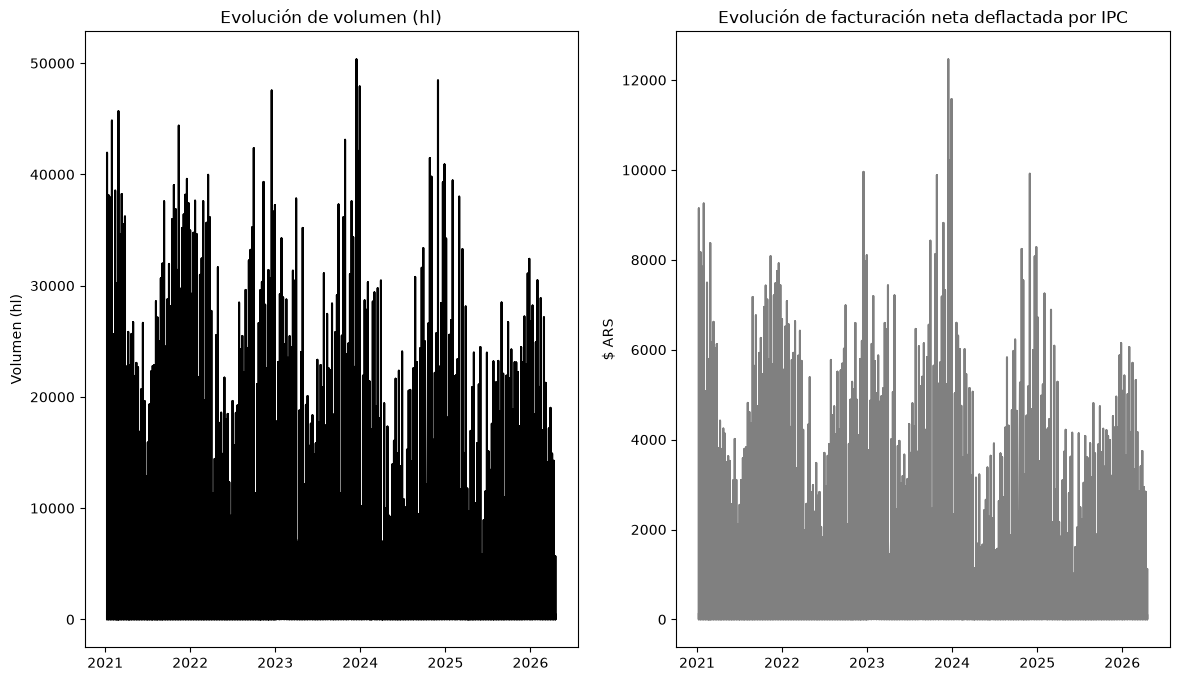

In [11]:
#Creando una cuadrícula de una fila y dos columnas para incrustar los gráficos de volumen y facturación
fig, lienzo1 = plt.subplots(1, 2, figsize=(14, 8), sharex=True)
lienzo1[0].plot(table1['week'], table1['volume_hl'], label='Volumen de ventas', color='black')
lienzo1[0].set_title('Evolución de volumen (hl)')
lienzo1[0].set_ylabel('Volumen (hl)')

lienzo1[1].plot(table1['week'], table1['net_revenue_adj_CPI'], label='Facturación neta ajustada por IPC', color='gray')
lienzo1[1].set_title('Evolución de facturación neta deflactada por IPC')
lienzo1[1].set_ylabel('$ ARS')

Observaciones:
Ambas gráficas muestran subidas y bajadas muy marcadas que se repiten cada año. Esto indica que estamos ante un negocio que opera con una estacionalidad altísima.

El momento más destacado de todo el periodo ocurre a principios de 2024. Ahí vemos que las ventas despegaron, rozando los 50,000 hectolitros y superando los 12,000 pesos deflactados. 

Sin embargo, lo interesante viene después de ese récord. Si nos fijamos en los años 2025 y 2026, esos grandes picos estacionales empiezan a perder un poco de fuerza. Aunque el ciclo de la demanda se mantiene, el negocio ya no logra alcanzar los niveles máximos de los años anteriores. Esto sugiere que, tras el excepcional año 2024, el mercado experimentó una leve contracción o un comportamiento más moderado durante sus temporadas altas.

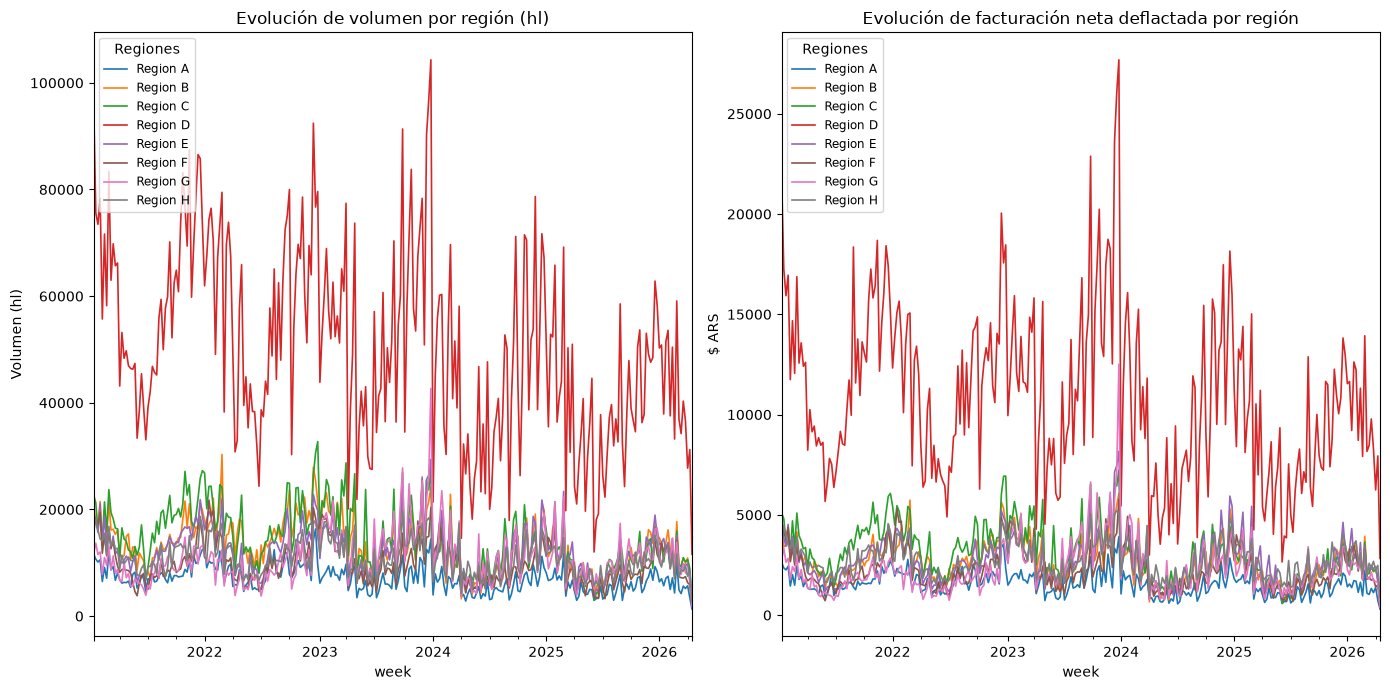

In [12]:
# 1. pivot_table para manejar posibles filas duplicadas por semana y región (agregando con mean o sum)
df_volumen = table1.pivot_table(index='week', columns='region', values='volume_hl', aggfunc='sum')
df_facturacion = table1.pivot_table(index='week', columns='region', values='net_revenue_adj_CPI', aggfunc='sum')

# 2. Crear la figura con 1 fila y 2 columnas
fig, lienzo = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

# 3. Gráficos
df_volumen.plot(kind='line', ax=lienzo[0], linewidth=1.2)
df_facturacion.plot(kind='line', ax=lienzo[1], linewidth=1.2)

# 4. Primer gráfico (Volumen hl)
lienzo[0].set_title('Evolución de volumen por región (hl)')
lienzo[0].set_ylabel('Volumen (hl)')
lienzo[0].legend(title='Regiones', fontsize='small', loc='upper left')

# 5. Segundo gráfico (Facturación)
lienzo[1].set_title('Evolución de facturación neta deflactada por región')
lienzo[1].set_ylabel('$ ARS')
lienzo[1].legend(title='Regiones', fontsize='small', loc='upper left')

plt.tight_layout()
plt.show()

Observaciones:

Lo más notorio acá es la dependencia del negocio hacia una sola zona geográfica (D). La línea correspondiente a la Región D domina abrumadoramente tanto el volumen despachado como la facturación ajustada durante todo el periodo.

Mientras que la Región D experimenta picos estacionales masivos, llegando a superar los 100,000 hectolitros y los 25,000 pesos en su momento de mayor apogeo a principios de 2024, las otras siete regiones se mantienen agrupadas en la franja inferior del gráfico, esto muy probablemente se relaciona al tamaño poblacional de dichas regiones. El resto de las áreas aportan volúmenes muy por debajo, evidenciando una escala de negocio completamente distinta y marginal en comparación con la zona principal.

Por otro lado, ambos gráficos son prácticamente idénticos en su forma, confirmando una alta covarianza entre el volumen y los ingresos generados en cada zona. Finalmente, se confirma que la desaceleración observada hacia 2025 y 2026 es impulsada exclusivamente por la Región D, cuyos picos estacionales han perdido fuerza tras el récord de 2024, arrastrando así el promedio general.

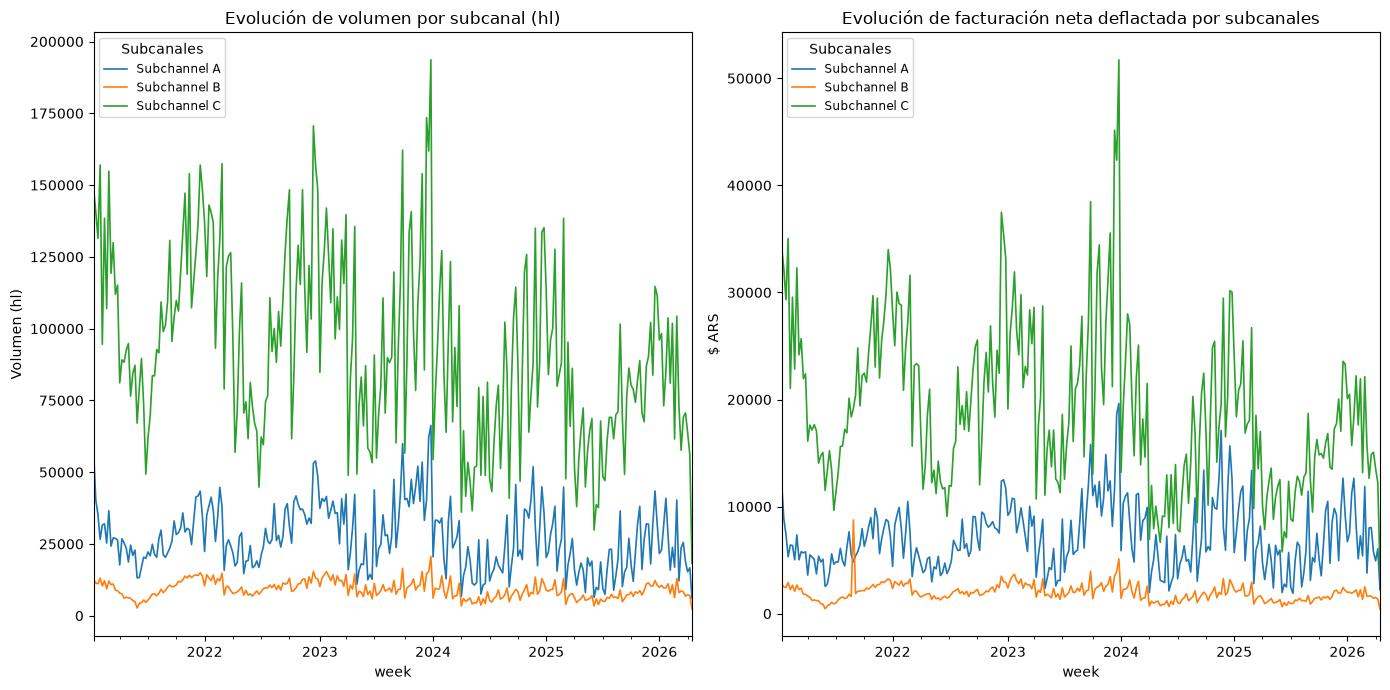

In [13]:
# 1. pivot_table para manejar posibles filas duplicadas por semana y región (agregando con mean o sum)
df_volumen = table1.pivot_table(index='week', columns='subchannel', values='volume_hl', aggfunc='sum')
df_facturacion = table1.pivot_table(index='week', columns='subchannel', values='net_revenue_adj_CPI', aggfunc='sum')

# 2. Crear la figura con 1 fila y 2 columnas
fig, lienzo1A = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

# 3. Grafico
df_volumen.plot(kind='line', ax=lienzo1A[0], linewidth=1.2)
df_facturacion.plot(kind='line', ax=lienzo1A[1], linewidth=1.2)

# 4. Personalizar el primer gráfico (Volumen)
lienzo1A[0].set_title('Evolución de volumen por subcanal (hl)')
lienzo1A[0].set_ylabel('Volumen (hl)')
lienzo1A[0].legend(title='Subcanales', fontsize='small', loc='upper left')

# 5. Personalizar el segundo gráfico (Facturación)
lienzo1A[1].set_title('Evolución de facturación neta deflactada por subcanales')
lienzo1A[1].set_ylabel('$ ARS')
lienzo1A[1].legend(title='Subcanales', fontsize='small', loc='upper left')

plt.tight_layout()
plt.show()

Observaciones:

Acá, queda claro que el Subcanal C es el motor del negocio. Esta categoría domina tanto el volumen como la facturación, mostrando picos estacionales muy agresivos que alcanzaron su máximo histórico a principios de 2024, como se comentó anteriormente

El Subcanal A se posiciona en segundo lugar, replicando los mismos ciclos de demanda estacional pero a una escala mucho menor. Por su parte, el Subcanal B tiene un peso casi marginal, manteniéndose estable y con una aportación muy baja.

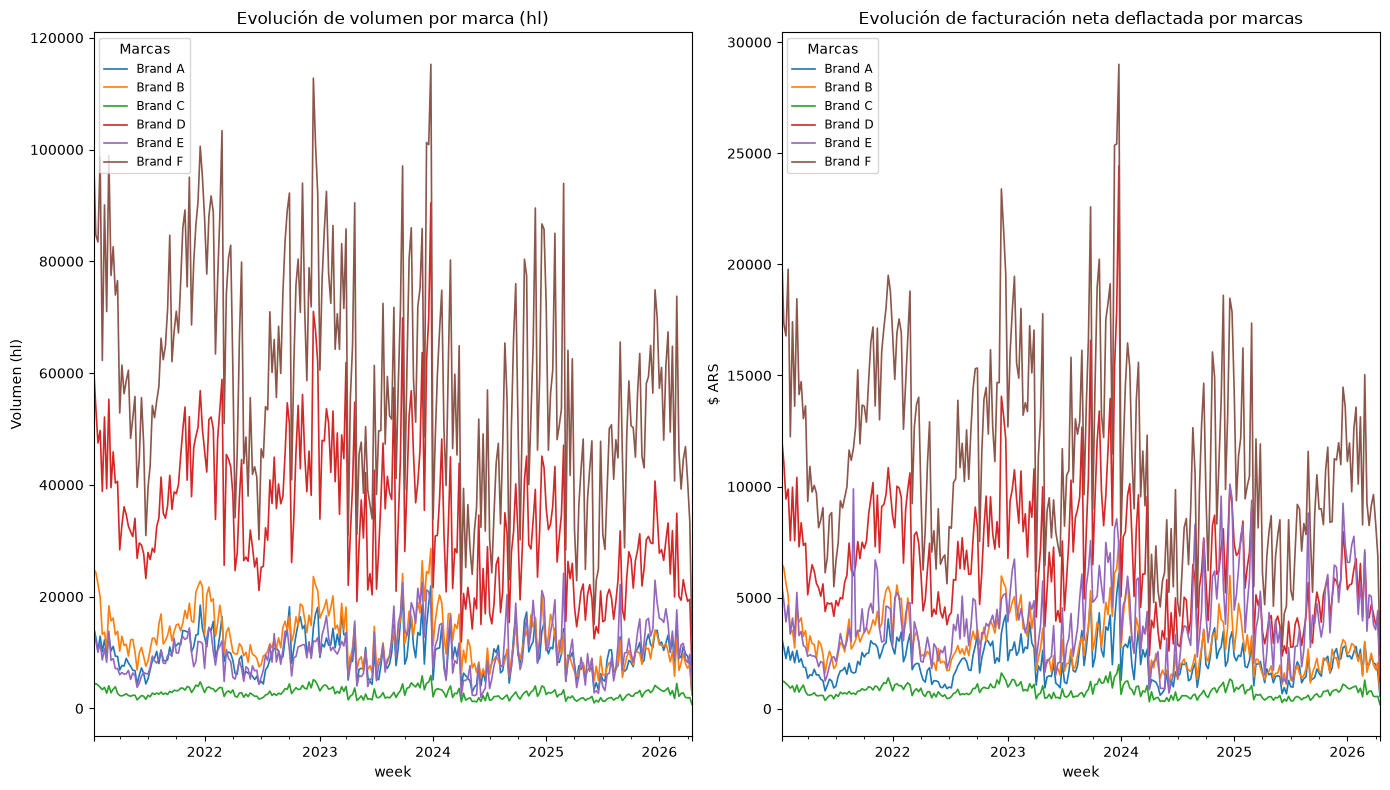

In [14]:
# 1. pivot_table para manejar posibles filas duplicadas por semana y región (agregando con mean o sum)
df_volumen = table1.pivot_table(index='week', columns='brand', values='volume_hl', aggfunc='sum')
df_facturacion = table1.pivot_table(index='week', columns='brand', values='net_revenue_adj_CPI', aggfunc='sum')

# 2. Crear la figura con 1 fila y 2 columnas
fig, lienzo1A = plt.subplots(1, 2, figsize=(14, 8), sharex=True)

# 3. Grafico
df_volumen.plot(kind='line', ax=lienzo1A[0], linewidth=1.2)
df_facturacion.plot(kind='line', ax=lienzo1A[1], linewidth=1.2)

# 4. Personalizar el primer gráfico (Volumen)
lienzo1A[0].set_title('Evolución de volumen por marca (hl)')
lienzo1A[0].set_ylabel('Volumen (hl)')
lienzo1A[0].legend(title='Marcas', fontsize='small', loc='upper left')

# 5. Personalizar el segundo gráfico (Facturación)
lienzo1A[1].set_title('Evolución de facturación neta deflactada por marcas')
lienzo1A[1].set_ylabel('$ ARS')
lienzo1A[1].legend(title='Marcas', fontsize='small', loc='upper left')

plt.tight_layout()
plt.show()

Observaciones:

Estos gráficos revelan que el portafolio depende de un duo. Las marcas F y D son las protagonistas, dominando tanto el volumen despachado como los ingresos reales de forma aplastante frente al resto.

La marca F parece ser el motor principal, marcando los picos estacionales más agresivos que superan los 110,000 hectolitros, seguida de cerca por la marca D que también aporta picos de facturación masivos. Ambas experimentaron su momento cumbre a inicios de 2024. Es evidente también que la contracción del negocio observada en 2025 y 2026 es el resultado directo de que estas dos marcas estrella perdieron fuerza en sus temporadas altas.

Mientras tanto, las marcas A, B y E operan en un bloque intermedio. Tienen su propia estacionalidad pero a una escala mucho menor y menos volátil. En el último lugar quedó la marca C, manteniéndose plana en el fondo de la gráfica con un aporte prácticamente nulo a la facturación total de la empresa.

## Tabla 2. Inversión en medios por marca y semana, abierta por canal (TV, digital, redes, vía pública, radio, etc.)

Número total de variables en la tabla No. 2 = 14
['cinema', 'digitaldisplayandsearch', 'digitalvideo', 'facebook', 'instagram', 'localtv', 'ooh', 'opentv', 'paytv', 'print', 'radio', 'tiktok', 'twitter', 'youtube']


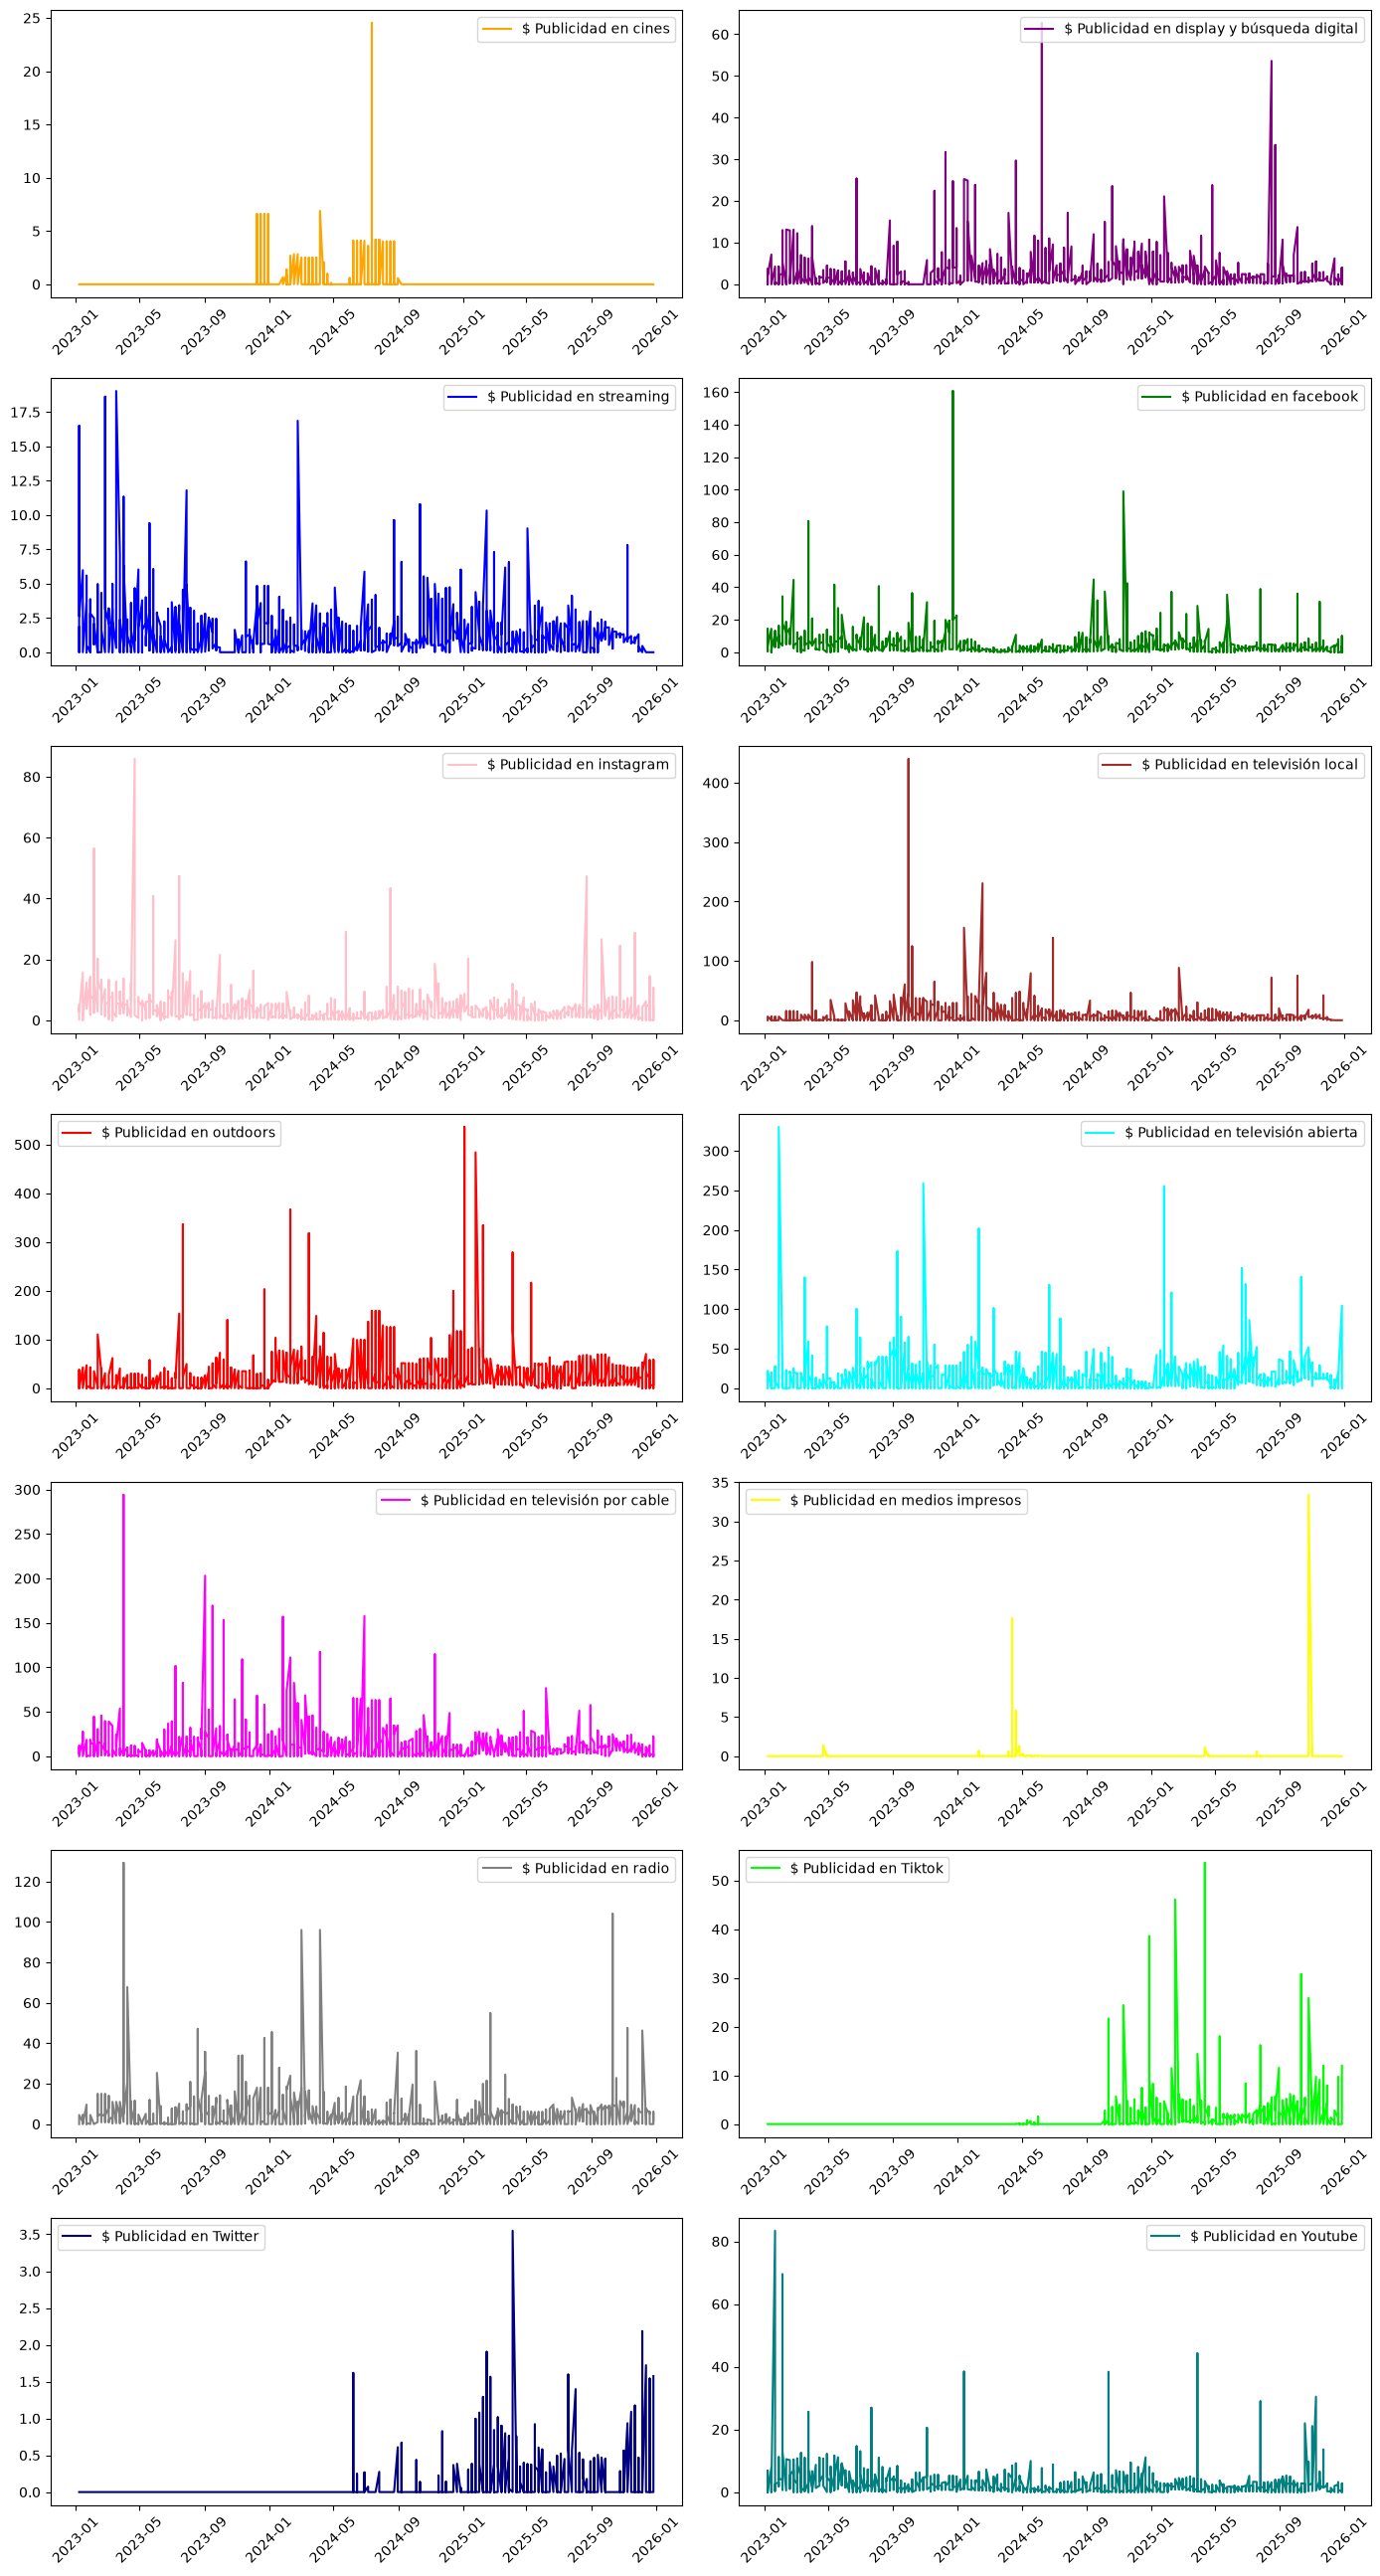

In [15]:
tab2_num_vars = table2.select_dtypes(include=['category', 'float']).shape[1]
print(f'Número total de variables en la tabla No. 2 = {tab2_num_vars}')

nomb_cols = table2.select_dtypes(include=['number']).columns.tolist()
print(nomb_cols)

# 1. Mantener sharex=False para que cada gráfico conserve su propio eje X
fig, lienzo2 = plt.subplots(tab2_num_vars // 2, 2, figsize=(14, 26), sharex=False)

lienzo2[0, 0].plot(table2['week'], table2['cinema'], label='$ Publicidad en cines', color='orange')
lienzo2[0, 1].plot(table2['week'], table2['digitaldisplayandsearch'], label='$ Publicidad en display y búsqueda digital', color='purple')
lienzo2[1, 0].plot(table2['week'], table2['digitalvideo'], label='$ Publicidad en streaming', color='blue')
lienzo2[1, 1].plot(table2['week'], table2['facebook'], label='$ Publicidad en facebook', color='green')
lienzo2[2, 0].plot(table2['week'], table2['instagram'], label='$ Publicidad en instagram', color='pink')
lienzo2[2, 1].plot(table2['week'], table2['localtv'], label='$ Publicidad en televisión local', color='brown')
lienzo2[3, 0].plot(table2['week'], table2['ooh'], label='$ Publicidad en outdoors', color='red')
lienzo2[3, 1].plot(table2['week'], table2['opentv'], label='$ Publicidad en televisión abierta', color='cyan')
lienzo2[4, 0].plot(table2['week'], table2['paytv'], label='$ Publicidad en televisión por cable', color='magenta')
lienzo2[4, 1].plot(table2['week'], table2['print'], label='$ Publicidad en medios impresos', color='yellow')
lienzo2[5, 0].plot(table2['week'], table2['radio'], label='$ Publicidad en radio', color='gray')
lienzo2[5, 1].plot(table2['week'], table2['tiktok'], label='$ Publicidad en Tiktok', color='lime')
lienzo2[6, 0].plot(table2['week'], table2['twitter'], label='$ Publicidad en Twitter', color='navy')
lienzo2[6, 1].plot(table2['week'], table2['youtube'], label='$ Publicidad en Youtube', color='teal')

# 2. Iterar para mostrar las etiquetas y rotar el eje X individualmente en cada gráfico
for ax in lienzo2.flat:
    ax.legend(loc='best', fontsize=10)
    ax.tick_params(axis='x', rotation=45) # Aplica la rotación a cada subgráfico

# 3. Ajustar los márgenes (se elimina fig.autofmt_xdate)
fig.tight_layout()

Observaciones: 

En primer lugar se observa que los canales tradicionales de alcance masivo, específicamente "outdoors" y televisión (local y abierta), lideran los picos de inversión más agresivos. Estos medios concentran la mayor inyección de capital en momentos puntuales, superando niveles de 400 y 500 en sus temporadas más fuertes.

En segundo lugar, se aprecia una base de inversión continua en el ecosistema digital. Canales como display y búsqueda, streaming, Instagram y YouTube mantienen un flujo de gasto constante, funcionando como una capa permanente de presencia de marca.

En tercer lugar, resalta la adopción de nuevas plataformas. Las gráficas de TikTok y Twitter muestran una inversión nula durante 2023. Sin embargo, a partir de 2024 ambas redes se activan, destacando el crecimiento acelerado de TikTok, que gana gran relevancia hacia 2025 y 2026.

Finalmente, cines y medios impresos muestran una actividad casi inexistente. Su histórico se mantiene plano y solo presenta picos altamente aislados, indicando que se utilizan exclusivamente para esfuerzos tácticos esporádicos.

# Tabla 3. Indicadores de distribución en el punto de venta, por subcanal, región, marca y semana

Número total de variables en la tabla No. 3 = 1
['value']


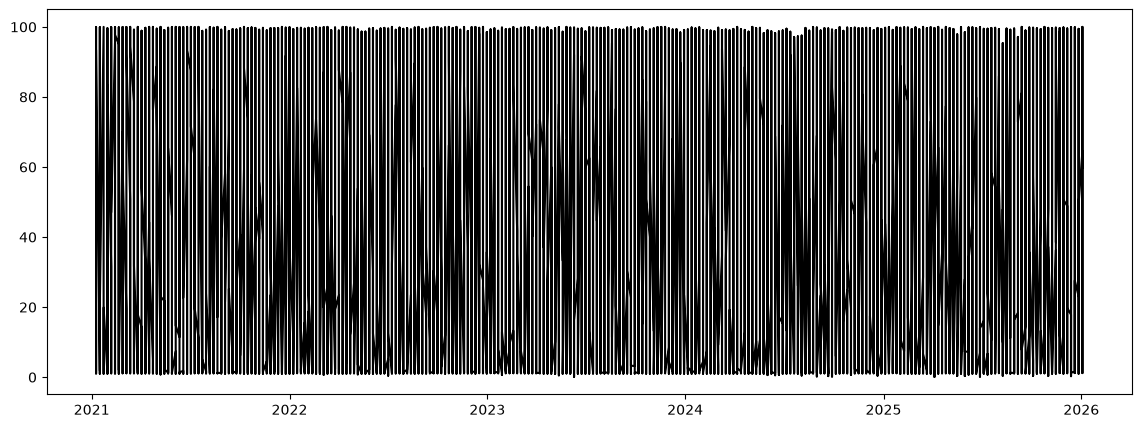

In [16]:
num_vars3 = table3.select_dtypes(include = ['category', 'float']).shape[1]
print(f'Número total de variables en la tabla No. 3 = {num_vars3}')
nomb_cols3 = table3.select_dtypes(include=['number']).columns.tolist()
print(nomb_cols3)

fig, lienzo3 = plt.subplots(1, 1, figsize=(14, 5), sharex=False)
lienzo3.plot(table3['week'], table3['value'], label='[Índice de distribución', color='black')

Observaciones: 

Originalmente, la tabla 3 está estructurada en un formato apilado, también conocido como formato largo. Las columnas subcanal, region, marca y week funcionan como dimensiones identificadoras. Las métricas están apiladas verticalmente usando un esquema llave-valor: la columna variable almacena el nombre de la métrica y value contiene el registro numérico. Es necesario convertir a formato ancho con la siguiente función.

In [17]:
def explorar_panel_distribucion_lienzo(df):
    # 1. Inspección estructural
    print("Dimensiones y tipos de datos:")
    print(df.info())

    # 2. Resumen estadístico
    resumen = df.groupby(['region', 'subchannel', 'brand', 'variable'])['value'].describe()
    print("\nResumen estadístico preliminar (primeras filas):")
    print(resumen.head(15))

    # 3. Transformación a formato ancho
    df_wide = df.pivot_table(
        index=['week', 'region', 'subchannel', 'brand'],
        columns='variable',
        values='value'
    ).reset_index()
    df_wide.columns.name = None

    # 4. Visualización en un lienzo con 3 gráficos
    sns.set_theme(style="whitegrid")
    
    # Crear figura con 3 filas y 1 columna, compartiendo el eje X
    fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True)

    # Gráfico 1: Evolución por región
    sns.lineplot(
        data=df, 
        x='week', 
        y='value', 
        hue='region', 
        style='variable',
        estimator='mean', 
        errorbar=None, 
        ax=axes[0]
    )
    axes[0].set_title("Evolución semanal promedio por región")
    axes[0].set_ylabel("Valor")
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # Gráfico 2: Evolución por subcanal
    sns.lineplot(
        data=df, 
        x='week', 
        y='value', 
        hue='subchannel', 
        style='variable',
        estimator='mean', 
        errorbar=None, 
        ax=axes[1]
    )
    axes[1].set_title("Evolución semanal promedio por subcanal")
    axes[1].set_ylabel("Valor")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # Gráfico 3: Evolución por marca
    sns.lineplot(
        data=df, 
        x='week', 
        y='value', 
        hue='brand', 
        style='variable',
        estimator='mean', 
        errorbar=None, 
        ax=axes[2]
    )
    axes[2].set_title("Evolución semanal promedio por marca")
    axes[2].set_xlabel("Semana")
    axes[2].set_ylabel("Valor")
    axes[2].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

    # Ajustar el espaciado general
    plt.tight_layout()
    plt.show()

    return df_wide

Dimensiones y tipos de datos:
<class 'pandas.DataFrame'>
Index: 112734 entries, 0 to 112733
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   subchannel  112734 non-null  str           
 1   region      112734 non-null  str           
 2   brand       112734 non-null  str           
 3   week        112734 non-null  datetime64[us]
 4   variable    112734 non-null  str           
 5   value       112734 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(4)
memory usage: 11.1 MB
None



Resumen estadístico preliminar (primeras filas):
                                                     count       mean  \
region   subchannel   brand   variable                                  
Region A Subchannel A Brand A normal_distribution    261.0  23.333276   
                              total_distribution     261.0   1.405866   
                              weighted_distribution  261.0  59.073460   
                      Brand B normal_distribution    261.0  32.473448   
                              total_distribution     261.0   2.908417   
                              weighted_distribution  261.0  72.076021   
                      Brand C normal_distribution    261.0  34.895993   
                              total_distribution     261.0   1.878044   
                              weighted_distribution  261.0  73.326602   
                      Brand D normal_distribution    261.0  43.256053   
                              total_distribution     261.0   2.639703   
 

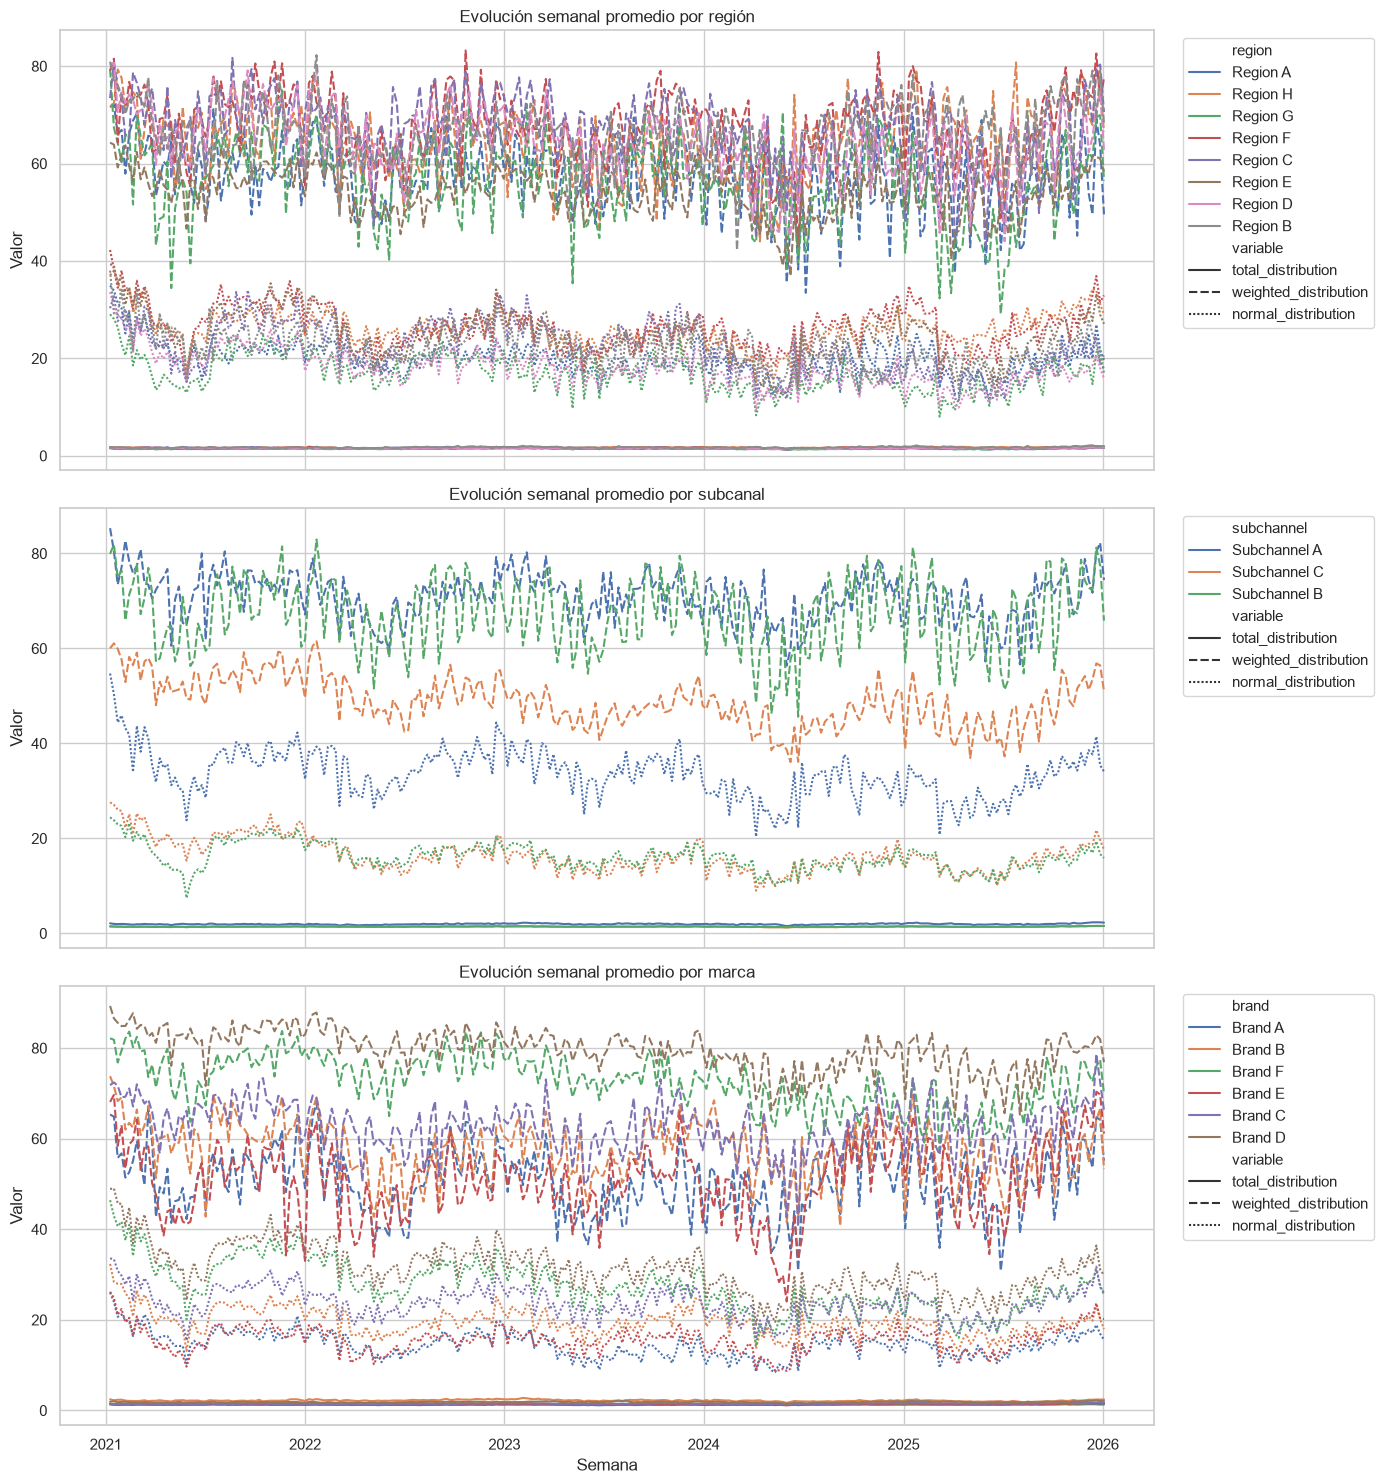

,week,region,subchannel,brand,normal_distribution,total_distribution,weighted_distribution
0,2021-01-09,Region A,Subchannel A,Brand A,52.272727,1.260870,70.309602
1,2021-01-09,Region A,Subchannel A,Brand B,65.909091,3.793103,98.791241
2,2021-01-09,Region A,Subchannel A,Brand C,65.909091,2.103448,73.756538
3,2021-01-09,Region A,Subchannel A,Brand D,81.818182,3.194444,99.967241
4,2021-01-09,Region A,Subchannel A,Brand E,59.090909,1.923077,82.721458
...,...,...,...,...,...,...,...
37573,2026-01-03,Region H,Subchannel C,Brand B,22.995825,2.027385,51.436810
37574,2026-01-03,Region H,Subchannel C,Brand C,24.304819,1.574462,61.700406
37575,2026-01-03,Region H,Subchannel C,Brand D,33.913536,1.937057,75.473173
37576,2026-01-03,Region H,Subchannel C,Brand E,20.342461,1.458116,52.769630


In [18]:
explorar_panel_distribucion_lienzo(table3)

### Tabla 4. Variables de contexto por región y semana: clima, ingreso regional, feriados y eventos.

Observaciones:

Las variables `evento_deportivo`, `evento_social` y `feriado` comparten 1,728 valores faltantes. Por el patrón conjunto de ausencia, se asume que esos faltantes representan semanas sin eventos registrados y se completan con cero. Esta decisión queda explícita como un supuesto de preparación de datos.

`evento_deportivo` y `evento_social` sí son indicadores binarios: únicamente toman los valores 0 y 1. En cambio, `feriado` toma los valores 0, 1 y 2; por tanto, no se trata como dummy, sino como una variable discreta que representa la cantidad o intensidad de feriados registrada en la semana. En el modelo, su coeficiente se interpreta por cada unidad adicional de `feriado`.

El ingreso regional presenta una frecuencia distinta a la semanal y no tiene registros antes de 2023. Se aplica llenado hacia adelante exclusivamente dentro de cada región y en orden cronológico, sin completar hacia atrás. De esta manera, 2021 y 2022 permanecen como faltantes y no reciben información futura.

La imputación se realiza en la Tabla 4 antes de expandirla al nivel de marca y subcanal. Esto evita que el último valor de una combinación comercial se propague sobre períodos anteriores de otra combinación. Debido a su cobertura incompleta y elevada proporción de faltantes, `income_region` se conserva para diagnóstico, pero se excluye del modelo final.

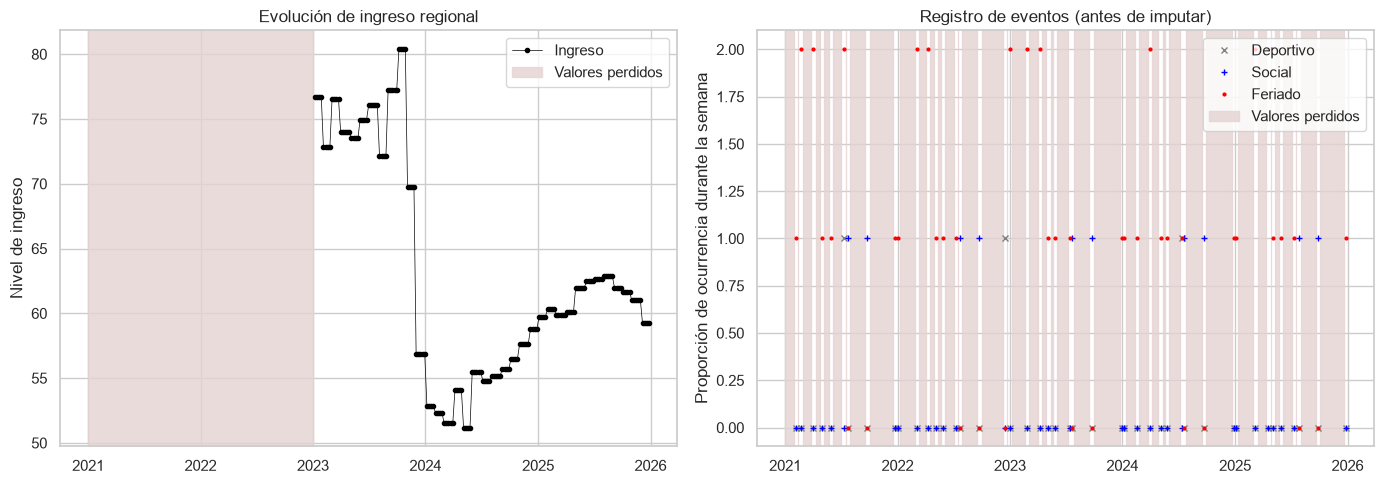

In [19]:
# Agrupación temporal incluyendo variables de eventos
variables = ['income_region', 'evento_deportivo', 'evento_social', 'feriado']
table4_pre = table4.groupby('week')[variables].mean().reset_index()

fig, lienzo_pre = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# ---------------- GRÁFICO 1: INGRESOS ----------------
lienzo_pre[0].plot(table4_pre['week'], table4_pre['income_region'], label='Ingreso', color='black', marker='o', markersize=3, linestyle='-', linewidth=0.5)

# Sombreado para faltantes en ingresos
missing_mask_income = table4_pre['income_region'].isna()
lienzo_pre[0].fill_between(
    table4_pre['week'], 
    0, 1, 
    where=missing_mask_income, 
    color='#e5d3d3',
    alpha=0.8, 
    transform=lienzo_pre[0].get_xaxis_transform(), 
    label='Valores perdidos'
)

lienzo_pre[0].set_title('Evolución de ingreso regional')
lienzo_pre[0].set_ylabel('Nivel de ingreso')
lienzo_pre[0].legend()

# ---------------- GRÁFICO 2: EVENTOS ----------------
lienzo_pre[1].plot(table4_pre['week'], table4_pre['evento_deportivo'], label='Deportivo', color='gray', marker='x', markersize=4, linestyle='none')
lienzo_pre[1].plot(table4_pre['week'], table4_pre['evento_social'], label='Social', color='blue', marker='+', markersize=4, linestyle='none')
lienzo_pre[1].plot(table4_pre['week'], table4_pre['feriado'], label='Feriado', color='red', marker='.', markersize=4, linestyle='none')

# NUEVO: Sombreado para faltantes en el registro de eventos
missing_mask_events = table4_pre['evento_deportivo'].isna()
lienzo_pre[1].fill_between(
    table4_pre['week'], 
    0, 1, 
    where=missing_mask_events, 
    color='#e5d3d3', 
    alpha=0.8, 
    transform=lienzo_pre[1].get_xaxis_transform(), 
    label='Valores perdidos'
)

lienzo_pre[1].set_title('Registro de eventos (antes de imputar)')
lienzo_pre[1].set_ylabel('Proporción de ocurrencia durante la semana')
lienzo_pre[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# Evitar repetir la imputación si esta celda ya se ejecutó sobre el mismo table4.
event_binary_cols = ['evento_deportivo', 'evento_social']
holiday_count_col = 'feriado'
context_event_cols = event_binary_cols + [holiday_count_col]

imputacion_ya_realizada = (
    'table4_clean' in globals()
    and table4_clean.attrs.get('table4_source_id') == id(table4)
)

if imputacion_ya_realizada:
    print('La imputación ya había sido realizada; se conserva table4_clean.')
else:
    table4_clean = table4.copy()
    table4_clean['week'] = pd.to_datetime(table4_clean['week'])

    for col in event_binary_cols:
        valores = set(table4_clean[col].dropna().unique())
        if not valores.issubset({0, 1}):
            raise ValueError(f'{col} contiene valores distintos de 0 y 1: {valores}')

    feriados_observados = table4_clean[holiday_count_col].dropna()
    if (
        (feriados_observados < 0).any()
        or not np.allclose(feriados_observados, np.round(feriados_observados))
    ):
        raise ValueError('feriado debe contener conteos enteros no negativos.')

    # Los faltantes compartidos se interpretan como ausencia de eventos registrados.
    table4_clean[context_event_cols] = (
        table4_clean[context_event_cols].fillna(0)
    )

    # El ingreso se propaga cronologicamente solo dentro de cada región antes de la imputación de eventos (aunque luego no se use para modelado, es útil para inspección visual de la serie temporal
    table4_clean = table4_clean.sort_values(['region', 'week'])
    table4_clean['income_region'] = (
        table4_clean.groupby('region', sort=False)['income_region'].ffill()
    )

    table4_clean = (
        table4_clean.sort_values(['week', 'region'])
        .reset_index(drop=True)
    )
    table4_clean.attrs['table4_source_id'] = id(table4)

print('Valores de evento deportivo:', sorted(table4_clean['evento_deportivo'].unique()))
print('Valores de evento social:', sorted(table4_clean['evento_social'].unique()))
print('Valores de feriado:', sorted(table4_clean['feriado'].unique()))
print(
    'Faltantes de ingreso regional tras ffill por región:',
    int(table4_clean['income_region'].isna().sum())
)

Valores de evento deportivo: [np.float64(0.0), np.float64(1.0)]
Valores de evento social: [np.float64(0.0), np.float64(1.0)]
Valores de feriado: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
Faltantes de ingreso regional tras ffill por región: 840


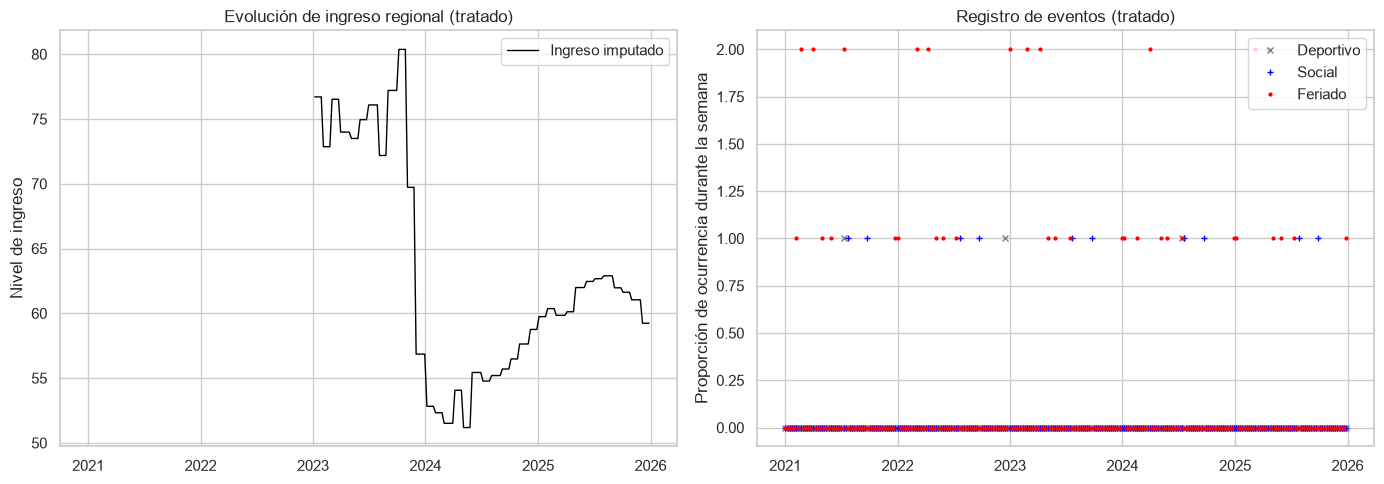

In [21]:
# Agrupación temporal con el panel tratado
variables = ['income_region', 'evento_deportivo', 'evento_social', 'feriado']
table4_post = table4_clean.groupby('week')[variables].mean().reset_index()

fig, lienzo_post = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# ---------------- GRÁFICO 1: INGRESOS TRATADO POR FALTANTES ----------------
lienzo_post[0].plot(table4_post['week'], table4_post['income_region'], label='Ingreso imputado', color='black', linewidth=1)
lienzo_post[0].set_title('Evolución de ingreso regional (tratado)')
lienzo_post[0].set_ylabel('Nivel de ingreso')
lienzo_post[0].legend()

# ---------------- GRÁFICO 2: EVENTOS TRATADO POR FALTANTES ----------------
lienzo_post[1].plot(table4_post['week'], table4_post['evento_deportivo'], label='Deportivo', color='gray', marker='x', markersize=4, linestyle='none')
lienzo_post[1].plot(table4_post['week'], table4_post['evento_social'], label='Social', color='blue', marker='+', markersize=4, linestyle='none')
lienzo_post[1].plot(table4_post['week'], table4_post['feriado'], label='Feriado', color='red', marker='.', markersize=4, linestyle='none')
lienzo_post[1].set_title('Registro de eventos (tratado)')
lienzo_post[1].set_ylabel('Proporción de ocurrencia durante la semana')
lienzo_post[1].legend()

plt.tight_layout()
plt.show()

Observaciones: 

Las series temporales muestran una alta variabilidad semanal (picos y caídas constantes), lo cual es típico en datos en punto de venta debido a quiebres de stock temporales, activaciones promocionales o ciclos de reposición de productos. A pesar del ruido semanal, el comportamiento agregado entre 2021 y 2026 se mantiene estable; las marcas mantienen su jerarquía y niveles de distribución sin mostrar crecimientos explosivos o declives catastróficos sostenidos en ese periodo de cinco años.

# Integración de las Tablas

Observaciones: 

Para unificar las cuatro tablas en un único panel de datos para analizar, la estrategia será la de usar la Tabla 1 como la base o maestra, ya que posee el nivel de granularidad más detallado (week, brand, subchannel, region). A partir de ahí, el resto de las tablas se incorporarán mediante cruces (merge) utilizando sus respectivas variables llave compartidas.

* Tabla 1 (Base): Contiene el volumen de ventas y la facturación a nivel de semana, marca, subcanal y región.

* Tabla 3 (Distribución): Se encuentra en formato largo. Requiere un pivoteo previo para convertirla a formato ancho, alineándose exactamente con la misma granularidad de la Tabla 1 (week, brand, subchannel, region).

* Tabla 4 (Contexto regional y clima): Posee granularidad semanal y regional (week, region). Se une a la base mediante estas dos dimensiones.

* Tabla 2 (Marketing y publicidad): Cuenta con granularidad semanal y por marca (week, brands). Se incorpora mediante un cruce por fecha y marca.

In [22]:
# 1. Pivotar Tabla 3 de formato largo a ancho
tabla3_ancho = table3.pivot_table(
    index=['week', 'region', 'subchannel', 'brand'],
    columns='variable',
    values='value'
).reset_index()
tabla3_ancho.columns.name = None

# 2. Integrar las fuentes usando la Tabla 4 ya tratada a nivel región-semana.
master_df = table1.merge(
    tabla3_ancho,
    on=['week', 'region', 'subchannel', 'brand'],
    how='left',
    validate='one_to_one'
)
master_df = master_df.merge(
    table4_clean,
    on=['week', 'region'],
    how='left',
    validate='many_to_one'
)
master_df = master_df.merge(
    table2,
    on=['week', 'brand'],
    how='left',
    validate='many_to_one'
)

# 3. Validar la codificación de eventos después de la integración.
for col in event_binary_cols:
    valores = set(master_df[col].dropna().unique())
    if not valores.issubset({0, 1}):
        raise ValueError(f'{col} dejó de ser binaria después del cruce: {valores}')

feriados_integrados = master_df[holiday_count_col].dropna()
if (
    (feriados_integrados < 0).any()
    or not np.allclose(feriados_integrados, np.round(feriados_integrados))
):
    raise ValueError('feriado dejó de ser un conteo entero no negativo.')

master_df = (
    master_df.sort_values(['week', 'brand', 'subchannel', 'region'])
    .reset_index(drop=True)
)

print('Dimensiones del DataFrame maestro integrado:', master_df.shape)
print(
    'Ingreso regional faltante (%):',
    round(master_df['income_region'].isna().mean() * 100, 2)
)

Dimensiones del DataFrame maestro integrado: (39721, 29)
Ingreso regional faltante (%): 43.46


### Validación posintegración

In [23]:
#Para un panel correctamente integrado, deberías ver la misma cantidad de filas 
# y los mismos totales de volume_hl y net_revenue_adj_CPI que en table1.

# Llave esperada de la tabla maestra
keys = ['week', 'brand', 'subchannel', 'region']
targets = ['volume_hl', 'net_revenue_adj_CPI']

# Asegurar formato temporal para los análisis por año
table1_check = table1.copy()
master_check = master_df.copy()

table1_check['week'] = pd.to_datetime(table1_check['week'])
master_check['week'] = pd.to_datetime(master_check['week'])

# 1. Tamaño y unicidad de la llave
duplicados_master = master_check.duplicated(keys, keep=False)
filas_esperadas = len(table1_check)
filas_master = len(master_check)

resumen_integracion = pd.DataFrame({
    'métrica': [
        'Filas en Table 1',
        'Filas en master_df',
        'Diferencia de filas',
        'Llaves duplicadas en master_df'
    ],
    'valor': [
        filas_esperadas,
        filas_master,
        filas_master - filas_esperadas,
        duplicados_master.sum()
    ]
})

# 2. Conservación de las variables objetivo
ventas_origen = table1_check[targets].sum()
ventas_master = master_check[targets].sum()

control_ventas = pd.DataFrame({
    'Table 1': ventas_origen,
    'master_df': ventas_master
})
control_ventas['diferencia'] = (
    control_ventas['master_df'] - control_ventas['Table 1']
)
control_ventas['diferencia_pct'] = np.where(
    control_ventas['Table 1'].ne(0),
    control_ventas['diferencia'] / control_ventas['Table 1'] * 100,
    np.nan
)

# 3. Faltantes posteriores a la integración
faltantes = (
    master_check.isna()
    .mean()
    .mul(100)
    .round(2)
    .rename('faltantes_pct')
    .to_frame()
    .query('faltantes_pct > 0')
    .sort_values('faltantes_pct', ascending=False)
)

# 4. Cobertura temporal de las variables relevantes
variables_cobertura = [
    'volume_hl', 'net_revenue_adj_CPI', 'income_region',
    'evento_deportivo', 'evento_social', 'feriado'
]
variables_cobertura = [
    col for col in variables_cobertura if col in master_check.columns
]

cobertura_anual = (
    master_check
    .assign(anio=master_check['week'].dt.year)
    .groupby('anio')[variables_cobertura]
    .agg(lambda serie: serie.notna().mean() * 100)
    .round(1)
)

# 5. Alertas
alertas = []

if filas_master != filas_esperadas:
    alertas.append(
        'ALERTA: master_df no conserva la misma cantidad de filas que la Tabla 1.'
    )

if duplicados_master.any():
    alertas.append(
        'ALERTA: existen llaves duplicadas; revisar los joins antes de cualquier otra cosa.'
    )

if not np.allclose(
    ventas_origen.values,
    ventas_master.values,
    rtol=1e-8,
    atol=1e-8,
    equal_nan=True
):
    alertas.append(
        'ALERTA: volumen o revenue cambiaron después de los joins.'
    )

if master_check[targets].isna().any().any():
    alertas.append(
        'ALERTA: hay valores faltantes en la variable objetivo.'
    )

# Resultados
print('VALIDACIÓN POSINTEGRACIÓN')
print('-' * 60)
display(resumen_integracion)
display(control_ventas)
print('Faltantes posteriores a la integración:')
display(faltantes)
print('Cobertura anual de variables relevantes (% no nulo):')
display(cobertura_anual)

if alertas:
    print('\n'.join(alertas))
else:
    print('OK: no se detectaron problemas estructurales en la integración.')


VALIDACIÓN POSINTEGRACIÓN
------------------------------------------------------------


,métrica,valor
0,Filas en Table 1,39721
1,Filas en master_df,39721
2,Diferencia de filas,0
3,Llaves duplicadas en master_df,0


,Table 1,master_df,diferencia,diferencia_pct
volume_hl,3.558780e+07,3.558780e+07,0.0,0.0
net_revenue_adj_CPI,7.772519e+06,7.772519e+06,0.0,0.0


Faltantes posteriores a la integración:


,faltantes_pct
opentv,44.97
localtv,44.97
instagram,44.97
digitalvideo,44.97
facebook,44.97
cinema,44.97
digitaldisplayandsearch,44.97
radio,44.97
tiktok,44.97
paytv,44.97


Cobertura anual de variables relevantes (% no nulo):


,volume_hl,net_revenue_adj_CPI,income_region,evento_deportivo,evento_social,feriado
anio,,,,,,
2021,100.0,100.0,0.0,100.0,100.0,100.0
2022,100.0,100.0,0.0,100.0,100.0,100.0
2023,100.0,100.0,100.0,100.0,100.0,100.0
2024,100.0,100.0,100.0,100.0,100.0,100.0
2025,100.0,100.0,100.0,100.0,100.0,100.0
2026,100.0,100.0,0.0,0.0,0.0,0.0


OK: no se detectaron problemas estructurales en la integración.


## Diagnóstico de valores atípicos en `volume_hl`


### Valores atípicos por marca, canal, subcanal y medio

El criterio descriptivo es el mismo en todos los casos: una observación se identifica como atípica cuando queda fuera de $[Q1-1.5\,IQR,\;Q3+1.5\,IQR]$, calculado dentro de cada grupo. **Canal** representa cada variable individual de inversión; **medio** agrupa canales afines según el diccionario explícito de la celda; y **subcanal** corresponde a la dimensión comercial de ventas. Para canal y medio se analizan únicamente inversiones positivas, porque cero significa ausencia de campaña y no una inversión extrema. La identificación es diagnóstica y no implica eliminar automáticamente las observaciones.

In [24]:
# Diagnóstico descriptivo de valores atípicos por dimensión
def tabla_iqr(datos, grupo, valor, etiqueta_grupo):
    filas = []
    for categoria, bloque in datos.groupby(grupo, observed=True):
        serie = pd.to_numeric(bloque[valor], errors='coerce').dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        es_atipico = serie.lt(limite_inferior) | serie.gt(limite_superior)
        filas.append({
            etiqueta_grupo: categoria,
            'n_observaciones': len(serie),
            'q1': q1,
            'q3': q3,
            'iqr': iqr,
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior,
            'n_atipicos': int(es_atipico.sum()),
            'porcentaje_atipicos': es_atipico.mean() * 100
        })
    return pd.DataFrame(filas)


def mostrar_iqr(datos, grupo, valor, etiqueta_grupo, titulo, eje_x):
    categorias = datos[grupo].nunique(dropna=True)
    if categorias > 8:
        plt.figure(figsize=(11, max(5, categorias * 0.42)))
        sns.boxplot(data=datos, y=grupo, x=valor, color='#8CB9C7')
        plt.xlabel(eje_x)
        plt.ylabel(etiqueta_grupo.title())
    else:
        plt.figure(figsize=(11, 5))
        sns.boxplot(data=datos, x=grupo, y=valor, color='#8CB9C7')
        plt.xlabel(etiqueta_grupo.title())
        plt.ylabel(eje_x)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

    resumen = tabla_iqr(datos, grupo, valor, etiqueta_grupo)
    display(resumen.round(3))
    return resumen


# Marca y subcanal: se analiza el volumen vendido.
datos_ventas_atipicos = master_df[
    ['brand', 'subchannel', 'volume_hl']
].dropna(subset=['volume_hl']).copy()




# Canal: cada columna individual de inversión de la tabla de medios.
columnas_id_medios = ['brand', 'week']
canales_medios = [
    columna for columna in table2.columns
    if columna not in columnas_id_medios
]
inversion_por_canal = table2.melt(
    id_vars=columnas_id_medios,
    value_vars=canales_medios,
    var_name='canal',
    value_name='inversion'
)
inversion_por_canal['inversion'] = pd.to_numeric(
    inversion_por_canal['inversion'], errors='coerce'
)
inversion_por_canal = inversion_por_canal[
    inversion_por_canal['inversion'].gt(0)
].copy()



# Medio: familia de canales definida explícitamente para el análisis.
medio_por_canal = {
    'cinema': 'Cine',
    'digitaldisplayandsearch': 'Display y búsqueda',
    'digitalvideo': 'Video digital',
    'youtube': 'Video digital',
    'facebook': 'Redes sociales',
    'instagram': 'Redes sociales',
    'tiktok': 'Redes sociales',
    'twitter': 'Redes sociales',
    'localtv': 'Televisión',
    'opentv': 'Televisión',
    'paytv': 'Televisión',
    'ooh': 'Publicidad exterior',
    'print': 'Medios impresos',
    'radio': 'Radio'
}

canales_sin_medio = sorted(set(canales_medios) - set(medio_por_canal))
if canales_sin_medio:
    raise ValueError(
        f'Falta asignar una familia de medio a: {canales_sin_medio}'
    )

inversion_por_medio = table2.melt(
    id_vars=columnas_id_medios,
    value_vars=canales_medios,
    var_name='canal',
    value_name='inversion'
)
inversion_por_medio['inversion'] = pd.to_numeric(
    inversion_por_medio['inversion'], errors='coerce'
).fillna(0)
inversion_por_medio['medio'] = inversion_por_medio['canal'].map(
    medio_por_canal
)
inversion_por_medio = (
    inversion_por_medio
    .groupby(['brand', 'week', 'medio'], as_index=False, observed=True)
    ['inversion'].sum()
)
inversion_por_medio = inversion_por_medio[
    inversion_por_medio['inversion'].gt(0)
].copy()


#### Atípicos por marca

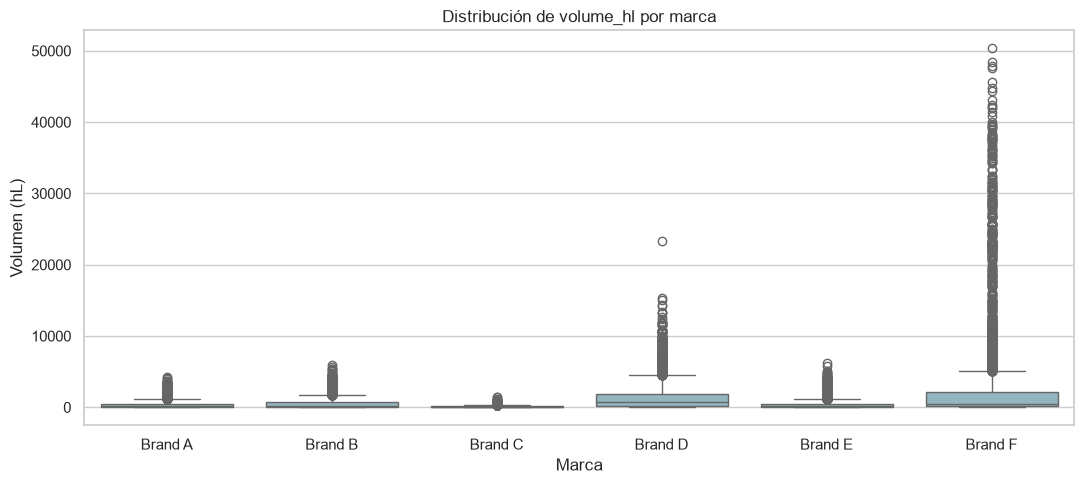

,marca,n_observaciones,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,porcentaje_atipicos
0,Brand A,6621,54.589,510.192,455.604,-628.816,1193.598,657,9.923
1,Brand B,6616,86.176,718.637,632.461,-862.516,1667.329,411,6.212
2,Brand C,6621,31.552,144.305,112.754,-137.579,313.436,496,7.491
3,Brand D,6621,232.129,1931.664,1699.535,-2317.173,4480.966,425,6.419
4,Brand E,6621,89.833,498.019,408.185,-522.445,1110.297,549,8.292
5,Brand F,6621,152.122,2116.360,1964.238,-2794.235,5062.717,861,13.004


In [25]:
tabla_atipicos_marca = mostrar_iqr(
    datos_ventas_atipicos.dropna(subset=['brand']),
    grupo='brand',
    valor='volume_hl',
    etiqueta_grupo='marca',
    titulo='Distribución de volume_hl por marca',
    eje_x='Volumen (hL)'
)

#### Atípicos por subcanal

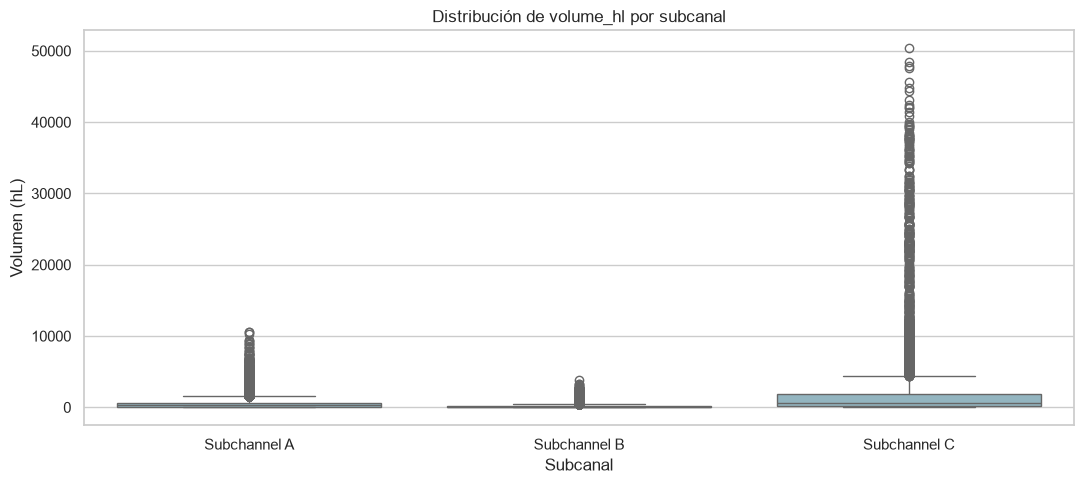

,subcanal,n_observaciones,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,porcentaje_atipicos
0,Subchannel A,13225,84.223,662.413,578.191,-783.064,1529.700,1132,8.560
1,Subchannel B,13248,38.391,191.042,152.651,-190.586,420.018,1409,10.636
2,Subchannel C,13248,224.649,1912.189,1687.540,-2306.660,4443.498,1292,9.752


In [26]:
tabla_atipicos_subcanal = mostrar_iqr(
    datos_ventas_atipicos.dropna(subset=['subchannel']),
    grupo='subchannel',
    valor='volume_hl',
    etiqueta_grupo='subcanal',
    titulo='Distribución de volume_hl por subcanal',
    eje_x='Volumen (hL)'
)

#### Atípicos por canal de medios

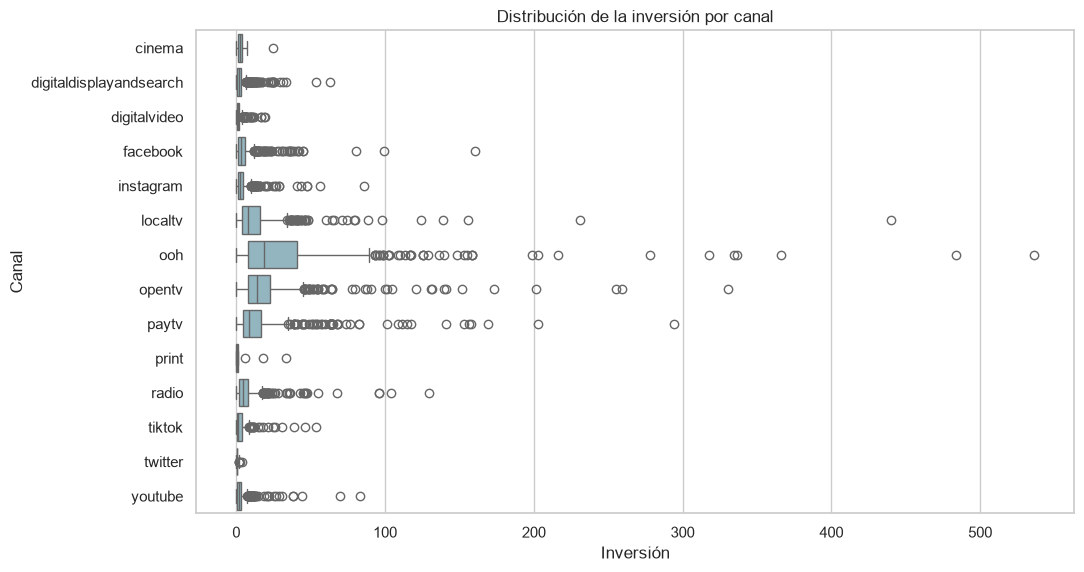

,canal,n_observaciones,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,porcentaje_atipicos
0,cinema,39,0.921,4.096,3.175,-3.841,8.858,1,2.564
1,digitaldisplayandsearch,813,0.675,3.101,2.426,-2.963,6.740,75,9.225
2,digitalvideo,756,0.487,1.934,1.447,-1.684,4.105,51,6.746
3,facebook,896,1.440,5.732,4.292,-4.999,12.170,64,7.143
4,instagram,898,1.136,4.682,3.546,-4.182,10.000,50,5.568
5,localtv,591,3.767,15.855,12.089,-14.366,33.989,44,7.445
6,ooh,723,7.933,40.531,32.598,-40.965,89.428,41,5.671
7,opentv,701,7.810,22.739,14.928,-14.582,45.131,48,6.847
8,paytv,753,4.746,16.657,11.911,-13.120,34.523,56,7.437
9,print,22,0.100,1.178,1.079,-1.518,2.796,3,13.636


In [27]:
tabla_atipicos_canal = mostrar_iqr(
    inversion_por_canal,
    grupo='canal',
    valor='inversion',
    etiqueta_grupo='canal',
    titulo='Distribución de la inversión por canal',
    eje_x='Inversión'
)

#### Atípicos por familia de medios

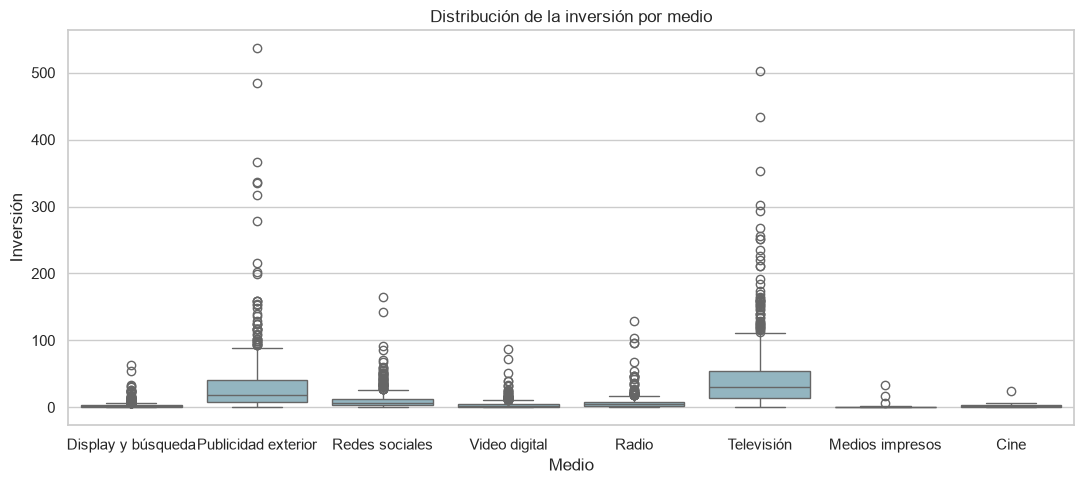

,medio,n_observaciones,q1,q3,iqr,limite_inferior,limite_superior,n_atipicos,porcentaje_atipicos
0,Cine,39,0.921,4.096,3.175,-3.841,8.858,1,2.564
1,Display y búsqueda,813,0.675,3.101,2.426,-2.963,6.740,75,9.225
2,Medios impresos,22,0.100,1.178,1.079,-1.518,2.796,3,13.636
3,Publicidad exterior,723,7.933,40.531,32.598,-40.965,89.428,41,5.671
4,Radio,679,1.500,7.761,6.261,-7.892,17.152,42,6.186
5,Redes sociales,898,2.997,12.455,9.458,-11.190,26.642,52,5.791
6,Televisión,771,14.531,53.615,39.084,-44.095,112.241,50,6.485
7,Video digital,886,1.157,5.156,3.999,-4.842,11.155,57,6.433


In [28]:
tabla_atipicos_medio = mostrar_iqr(
    inversion_por_medio,
    grupo='medio',
    valor='inversion',
    etiqueta_grupo='medio',
    titulo='Distribución de la inversión por medio',
    eje_x='Inversión'
)

Observaciones: 

El gráfico de cajas y la tabla resumen muestran el comportamiento del volumen en hectolitros para seis marcas distintas. La muestra es equilibrada, con aproximadamente 6620 observaciones para cada marca.

Mayor dispersión y volumen: Brand F domina en términos de magnitud y variabilidad. Posee el rango intercuartílico (IQR) más amplio con 1964.24 hL y presenta la mayor concentración de valores atípicos, alcanzando picos cercanos a los 50,000 hL. El 13% de sus registros caen fuera del límite superior esperado.

Segundo en escala: Brand D muestra un comportamiento similar a Brand F pero a una escala reducida. Su IQR es de 1699.54 hL y sus valores extremos alcanzan un máximo alrededor de los 25,000 hL.

Mayor consistencia: Brand C es la marca con la distribución más estable y predecible. Tiene el IQR más estrecho (112.75 hL) y sus valores atípicos se mantienen en un rango muy bajo en comparación con el resto.

Frecuencia de valores atípicos: A pesar de que Brand A maneja un límite superior de apenas 1193.60 hL, casi el 10% de sus observaciones son atípicas. Esto sugiere que, aunque su volumen base es bajo, experimenta picos de volumen con bastante regularidad.

Asimetría de la distribución: Los límites inferiores matemáticos resultan negativos para todas las marcas. Dado que una medida de volumen no puede ser inferior a cero, esto confirma que todas las distribuciones tienen un fuerte sesgo positivo, con la mayoría de los datos concentrados en los valores bajos y una larga cola hacia la derecha generada por los extremos.

In [29]:
# Promedio de volume_hl por cuartil de total_distribution y marca
distribucion_cuartiles = master_df[
    ['brand', 'total_distribution', 'volume_hl']
].dropna().copy()

def asignar_cuartiles(serie):
    cuartil = pd.qcut(
        serie,
        q=4,
        labels=False,
        duplicates='drop'
    )
    return cuartil.map(
        lambda valor: f'Q{int(valor) + 1}'
        if pd.notna(valor)
        else np.nan
    )

distribucion_cuartiles['cuartil_distribucion'] = (
    distribucion_cuartiles
    .groupby('brand')['total_distribution']
    .transform(asignar_cuartiles)
)

promedio_volumen_distribucion = (
    distribucion_cuartiles
    .dropna(subset=['cuartil_distribucion'])
    .groupby(
        ['brand', 'cuartil_distribucion'],
        as_index=False
    )
    .agg(
        observaciones=('volume_hl', 'size'),
        distribucion_promedio=('total_distribution', 'mean'),
        volumen_promedio=('volume_hl', 'mean')
    )
    .sort_values(['brand', 'cuartil_distribucion'])
)

display(promedio_volumen_distribucion.round(3))


,brand,cuartil_distribucion,observaciones,distribucion_promedio,volumen_promedio
0,Brand A,Q1,1565,1.116,271.072
1,Brand A,Q2,1565,1.189,341.036
2,Brand A,Q3,1581,1.259,598.586
3,Brand A,Q4,1549,1.511,428.965
4,Brand B,Q1,1565,1.592,385.625
5,Brand B,Q2,1564,1.901,503.692
6,Brand B,Q3,1564,2.164,618.693
7,Brand B,Q4,1565,3.102,585.164
8,Brand C,Q1,1566,1.232,119.438
9,Brand C,Q2,1566,1.319,101.608


# Diagnósticos de estacionariedad de series temporales

In [30]:
# Definir el conjunto de series temporales antes de usarlas
if 'series_adf' not in globals():
    series_adf = (
        master_df.assign(week=pd.to_datetime(master_df['week']))
        .set_index('week')
        .select_dtypes(include=[np.number])
        .copy()
        .sort_index()
    )

variables_eventos_discretas = [
    'evento_deportivo',
    'evento_social',
    'feriado'
]

# ADF no es informativa para indicadores o conteos de eventos.
series_pruebas = series_adf.drop(
    columns=variables_eventos_discretas,
    errors='ignore'
)

def ejecutar_adf(serie, nombre, min_observaciones=30):
    serie_limpia = pd.to_numeric(serie, errors='coerce').dropna()

    resultado_base = {
        'variable': nombre,
        'n_obs': len(serie_limpia),
        'inicio': serie_limpia.index.min() if len(serie_limpia) else pd.NaT,
        'fin': serie_limpia.index.max() if len(serie_limpia) else pd.NaT
    }

    if len(serie_limpia) < min_observaciones:
        return {
            **resultado_base,
            'adf_stat': np.nan,
            'p_value': np.nan,
            'lags': np.nan,
            'conclusion': 'No evaluable: pocas observaciones'
        }

    if serie_limpia.nunique() <= 1:
        return {
            **resultado_base,
            'adf_stat': np.nan,
            'p_value': np.nan,
            'lags': np.nan,
            'conclusion': 'No evaluable: serie constante'
        }

    resultado = adfuller(
        serie_limpia,
        regression='c',
        autolag='AIC'
    )

    p_value = resultado[1]

    if p_value < 0.05:
        conclusion = 'Estacionaria: evidencia clara'
    elif p_value < 0.10:
        conclusion = 'Estacionaria: evidencia débil (10%)'
    else:
        conclusion = 'No se rechaza raíz unitaria'

    return {
        **resultado_base,
        'adf_stat': resultado[0],
        'p_value': p_value,
        'lags': resultado[2],
        'conclusion': conclusion
    }

resultados_adf = pd.DataFrame(
    [
        ejecutar_adf(series_pruebas[col], col)
        for col in series_pruebas.columns
    ]
).sort_values(
    by='p_value',
    na_position='last'
).reset_index(drop=True)

display(resultados_adf)

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


...

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(


,variable,n_obs,inicio,fin,adf_stat,p_value,lags,conclusion
0,volume_hl,39721,2021-01-09,2026-04-18,-23.526412,0.000000e+00,54,Estacionaria: evidencia clara
1,net_revenue_adj_CPI,39721,2021-01-09,2026-04-18,-21.267235,0.000000e+00,54,Estacionaria: evidencia clara
2,total_distribution,37567,2021-01-09,2026-01-03,-30.785903,0.000000e+00,53,Estacionaria: evidencia clara
3,weighted_distribution,37567,2021-01-09,2026-01-03,-20.840291,0.000000e+00,53,Estacionaria: evidencia clara
4,facebook,21858,2023-01-07,2025-12-27,-19.009561,0.000000e+00,47,Estacionaria: evidencia clara
5,digitalvideo,21858,2023-01-07,2025-12-27,-20.176280,0.000000e+00,47,Estacionaria: evidencia clara
6,digitaldisplayandsearch,21858,2023-01-07,2025-12-27,-20.312228,0.000000e+00,47,Estacionaria: evidencia clara
7,cinema,21858,2023-01-07,2025-12-27,-21.659801,0.000000e+00,47,Estacionaria: evidencia clara
8,instagram,21858,2023-01-07,2025-12-27,-19.663544,0.000000e+00,47,Estacionaria: evidencia clara
9,localtv,21858,2023-01-07,2025-12-27,-18.870433,0.000000e+00,47,Estacionaria: evidencia clara


In [31]:
# ADF por combinación marca-región-subcanal
llaves_panel = ['brand', 'region', 'subchannel']
variables_panel_adf = [
    variable
    for variable in series_pruebas.columns
    if variable in master_df.columns
]

resultados_adf_panel_detalle = []

for llaves, grupo in master_df.groupby(
    llaves_panel,
    dropna=False,
    sort=False
):
    grupo = grupo.sort_values('week')
    indice_semana = pd.to_datetime(grupo['week'])

    for variable in variables_panel_adf:
        serie = pd.Series(
            pd.to_numeric(grupo[variable], errors='coerce').to_numpy(),
            index=indice_semana
        )
        resultado = ejecutar_adf(
            serie,
            variable
        )
        resultados_adf_panel_detalle.append({
            'brand': llaves[0],
            'region': llaves[1],
            'subchannel': llaves[2],
            **resultado
        })

resultados_adf_panel_detalle = pd.DataFrame(
    resultados_adf_panel_detalle
)

resumen_adf_por_panel = (
    resultados_adf_panel_detalle
    .assign(
        evaluable=lambda df: df['p_value'].notna(),
        rechaza_raiz_5=lambda df: df['p_value'] < 0.05,
        rechaza_raiz_10=lambda df: df['p_value'] < 0.10
    )
    .groupby('variable', as_index=False)
    .agg(
        combinaciones_totales=('p_value', 'size'),
        combinaciones_evaluables=('evaluable', 'sum'),
        rechazos_5=('rechaza_raiz_5', 'sum'),
        rechazos_10=('rechaza_raiz_10', 'sum')
    )
)

resumen_adf_por_panel['porcentaje_rechaza_5'] = np.where(
    resumen_adf_por_panel['combinaciones_evaluables'] > 0,
    resumen_adf_por_panel['rechazos_5']
    / resumen_adf_por_panel['combinaciones_evaluables']
    * 100,
    np.nan
)

resumen_adf_por_panel['porcentaje_rechaza_10'] = np.where(
    resumen_adf_por_panel['combinaciones_evaluables'] > 0,
    resumen_adf_por_panel['rechazos_10']
    / resumen_adf_por_panel['combinaciones_evaluables']
    * 100,
    np.nan
)

display(resumen_adf_por_panel.round(3))


C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

...

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado = adfuller(
C:\Users\victo\AppData\Local\Temp\ipykernel_44716\1289877508.py:51: FutureWarning: adfuller currently 

,variable,combinaciones_totales,combinaciones_evaluables,rechazos_5,rechazos_10,porcentaje_rechaza_5,porcentaje_rechaza_10
0,avg_prcp,144,144,144,144,100.000,100.000
1,avg_temp,144,144,144,144,100.000,100.000
2,cinema,144,72,72,72,100.000,100.000
3,digitaldisplayandsearch,144,144,144,144,100.000,100.000
4,digitalvideo,144,144,144,144,100.000,100.000
5,facebook,144,144,144,144,100.000,100.000
6,income_region,144,144,0,0,0.000,0.000
7,instagram,144,144,144,144,100.000,100.000
8,localtv,144,144,121,121,84.028,84.028
9,net_revenue_adj_CPI,144,144,118,129,81.944,89.583


Observaciones: 

Los resultados de ADF sugieren que casi todas las series tienen un p-value prácticamente 0, y el estadístico de prueba ADF es negativo. Esto significa:

H0 del ADF: la serie tiene raíz unitaria (no es estacionaria).
Si p-value < 0.05, se rechaza H0.

Por lo que para fines de modelar, es seguro trabajar con las variables en nivel, sin caer en relaciones espurias. Es decir, por el momento no es necesario efectuar transformaciones de momento.


# Modelado

El modelo separara las ventas en una venta base y un efecto incremental asociado a la inversion en medios. La variable dependiente se transforma con log1p para reducir la influencia de picos extremos y modelar cambios relativos en el volumen.

$$
\log(1 + Y_{b,r,s,t}) =
Base_{b,r,s,t} +
\sum_{j=1}^{J}
\eta_j \cdot
\operatorname{Saturacion}
\left(
\operatorname{Adstock}(M_{j,b,t})
\right)
+
\varepsilon_{b,r,s,t}
$$

La venta base se define como:

$$
Base_{b,r,s,t} =
\alpha +
\alpha_b +
\alpha_r +
\alpha_s +
\beta_1 D_{b,r,s,t} +
\beta_2 C_{r,t} +
\beta_3 E_{r,t}
$$

Donde:

- $Y_{b,r,s,t}$ representa el volumen de ventas para cada marca, region, subcanal y semana.
- $D_{b,r,s,t}$ representa la distribucion ponderada.
- $C_{r,t}$ representa las variables de clima.
- $E_{r,t}$ representa eventos y feriados.
- $M_{j,b,t}$ representa la inversion del medio $j$ para cada marca y semana.
- $\varepsilon_{b,r,s,t}$ representa el error no explicado por el modelo.
- Los subindices $b$, $r$, $s$ y $t$ identifican marca, region, subcanal y semana. Los terminos $\alpha$, $\alpha_b$, $\alpha_r$ y $\alpha_s$ capturan el nivel base general y las diferencias estructurales entre categorias.

#### Efecto adstock: memoria publicitaria

El adstock captura el impacto residual de la publicidad. Con decaimiento geometrico, $A_t = M_t + \theta A_{t-1}$, donde $\theta$ indica que proporcion del efecto permanece en la semana siguiente.

#### Saturacion: rendimientos decrecientes

La funcion de Hill representa que el rendimiento marginal de la inversion disminuye a medida que aumenta la presion publicitaria:

$$
S(x) = \frac{x^\alpha}{x^\alpha + \gamma^\alpha}
$$

El parametro $\alpha$ controla la forma de la respuesta y $\gamma$ el punto de media saturacion. Primero se aplica adstock y luego saturacion.

El ingreso regional se excluye del modelo por su cobertura temporal incompleta y la elevada proporcion de valores imputados.

Los coeficientes se estiman sobre log1p(volume_hl). Para facilitar la lectura, se reporta tambien $100[\exp(\beta)-1]$, que expresa el cambio porcentual asociado a una unidad adicional del predictor, manteniendo constantes las demas variables. Las predicciones se retransforman a hectolitros mediante smearing de Duan para calcular las metricas de desempeno.

### Selección de la variable dependiente

La variable dependiente es el **volumen semanal de ventas en hectolitros**, porque representa directamente la demanda física generada. A diferencia de la facturación, el volumen no combina simultáneamente cambios en cantidad, precio y mezcla de productos, por lo que permite una lectura más directa de la relación entre ventas, distribución, clima, eventos y medios.

El volumen presenta picos elevados y observaciones iguales a cero. Por esta razón se modela:

$$
Y^* = \log(1 + volume\_hl)
$$

Se utiliza **log1p(volume_hl)** y no el logaritmo natural de volume_hl porque el mínimo observado es **0 hL**. El logaritmo de cero no está definido y produciría valores infinitos, lo que obligaría a eliminar o alterar observaciones válidas. En cambio, log1p conserva esos registros porque $\log(1+0)=0$.

La transformación también reduce la influencia de valores extremos, ayuda a estabilizar la variabilidad y permite que el modelo represente cambios proporcionales. Para volúmenes suficientemente grandes, log1p y el logaritmo natural producen resultados prácticamente equivalentes.

Los coeficientes se estiman en escala logarítmica. El efecto porcentual se presenta como:

$$
100 \times [\exp(\beta)-1]
$$

Para variables continuas, representa el cambio porcentual esperado ante una unidad adicional del predictor; para variables binarias o categorías, representa la diferencia porcentual respecto de la categoría de referencia. Estrictamente, con log1p el cambio se refiere a $1+volume\_hl$, aunque para volúmenes alejados de cero constituye una aproximación muy cercana al cambio porcentual del volumen.

Las predicciones se convierten nuevamente a hectolitros mediante la corrección de *smearing* de Duan. Por eso, las métricas de evaluación como RMSE, MAE y $R^2$ se reportan en la escala original del negocio.

El **ingreso regional se excluye** como predictor porque no cubre una parte importante del período y requiere una proporción elevada de valores imputados. Mantenerlo podría introducir una señal artificial y dificultar la interpretación del modelo.

### Categorías de referencia del modelo

Los efectos fijos se parametrizan usando **Marca C** y **Subcanal B** como categorías omitidas. Por tanto, los coeficientes de las demás marcas y subcanales representan diferencias respecto de esas dos referencias, manteniendo constantes las demás variables.

**TV local (`localtv`) se utiliza como comparador de negocio para ordenar y comentar los resultados de medios, pero no se omite de la regresión.** Las inversiones de medios son variables continuas que entran simultáneamente al MMM; cada canal necesita conservar su propio coeficiente para estimar su respuesta. Tratar TV local como categoría de referencia implicaría eliminar su efecto o reformular el modelo en diferencias relativas, lo que no corresponde a la especificación actual.

In [32]:
tabla_referencias_modelo = pd.DataFrame([
    {
        'componente': 'Efecto fijo de marca',
        'referencia': 'Marca C',
        'interpretacion': 'Diferencia frente a Marca C'
    },
    {
        'componente': 'Efecto fijo de subcanal',
        'referencia': 'Subcanal B',
        'interpretacion': 'Diferencia frente a Subcanal B'
    },
    {
        'componente': 'Medios continuos',
        'referencia': 'TV local como comparador',
        'interpretacion': 'Cada medio conserva su propio coeficiente'
    }
])
display(tabla_referencias_modelo)

,componente,referencia,interpretacion
0,Efecto fijo de marca,Marca C,Diferencia frente a Marca C
1,Efecto fijo de subcanal,Subcanal B,Diferencia frente a Subcanal B
2,Medios continuos,TV local como comparador,Cada medio conserva su propio coeficiente


In [33]:
# Variable dependiente
target_col = 'volume_hl'

# Identificadores y dimensión temporal
id_cols = [
    'week',
    'brand',
    'region',
    'subchannel'
]

# Inversión en medios:
# estas variables se transformarán posteriormente con adstock y saturación
media_cols = [
    'cinema',
    'digitaldisplayandsearch',
    'digitalvideo',
    'facebook',
    'instagram',
    'localtv',
    'ooh',
    'opentv',
    'paytv',
    'print',
    'radio',
    'tiktok',
    'twitter',
    'youtube'
]

# Variables estructurales de venta base
# Se mantienen en nivel según los resultados ADF disponibles
# y quedan pendientes de revisión.
base_numeric_cols = [
    'weighted_distribution',
    'avg_temp',
    'avg_prcp'
]

# Eventos: se mantienen como dummies sin ninguna transformación
event_cols = [
    'evento_deportivo',
    'evento_social',
    'feriado'
]

# Variables categóricas
categorical_cols = [
    'brand',
    'region',
    'subchannel'
]

# Categorías de referencia para los efectos fijos
reference_levels = {
    'brand': 'Brand C',
    'subchannel': 'Subchannel B'
}


def preparar_categorias_referencia(datos):
    resultado = datos.copy()
    for columna, referencia in reference_levels.items():
        if columna not in resultado.columns:
            continue
        niveles = sorted(
            resultado[columna].dropna().astype(str).unique().tolist()
        )
        if referencia not in niveles:
            raise ValueError(
                f'La referencia {referencia} no existe en {columna}.'
            )
        categorias = [
            referencia,
            *[nivel for nivel in niveles if nivel != referencia]
        ]
        resultado[columna] = pd.Categorical(
            resultado[columna].astype(str),
            categories=categorias
        )
    return resultado


media_comparador = 'localtv'

# Control de cambio estructural
structural_control_cols = [
    'digitalvideo_post_quiebre'
]

# Variables de entrada antes de transformar medios
feature_cols_base = (
    base_numeric_cols
    + event_cols
    + categorical_cols
    + structural_control_cols
)

# Variables que entrarán al modelo una vez transformados los medios
media_transformed_cols = [
    f'{col}_adstock_saturation'
    for col in media_cols
]

# Listado final esperado de predictores
feature_cols_final = (
    feature_cols_base
    + media_transformed_cols
)

# Variables excluidas del modelado
excluded_cols = [
    'net_revenue_adj_CPI',
    'income_region',
    'income_region_log_diff_1'
]

if any(col in feature_cols_final for col in excluded_cols):
    raise ValueError(
        'Una variable excluida aparece en feature_cols_final.'
    )

print('Referencias estructurales:', reference_levels)
print('Medio comparador para reportes:', media_comparador)
print('Variable objetivo:', target_col)
print('Canales de medios:', len(media_cols))
print('Predictores base:', len(feature_cols_base))
print('Predictores finales esperados:', len(feature_cols_final))

Referencias estructurales: {'brand': 'Brand C', 'subchannel': 'Subchannel B'}
Medio comparador para reportes: localtv
Variable objetivo: volume_hl
Canales de medios: 14
Predictores base: 10
Predictores finales esperados: 24


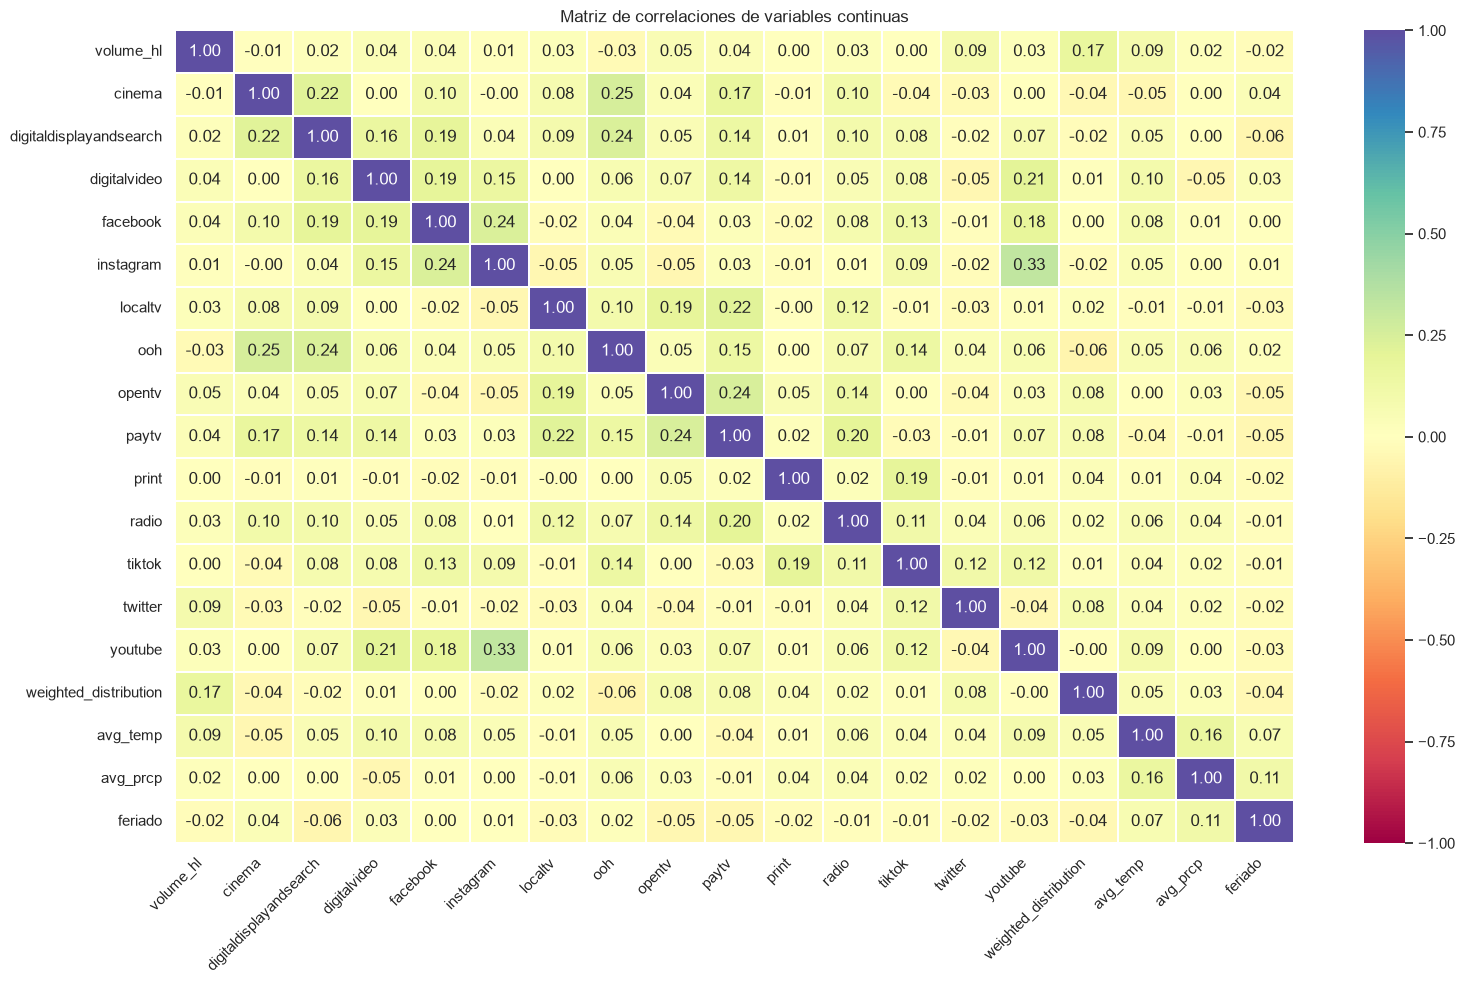

Variables dicotómicas excluidas:


,variable
0,evento_deportivo
1,evento_social


Correlación de las variables continuas con el volumen:


,correlacion_con_volumen
weighted_distribution,0.166
twitter,0.091
avg_temp,0.090
opentv,0.051
digitalvideo,0.045
paytv,0.039
facebook,0.038
radio,0.031
localtv,0.031
youtube,0.027


In [34]:
target_col = 'volume_hl'

candidate_corr_cols = list(dict.fromkeys(
    media_cols
    + base_numeric_cols
    + event_cols
    + structural_control_cols
))

candidate_corr_cols = [
    col for col in candidate_corr_cols
    if col in master_df.columns
]

def es_dicotomica(serie):
    valores = set(
        serie
        .dropna()
        .unique()
    )

    return (
        len(valores) <= 2
        and valores.issubset({
            0,
            1,
            True,
            False,
            '0',
            '1'
        })
    )

eventos_binarios_excluidos = [
    col for col in [
        'evento_deportivo',
        'evento_social'
    ]
    if col in master_df.columns
]

dicotomicas_detectadas = [
    col for col in candidate_corr_cols
    if es_dicotomica(master_df[col])
]

dicotomicas_excluidas = list(dict.fromkeys(
    eventos_binarios_excluidos
    + dicotomicas_detectadas
))

continuous_corr_cols = [
    col for col in candidate_corr_cols
    if col not in dicotomicas_excluidas
]

corr_cols = list(dict.fromkeys(
    [target_col]
    + continuous_corr_cols
))

corr_cols = [
    col for col in corr_cols
    if col in master_df.columns
]

if target_col not in master_df.columns:
    raise KeyError(
        f'{target_col} no está presente en master_df'
    )

if len(corr_cols) < 2:
    raise ValueError(
        'No hay suficientes variables continuas para calcular correlaciones.'
    )

corr_df = (
    master_df[corr_cols]
    .corr(
        method='pearson',
        min_periods=20
    )
)

plt.figure(figsize=(16, 10))

sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='Spectral',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.3,
    linecolor='white'
)

plt.title(
    'Matriz de correlaciones de variables continuas'
)

plt.xticks(
    rotation=45,
    ha='right'
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

corr_target = (
    corr_df[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
    .rename('correlacion_con_volumen')
    .to_frame()
)

print('Variables dicotómicas excluidas:')

display(
    pd.DataFrame({
        'variable': dicotomicas_excluidas
    })
)

print('Correlación de las variables continuas con el volumen:')

display(
    corr_target.round(3)
)

Observaciones:

La matriz muestra que ninguna variable tiene, por sí sola, una relación lineal fuerte con el volumen vendido en la misma semana. Las correlaciones más altas con volume_hl corresponden a Twitter y la temperatura promedio, ambas con 0.09. Los demás medios, la distribución y la precipitación presentan correlaciones cercanas a cero.

Esto no significa que estas variables no influyan en los volúmenes vendidos. La correlación de Pearson solo mide relaciones lineales y contemporáneas: compara la inversión de una semana con las ventas de esa misma semana. Sin embargo, la publicidad puede continuar generando efectos durante varias semanas y su impacto no necesariamente aumenta de manera proporcional al gasto. Una inversión adicional puede producir cada vez menos ventas cuando el canal comienza a saturarse.

La baja correlación de la distribución con el volumen también debe interpretarse con prudencia. La matriz combina marcas, regiones y subcanales con tamaños y niveles de venta diferentes. Estas diferencias pueden ocultar relaciones comerciales que solo aparecen cuando se comparan observaciones similares y se controlan esos factores.
Entre los medios se observan algunas correlaciones moderadas, como Instagram con YouTube (0.33), publicidad exterior con cine (0.25) y Facebook con Instagram (0.24). Esto sugiere que varios canales suelen activarse conjuntamente. Por lo tanto, analizar cada canal por separado podría asignarle un efecto que en realidad corresponde a una campaña combinada.

Estos resultados justifican avanzar hacia un Marketing Mix Modeling (MMM), que permita evaluar simultáneamente los distintos canales, separar las ventas base de las ventas asociadas con publicidad y controlar las diferencias de marca, región, subcanal, distribución, clima, eventos, feriados y diferencias estructurales.

Además, las inversiones se transformarán mediante adstock, para representar el efecto acumulado de la publicidad, y saturación, para capturar rendimientos decrecientes. De esta manera, el análisis no dependerá únicamente de correlaciones simples, sino de una estructura que representa mejor cómo las decisiones comerciales y publicitarias pueden relacionarse con las ventas a lo largo del tiempo.

In [35]:
# Construccion de model_df y calibracion logaritmica de medios
from itertools import product
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def adstock_geometrico(valores, theta):
    valores = np.asarray(valores, dtype=float)
    resultado = np.zeros(len(valores), dtype=float)

    for indice, valor in enumerate(valores):
        anterior = resultado[indice - 1] if indice > 0 else 0.0
        resultado[indice] = valor + theta * anterior

    return resultado

def saturacion_hill(valores, gamma, alpha):
    valores = np.asarray(valores, dtype=float)
    gamma = max(float(gamma), np.finfo(float).eps)
    numerador = np.power(np.clip(valores, 0, None), alpha)
    denominador = numerador + gamma ** alpha
    return np.divide(
        numerador,
        denominador,
        out=np.zeros_like(numerador, dtype=float),
        where=denominador > 0
    )

def adstock_por_marca(datos, canal, theta):
    resultado = pd.Series(index=datos.index, dtype=float)

    for _, indices in datos.groupby('brand', sort=False).groups.items():
        valores = datos.loc[indices, canal].fillna(0).to_numpy()
        resultado.loc[indices] = adstock_geometrico(valores, theta)

    return resultado.to_numpy()

media_model = table2[['week', 'brand'] + media_cols].copy()
media_model['week'] = pd.to_datetime(media_model['week'])
media_model = media_model.sort_values(
    ['brand', 'week']
).reset_index(drop=True)

if media_model.duplicated(['week', 'brand']).any():
    raise ValueError('Table 2 tiene duplicados por week y brand.')

for canal in media_cols:
    media_model[canal] = pd.to_numeric(
        media_model[canal],
        errors='coerce'
    ).fillna(0)

model_df_base = master_df.copy()
model_df_base['week'] = pd.to_datetime(model_df_base['week'])
model_df_base = model_df_base.merge(
    media_model[['week', 'brand']],
    on=['week', 'brand'],
    how='inner',
    validate='many_to_one'
)

semanas_modelo = (
    model_df_base['week']
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)
indice_prueba = int(len(semanas_modelo) * 0.80)
semana_inicio_prueba = semanas_modelo.iloc[indice_prueba]
semanas_desarrollo = semanas_modelo[
    semanas_modelo < semana_inicio_prueba
].reset_index(drop=True)

indice_validacion = int(len(semanas_desarrollo) * 0.80)
semana_inicio_validacion = semanas_desarrollo.iloc[indice_validacion]

mascara_calibracion = (
    model_df_base['week'] < semana_inicio_validacion
)
mascara_validacion = (
    (model_df_base['week'] >= semana_inicio_validacion)
    & (model_df_base['week'] < semana_inicio_prueba)
)

columnas_base_grilla = list(dict.fromkeys(
    base_numeric_cols
    + event_cols
    + categorical_cols
))
columnas_base_grilla = [
    columna
    for columna in columnas_base_grilla
    if columna in model_df_base.columns
    and columna not in excluded_cols
]

if any(
    columna.startswith('income_region')
    for columna in columnas_base_grilla
):
    raise ValueError(
        'El ingreso regional no debe entrar en la calibracion.'
    )

X_base_grilla = pd.get_dummies(
    preparar_categorias_referencia(
        model_df_base[columnas_base_grilla]
    ),
    columns=[
        columna
        for columna in categorical_cols
        if columna in columnas_base_grilla
    ],
    drop_first=True,
    dtype=float
)

imputador_grilla = SimpleImputer(strategy='median')
X_calibracion_base = imputador_grilla.fit_transform(
    X_base_grilla.loc[mascara_calibracion]
)
X_validacion_base = imputador_grilla.transform(
    X_base_grilla.loc[mascara_validacion]
)

y_calibracion_nivel = model_df_base.loc[
    mascara_calibracion,
    target_col
].to_numpy(dtype=float)
y_validacion_nivel = model_df_base.loc[
    mascara_validacion,
    target_col
].to_numpy(dtype=float)

if (y_calibracion_nivel < 0).any():
    raise ValueError(
        'log1p(volume_hl) requiere valores no negativos.'
    )

y_calibracion = np.log1p(y_calibracion_nivel)

llaves_modelo = pd.MultiIndex.from_frame(
    model_df_base[['week', 'brand']]
)

filas_grilla = []

for canal in media_cols:
    inversion_positiva = media_model.loc[
        (media_model['week'] < semana_inicio_validacion)
        & (media_model[canal] > 0),
        canal
    ]

    if inversion_positiva.empty:
        valores_gamma = [1.0, 1.0, 1.0]
    else:
        valores_gamma = np.percentile(
            inversion_positiva,
            [25, 50, 75]
        ).tolist()

    for theta, gamma, alpha in product(
        [0.3, 0.5, 0.7],
        valores_gamma,
        [1.0, 2.0]
    ):
        adstock = adstock_por_marca(
            media_model,
            canal,
            theta
        )
        transformacion = saturacion_hill(
            adstock,
            gamma,
            alpha
        )
        serie_transformada = pd.Series(
            transformacion,
            index=pd.MultiIndex.from_frame(
                media_model[['week', 'brand']]
            )
        )
        predictor_medio = (
            serie_transformada
            .reindex(llaves_modelo)
            .fillna(0)
            .to_numpy()
        )

        X_candidata_calibracion = np.column_stack([
            X_calibracion_base,
            predictor_medio[mascara_calibracion.to_numpy()]
        ])
        X_candidata_validacion = np.column_stack([
            X_validacion_base,
            predictor_medio[mascara_validacion.to_numpy()]
        ])

        modelo_candidato = LinearRegression().fit(
            X_candidata_calibracion,
            y_calibracion
        )
        pred_calibracion_log = modelo_candidato.predict(
            X_candidata_calibracion
        )
        factor_smearing_candidato = float(np.mean(
            np.exp(y_calibracion - pred_calibracion_log)
        ))
        pred_validacion_log = modelo_candidato.predict(
            X_candidata_validacion
        )
        pred_calibracion_hl = np.maximum(
            np.exp(pred_calibracion_log)
            * factor_smearing_candidato
            - 1,
            0
        )
        pred_validacion_hl = np.maximum(
            np.exp(pred_validacion_log)
            * factor_smearing_candidato
            - 1,
            0
        )
        coeficiente_medio = float(modelo_candidato.coef_[-1])

        filas_grilla.append({
            'canal': canal,
            'theta': theta,
            'gamma': gamma,
            'alpha': alpha,
            'coeficiente_medio': coeficiente_medio,
            'efecto_positivo': coeficiente_medio > 0,
            'RMSE_calibracion': mean_squared_error(
                y_calibracion_nivel,
                pred_calibracion_hl
            ) ** 0.5,
            'RMSE_validacion': mean_squared_error(
                y_validacion_nivel,
                pred_validacion_hl
            ) ** 0.5,
            'MAE_validacion': mean_absolute_error(
                y_validacion_nivel,
                pred_validacion_hl
            ),
            'R2_validacion': r2_score(
                y_validacion_nivel,
                pred_validacion_hl
            )
        })

grilla_resultados = pd.DataFrame(filas_grilla)
grilla_resultados['seleccionada'] = False
grilla_resultados['incluida_modelo'] = False

filas_seleccionadas = []

for canal, resultados_canal in grilla_resultados.groupby('canal'):
    resultados_positivos = resultados_canal[
        resultados_canal['efecto_positivo']
    ]

    if resultados_positivos.empty:
        indice_ganador = resultados_canal[
            'RMSE_validacion'
        ].idxmin()
        incluida_modelo = False
    else:
        indice_ganador = resultados_positivos[
            'RMSE_validacion'
        ].idxmin()
        incluida_modelo = True

    grilla_resultados.loc[indice_ganador, 'seleccionada'] = True
    grilla_resultados.loc[indice_ganador, 'incluida_modelo'] = (
        incluida_modelo
    )
    filas_seleccionadas.append(indice_ganador)

resumen_calibracion = (
    grilla_resultados.loc[
        filas_seleccionadas,
        [
            'canal',
            'theta',
            'gamma',
            'alpha',
            'coeficiente_medio',
            'RMSE_calibracion',
            'RMSE_validacion',
            'MAE_validacion',
            'R2_validacion',
            'incluida_modelo'
        ]
    ]
    .sort_values('canal')
    .reset_index(drop=True)
)

mejores_parametros = (
    resumen_calibracion[
        resumen_calibracion['incluida_modelo']
    ]
    .copy()
    .reset_index(drop=True)
)

canales_no_concluyentes = (
    resumen_calibracion.loc[
        ~resumen_calibracion['incluida_modelo'],
        'canal'
    ]
    .tolist()
)

media_transformed_cols = []

for _, parametros in mejores_parametros.iterrows():
    canal = parametros['canal']
    columna_salida = f'{canal}_adstock_saturation'
    adstock = adstock_por_marca(
        media_model,
        canal,
        parametros['theta']
    )
    media_model[columna_salida] = saturacion_hill(
        adstock,
        parametros['gamma'],
        parametros['alpha']
    )
    media_transformed_cols.append(columna_salida)

model_df = model_df_base.merge(
    media_model[
        ['week', 'brand'] + media_transformed_cols
    ],
    on=['week', 'brand'],
    how='left',
    validate='many_to_one'
)
model_df = model_df.sort_values('week').reset_index(drop=True)

print(
    'Calibracion:',
    model_df_base.loc[mascara_calibracion, 'week'].min().date(),
    'a',
    model_df_base.loc[mascara_calibracion, 'week'].max().date()
)
print(
    'Validacion:',
    model_df_base.loc[mascara_validacion, 'week'].min().date(),
    'a',
    model_df_base.loc[mascara_validacion, 'week'].max().date()
)
print('Canales incluidos:', len(mejores_parametros))
print('Canales no concluyentes:', canales_no_concluyentes)

display(resumen_calibracion.round(5))
display(
    grilla_resultados.sort_values(
        ['canal', 'RMSE_validacion']
    ).reset_index(drop=True).round(5)
)


Calibracion: 2023-01-07 a 2024-11-23
Validacion: 2024-11-30 a 2025-05-17
Canales incluidos: 8
Canales no concluyentes: ['cinema', 'digitaldisplayandsearch', 'ooh', 'print', 'tiktok', 'twitter']


,canal,theta,gamma,alpha,coeficiente_medio,RMSE_calibracion,RMSE_validacion,MAE_validacion,R2_validacion,incluida_modelo
0,cinema,0.3,4.09558,2.0,-0.18100,1585.35293,1631.35907,572.03544,0.57984,False
1,digitaldisplayandsearch,0.7,0.61853,2.0,-0.34409,1598.50431,1619.34419,559.65501,0.58600,False
2,digitalvideo,0.3,0.49151,1.0,0.00879,1582.70028,1626.10821,569.08399,0.58254,True
3,facebook,0.3,1.35884,2.0,0.38892,1588.61472,1638.24190,579.48843,0.57628,True
4,instagram,0.7,1.05411,2.0,0.46603,1582.42985,1633.08184,574.37152,0.57895,True
5,localtv,0.3,10.27983,1.0,0.06062,1578.76012,1621.77880,567.47181,0.58476,True
6,ooh,0.3,36.36367,2.0,-0.30090,1579.02968,1670.36672,557.76047,0.55950,False
7,opentv,0.5,15.21722,1.0,0.00034,1582.76647,1625.58410,568.95808,0.58281,True
8,paytv,0.5,18.98492,2.0,0.00528,1582.60887,1624.81729,568.79821,0.58320,True
9,print,0.3,0.07672,2.0,-0.37661,1585.47755,1631.29657,570.55573,0.57987,False


,canal,theta,gamma,alpha,coeficiente_medio,efecto_positivo,RMSE_calibracion,RMSE_validacion,MAE_validacion,R2_validacion,seleccionada,incluida_modelo
0,cinema,0.3,4.09558,2.0,-0.18100,False,1585.35293,1631.35907,572.03544,0.57984,True,False
1,cinema,0.3,2.65632,2.0,-0.18068,False,1585.90361,1633.00603,573.06518,0.57899,False,False
2,cinema,0.5,4.09558,2.0,-0.17656,False,1585.24383,1633.01617,572.98601,0.57898,False,False
3,cinema,0.3,4.09558,1.0,-0.25546,False,1586.12482,1633.87566,573.64113,0.57854,False,False
4,cinema,0.3,2.65632,1.0,-0.23318,False,1586.33720,1634.67795,574.16639,0.57812,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
247,youtube,0.3,4.34578,1.0,0.30790,True,1588.62341,1624.89377,555.60858,0.58316,False,False
248,youtube,0.5,4.34578,1.0,0.32114,True,1588.74888,1625.29194,554.39087,0.58296,False,False
249,youtube,0.5,4.34578,2.0,0.22411,True,1590.24173,1627.11632,554.39594,0.58202,False,False
250,youtube,0.3,4.34578,2.0,0.21218,True,1590.89752,1627.46355,556.49177,0.58184,False,False


Observaciones: Los canales publicitarios sin una respuesta positiva en la escala logaritmica se clasifican como no concluyentes. La seleccion minimiza el RMSE de validacion calculado en hectolitros despues de retransformar las predicciones.

In [36]:
# Lectura de alpha, theta y gamma seleccionados
from IPython.display import Markdown, display

nombres_calibracion = {
    'cinema': 'Cine',
    'digitaldisplayandsearch': 'Display y busqueda digital',
    'digitalvideo': 'Video digital',
    'facebook': 'Facebook',
    'instagram': 'Instagram',
    'localtv': 'TV local',
    'ooh': 'Publicidad exterior',
    'opentv': 'TV abierta',
    'paytv': 'TV de pago',
    'print': 'Medios impresos',
    'radio': 'Radio',
    'tiktok': 'TikTok',
    'twitter': 'Twitter',
    'youtube': 'YouTube'
}

def identificar_percentil_gamma(fila):
    inversion = media_model.loc[
        (media_model['week'] < semana_inicio_validacion)
        & (media_model[fila['canal']] > 0),
        fila['canal']
    ]

    if inversion.empty:
        return 'Sin inversion'

    puntos = np.percentile(inversion, [25, 50, 75])
    return ['P25', 'P50', 'P75'][
        np.abs(puntos - fila['gamma']).argmin()
    ]

lectura_calibracion = resumen_calibracion.copy()
lectura_calibracion['Canal'] = (
    lectura_calibracion['canal']
    .map(nombres_calibracion)
)
lectura_calibracion['Memoria'] = (
    lectura_calibracion['theta']
    .map({
        0.3: 'Baja: queda 30%',
        0.5: 'Media: queda 50%',
        0.7: 'Alta: queda 70%'
    })
)
lectura_calibracion['Saturacion'] = (
    lectura_calibracion['alpha']
    .map({
        1.0: 'Concava: respuesta inmediata',
        2.0: 'Forma S: requiere umbral'
    })
)
lectura_calibracion['Gamma percentil'] = (
    lectura_calibracion
    .apply(identificar_percentil_gamma, axis=1)
)
lectura_calibracion['Decision'] = np.where(
    lectura_calibracion['incluida_modelo'],
    'Incluido',
    'No concluyente'
)

tabla_calibracion_interpretada = (
    lectura_calibracion[
        [
            'Canal',
            'theta',
            'Memoria',
            'alpha',
            'Saturacion',
            'gamma',
            'Gamma percentil',
            'RMSE_validacion',
            'Decision'
        ]
    ]
    .rename(columns={
        'theta': 'Theta',
        'alpha': 'Alpha',
        'gamma': 'Gamma',
        'RMSE_validacion': 'RMSE validacion (hL)'
    })
)

incluidos = tabla_calibracion_interpretada[
    tabla_calibracion_interpretada['Decision'] == 'Incluido'
]

def agrupar_canales(columna):
    partes = []

    for valor, grupo in incluidos.groupby(columna, sort=True):
        partes.append(
            f"**{valor}**: {', '.join(grupo['Canal'])}"
        )

    return '; '.join(partes)

theta_resumen = agrupar_canales('Theta')
alpha_resumen = agrupar_canales('Alpha')
gamma_resumen = agrupar_canales('Gamma percentil')

no_concluyentes = ', '.join(
    tabla_calibracion_interpretada.loc[
        tabla_calibracion_interpretada['Decision']
        == 'No concluyente',
        'Canal'
    ]
)

if not no_concluyentes:
    no_concluyentes = 'Ninguno'

display(Markdown(f"""
### Lectura de la calibracion de medios

Cada canal se evaluo con 18 combinaciones usando log1p(volume_hl) como objetivo. Se selecciono la que obtuvo el menor RMSE en hectolitros en las semanas de validacion, siempre que el coeficiente estimado en escala logaritmica fuera positivo.

**Theta mide la memoria publicitaria.** Con 0.3 permanece el 30% del efecto en la
semana siguiente; 0.5 representa memoria intermedia y 0.7 mayor persistencia.
Resultados: {theta_resumen}.

**Alpha define la forma de la saturacion.** Un valor de 1 representa rendimientos
decrecientes desde niveles bajos de inversion. Un valor de 2 supone una curva en forma
de S, donde primero debe alcanzarse cierto umbral. Resultados: {alpha_resumen}.

**Gamma indica el punto de media saturacion.** P25 representa saturacion con niveles
historicamente bajos, P50 un nivel intermedio y P75 mayor capacidad para absorber
inversion antes de saturarse. Resultados: {gamma_resumen}.

No se encontro una combinacion con efecto positivo para **{no_concluyentes}**. Por
ello, estos canales se clasificaron como no concluyentes y no se forzaron dentro del
modelo final.

Los parametros seleccionados representan la hipotesis que mejor predijo el periodo de
validacion entre las alternativas probadas. No constituyen por si solos evidencia
causal y deben leerse junto con los coeficientes, su significancia y el desempeno final
fuera de muestra.
"""))




### Lectura de la calibracion de medios

Cada canal se evaluo con 18 combinaciones usando log1p(volume_hl) como objetivo. Se selecciono la que obtuvo el menor RMSE en hectolitros en las semanas de validacion, siempre que el coeficiente estimado en escala logaritmica fuera positivo.

**Theta mide la memoria publicitaria.** Con 0.3 permanece el 30% del efecto en la
semana siguiente; 0.5 representa memoria intermedia y 0.7 mayor persistencia.
Resultados: **0.3**: Video digital, Facebook, TV local, YouTube; **0.5**: TV abierta, TV de pago; **0.7**: Instagram, Radio.

**Alpha define la forma de la saturacion.** Un valor de 1 representa rendimientos
decrecientes desde niveles bajos de inversion. Un valor de 2 supone una curva en forma
de S, donde primero debe alcanzarse cierto umbral. Resultados: **1.0**: Video digital, TV local, TV abierta, YouTube; **2.0**: Facebook, Instagram, TV de pago, Radio.

**Gamma indica el punto de media saturacion.** P25 representa saturacion con niveles
historicamente bajos, P50 un nivel intermedio y P75 mayor capacidad para absorber
inversion antes de saturarse. Resultados: **P25**: Video digital, Facebook, Instagram, Radio, YouTube; **P50**: TV local, TV abierta; **P75**: TV de pago.

No se encontro una combinacion con efecto positivo para **Cine, Display y busqueda digital, Publicidad exterior, Medios impresos, TikTok, Twitter**. Por
ello, estos canales se clasificaron como no concluyentes y no se forzaron dentro del
modelo final.

Los parametros seleccionados representan la hipotesis que mejor predijo el periodo de
validacion entre las alternativas probadas. No constituyen por si solos evidencia
causal y deben leerse junto con los coeficientes, su significancia y el desempeno final
fuera de muestra.


In [37]:
import statsmodels.api as sm

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

optional_cols = ['digitalvideo_post_quiebre']

feature_cols_expected = list(
    dict.fromkeys(feature_cols_base + media_transformed_cols)
)
feature_cols_expected = [
    columna
    for columna in feature_cols_expected
    if columna not in excluded_cols
]

if any(
    columna.startswith('income_region')
    for columna in feature_cols_expected
):
    raise ValueError(
        'El ingreso regional no debe entrar en el modelo final.'
    )

missing_required_features = [
    col for col in feature_cols_expected
    if col not in model_df.columns
    and col not in optional_cols
]

if missing_required_features:
    raise KeyError(
        f'Faltan columnas requeridas en model_df: '
        f'{missing_required_features}'
    )

def ajustar_modelo_final():
    variable_distribucion = 'weighted_distribution'
    feature_cols = list(dict.fromkeys(
        columna
        for columna in feature_cols_expected
        if columna in model_df.columns
    ))

    required_cols = [target_col, 'week'] + feature_cols
    model_data_local = (
        model_df[required_cols]
        .copy()
        .dropna(subset=[target_col, 'week'])
        .sort_values('week')
        .reset_index(drop=True)
    )

    if (model_data_local[target_col] < 0).any():
        raise ValueError(
            'log1p(volume_hl) requiere valores no negativos.'
        )

    categorical_local = [
        columna
        for columna in categorical_cols
        if columna in feature_cols
    ]

    X_local = pd.get_dummies(
        preparar_categorias_referencia(
            model_data_local[feature_cols]
        ),
        columns=categorical_local,
        drop_first=True,
        dtype=float
    )
    y_local = model_data_local[target_col].astype(float)
    weeks_local = model_data_local['week']

    unique_weeks_local = np.sort(weeks_local.unique())
    split_index_local = int(len(unique_weeks_local) * 0.80)
    split_week_local = unique_weeks_local[split_index_local]

    train_weeks_local = unique_weeks_local[:split_index_local]
    validation_index_local = int(len(train_weeks_local) * 0.80)
    validation_week_local = train_weeks_local[
        validation_index_local
    ]

    calibration_mask_local = weeks_local < validation_week_local
    validation_mask_local = (
        (weeks_local >= validation_week_local)
        & (weeks_local < split_week_local)
    )
    train_mask_local = weeks_local < split_week_local
    test_mask_local = weeks_local >= split_week_local

    medianas_calibracion = X_local.loc[
        calibration_mask_local
    ].median()
    X_calibracion_local = (
        X_local.loc[calibration_mask_local]
        .fillna(medianas_calibracion)
        .fillna(0)
        .astype(float)
    )
    X_validacion_local = (
        X_local.loc[validation_mask_local]
        .fillna(medianas_calibracion)
        .fillna(0)
        .astype(float)
    )
    y_calibracion_nivel = y_local.loc[calibration_mask_local]
    y_validacion_nivel = y_local.loc[validation_mask_local]
    y_calibracion_log = np.log1p(y_calibracion_nivel)

    modelo_validacion = LinearRegression().fit(
        X_calibracion_local,
        y_calibracion_log
    )
    pred_calibracion_log = modelo_validacion.predict(
        X_calibracion_local
    )
    factor_smearing_validacion = float(np.mean(
        np.exp(y_calibracion_log - pred_calibracion_log)
    ))
    pred_validacion_log = modelo_validacion.predict(
        X_validacion_local
    )
    pred_validacion_local = np.maximum(
        np.exp(pred_validacion_log)
        * factor_smearing_validacion
        - 1,
        0
    )

    metricas_validacion = {
        'r2_validacion': float(r2_score(
            y_validacion_nivel,
            pred_validacion_local
        )),
        'rmse_validacion': float(mean_squared_error(
            y_validacion_nivel,
            pred_validacion_local
        ) ** 0.5),
        'mae_validacion': float(mean_absolute_error(
            y_validacion_nivel,
            pred_validacion_local
        ))
    }

    medianas_train_local = X_local.loc[train_mask_local].median()
    X_train_local = (
        X_local.loc[train_mask_local]
        .fillna(medianas_train_local)
        .fillna(0)
        .astype(float)
    )
    X_test_local = (
        X_local.loc[test_mask_local]
        .fillna(medianas_train_local)
        .fillna(0)
        .astype(float)
    )
    y_train_local = y_local.loc[train_mask_local]
    y_test_local = y_local.loc[test_mask_local]
    y_train_log_local = np.log1p(y_train_local)
    weeks_train_local = weeks_local.loc[train_mask_local]
    weeks_test_local = weeks_local.loc[test_mask_local]

    X_train_ols_local = sm.add_constant(
        X_train_local,
        has_constant='add'
    )
    X_test_ols_local = sm.add_constant(
        X_test_local,
        has_constant='add'
    )

    modelo_final_local = sm.OLS(
        y_train_log_local,
        X_train_ols_local
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': weeks_train_local}
    )

    pred_train_log_local = modelo_final_local.predict(
        X_train_ols_local
    )
    factor_smearing_local = float(np.mean(
        np.exp(y_train_log_local - pred_train_log_local)
    ))
    pred_test_log_local = modelo_final_local.predict(
        X_test_ols_local
    )
    pred_train_local = np.maximum(
        np.exp(pred_train_log_local)
        * factor_smearing_local
        - 1,
        0
    )
    pred_test_local = np.maximum(
        np.exp(pred_test_log_local)
        * factor_smearing_local
        - 1,
        0
    )

    r2_train_hl = float(r2_score(
        y_train_local,
        pred_train_local
    ))
    n_train = len(y_train_local)
    p_train = X_train_ols_local.shape[1] - 1
    r2_ajustado_train_hl = float(
        1
        - (1 - r2_train_hl)
        * (n_train - 1)
        / (n_train - p_train - 1)
    )

    metricas_finales = {
        **metricas_validacion,
        'r2_entrenamiento': r2_train_hl,
        'r2_ajustado_entrenamiento': r2_ajustado_train_hl,
        'rmse_entrenamiento': float(mean_squared_error(
            y_train_local,
            pred_train_local
        ) ** 0.5),
        'mae_entrenamiento': float(mean_absolute_error(
            y_train_local,
            pred_train_local
        )),
        'r2_prueba': float(r2_score(
            y_test_local,
            pred_test_local
        )),
        'rmse_prueba': float(mean_squared_error(
            y_test_local,
            pred_test_local
        ) ** 0.5),
        'mae_prueba': float(mean_absolute_error(
            y_test_local,
            pred_test_local
        ))
    }

    return {
        'variable_distribucion': variable_distribucion,
        'transformacion_objetivo': 'log1p',
        'feature_cols': feature_cols,
        'model_data': model_data_local,
        'X': X_local,
        'y': y_local,
        'weeks': weeks_local,
        'split_week': split_week_local,
        'validation_week': validation_week_local,
        'train_mask': train_mask_local,
        'test_mask': test_mask_local,
        'X_train': X_train_local,
        'X_test': X_test_local,
        'X_train_ols': X_train_ols_local,
        'X_test_ols': X_test_ols_local,
        'y_train': y_train_local,
        'y_test': y_test_local,
        'y_train_log': y_train_log_local,
        'weeks_train': weeks_train_local,
        'weeks_test': weeks_test_local,
        'medianas_train': medianas_train_local,
        'modelo': modelo_final_local,
        'factor_smearing': factor_smearing_local,
        'pred_train': pred_train_local,
        'pred_test': pred_test_local,
        'metricas': metricas_finales
    }

variable_distribucion_modelo = 'weighted_distribution'

if variable_distribucion_modelo not in model_df.columns:
    raise KeyError(
        f'Falta la variable de distribucion: '
        f'{variable_distribucion_modelo}'
    )

resultado_modelo = ajustar_modelo_final()
tabla_metricas_modelo = pd.DataFrame([{
    'modelo': 'log1p_volume_hl_weighted_distribution',
    **resultado_modelo['metricas']
}])

feature_cols_model = resultado_modelo['feature_cols']
model_data = resultado_modelo['model_data']
X = resultado_modelo['X']
y = resultado_modelo['y']
weeks = resultado_modelo['weeks']
split_week = resultado_modelo['split_week']
train_mask = resultado_modelo['train_mask']
test_mask = resultado_modelo['test_mask']
X_train = resultado_modelo['X_train']
X_test = resultado_modelo['X_test']
X_train_ols = resultado_modelo['X_train_ols']
X_test_ols = resultado_modelo['X_test_ols']
y_train = resultado_modelo['y_train']
y_test = resultado_modelo['y_test']
y_train_log = resultado_modelo['y_train_log']
weeks_train = resultado_modelo['weeks_train']
weeks_test = resultado_modelo['weeks_test']
medianas_train = resultado_modelo['medianas_train']
modelo_ols = resultado_modelo['modelo']
factor_smearing = resultado_modelo['factor_smearing']
pred_train = resultado_modelo['pred_train']
pred_test = resultado_modelo['pred_test']

def estrellas_significancia(p_value):
    if p_value < 0.01:
        return '***'
    if p_value < 0.05:
        return '**'
    if p_value < 0.10:
        return '*'
    return ''

def renombrar_coeficiente(nombre):
    if nombre == 'const':
        return 'alpha_constante'

    if nombre.startswith('brand_'):
        categoria = nombre.replace('brand_', '', 1)
        return f'alpha_brand[{categoria}]'

    if nombre.startswith('region_'):
        categoria = nombre.replace('region_', '', 1)
        return f'alpha_region[{categoria}]'

    if nombre.startswith('subchannel_'):
        categoria = nombre.replace('subchannel_', '', 1)
        return f'alpha_subchannel[{categoria}]'


    if nombre == variable_distribucion_modelo:
        return 'D_distribucion'

    if nombre in ['avg_temp', 'avg_prcp']:
        return f'C_clima[{nombre}]'

    if nombre in event_cols:
        return f'E_evento[{nombre}]'

    if nombre == 'digitalvideo_post_quiebre':
        return 'Q_quiebre[digitalvideo]'

    if nombre.endswith('_adstock_saturation'):
        canal = nombre.replace('_adstock_saturation', '')
        return f'eta_media[{canal}]'

    return nombre

def clasificar_bloque(nombre):
    if nombre == 'alpha_constante':
        return 'Constante'
    if nombre.startswith('alpha_brand'):
        return 'Efecto fijo: marca'
    if nombre.startswith('alpha_region'):
        return 'Efecto fijo: region'
    if nombre.startswith('alpha_subchannel'):
        return 'Efecto fijo: subcanal'
    if nombre.startswith('D_'):
        return 'Distribucion'
    if nombre.startswith('C_'):
        return 'Clima'
    if nombre.startswith('E_'):
        return 'Eventos y feriados'
    if nombre.startswith('Q_'):
        return 'Cambio estructural'
    if nombre.startswith('eta_media'):
        return 'Medios: adstock y saturacion'
    return 'Otros'

tabla_coeficientes = pd.DataFrame({
    'variable_original': modelo_ols.params.index,
    'estimado': modelo_ols.params.values,
    'error_estandar': modelo_ols.bse.values,
    't_stat': modelo_ols.tvalues.values,
    'p_value': modelo_ols.pvalues.values
})

tabla_coeficientes['variable'] = (
    tabla_coeficientes['variable_original']
    .apply(renombrar_coeficiente)
)
tabla_coeficientes['bloque_modelo'] = (
    tabla_coeficientes['variable']
    .apply(clasificar_bloque)
)
tabla_coeficientes['significancia'] = (
    tabla_coeficientes['p_value']
    .apply(estrellas_significancia)
)
tabla_coeficientes['estimado_significancia'] = (
    tabla_coeficientes['estimado']
    .map(lambda x: f'{x:,.5f}')
    + tabla_coeficientes['significancia']
)
tabla_coeficientes['efecto_porcentual'] = (
    100 * np.expm1(tabla_coeficientes['estimado'])
)
tabla_coeficientes.loc[
    tabla_coeficientes['variable_original'].eq('const'),
    'efecto_porcentual'
] = np.nan

desviacion_x_modelo = (
    X_train_ols.std(ddof=0)
    .reindex(modelo_ols.params.index)
)
desviacion_y_modelo = float(y_train_log.std(ddof=0))
tabla_coeficientes['coef_estandarizado'] = (
    modelo_ols.params.values
    * desviacion_x_modelo.values
    / desviacion_y_modelo
)
tabla_coeficientes.loc[
    tabla_coeficientes['variable_original'].eq('const'),
    'coef_estandarizado'
] = np.nan

tabla_coeficientes = (
    tabla_coeficientes[
        [
            'bloque_modelo',
            'variable',
            'estimado_significancia',
            'estimado',
            'efecto_porcentual',
            'coef_estandarizado',
            'error_estandar',
            't_stat',
            'p_value'
        ]
    ]
    .sort_values(
        by=['bloque_modelo', 'p_value'],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

metricas = resultado_modelo['metricas']

metricas_ajuste = pd.DataFrame({
    'metrica': [
        'Observaciones entrenamiento',
        'Observaciones prueba',
        'Semanas entrenamiento',
        'Semanas prueba',
        'R2 validacion en hL',
        'RMSE validacion en hL',
        'MAE validacion en hL',
        'R2 entrenamiento en hL',
        'R2 ajustado entrenamiento en hL',
        'RMSE entrenamiento en hL',
        'MAE entrenamiento en hL',
        'R2 prueba en hL',
        'RMSE prueba en hL',
        'MAE prueba en hL',
        'Factor smearing'
    ],
    'valor': [
        int(len(y_train)),
        int(len(y_test)),
        int(weeks_train.nunique()),
        int(weeks_test.nunique()),
        metricas['r2_validacion'],
        metricas['rmse_validacion'],
        metricas['mae_validacion'],
        metricas['r2_entrenamiento'],
        metricas['r2_ajustado_entrenamiento'],
        metricas['rmse_entrenamiento'],
        metricas['mae_entrenamiento'],
        metricas['r2_prueba'],
        metricas['rmse_prueba'],
        metricas['mae_prueba'],
        factor_smearing
    ]
})
metricas_ajuste['valor'] = metricas_ajuste['valor'].round(5)

referencias = []

for variable in categorical_cols:
    niveles = set(
        model_data[variable]
        .dropna()
        .astype(str)
        .unique()
    )
    prefijo = f'{variable}_'
    niveles_estimados = {
        columna.replace(prefijo, '', 1)
        for columna in X.columns
        if columna.startswith(prefijo)
    }
    nivel_referencia = sorted(niveles - niveles_estimados)

    referencias.append({
        'efecto_fijo': f'alpha_{variable}',
        'categoria_referencia': (
            nivel_referencia[0]
            if nivel_referencia else 'No identificada'
        )
    })

categorias_referencia = pd.DataFrame(referencias)

print(
    'Modelo final:',
    'log1p(volume_hl) con distribucion ponderada'
)
print(
    f'Entrenamiento final: {weeks_train.min().date()} '
    f'a {weeks_train.max().date()}'
)
print(
    f'Prueba final: {weeks_test.min().date()} '
    f'a {weeks_test.max().date()}'
)

print('\nMetricas en la escala original del volumen')
display(tabla_metricas_modelo.round(5))

print('\nCoeficientes del modelo final')
display(tabla_coeficientes.round(5))

print('\nMetricas de bondad de ajuste')
display(metricas_ajuste)

print('\nCategorias de referencia')
display(categorias_referencia)


Modelo final: log1p(volume_hl) con distribucion ponderada
Entrenamiento final: 2023-01-07 a 2025-05-17
Prueba final: 2025-05-24 a 2025-12-27

Metricas en la escala original del volumen


,modelo,r2_validacion,rmse_validacion,mae_validacion,r2_entrenamiento,r2_ajustado_entrenamiento,rmse_entrenamiento,mae_entrenamiento,r2_prueba,rmse_prueba,mae_prueba
0,log1p_volume_hl_weighted_distribution,0.58793,1615.57586,565.51741,0.57853,0.57787,1605.52999,534.96373,0.64969,1280.2934,482.49729



Coeficientes del modelo final


,bloque_modelo,variable,estimado_significancia,estimado,efecto_porcentual,coef_estandarizado,error_estandar,t_stat,p_value
0,Clima,C_clima[avg_temp],0.03152***,0.03152,3.20248,0.12330,0.00515,6.11560,0.00000
1,Clima,C_clima[avg_prcp],-0.00227*,-0.00227,-0.22670,-0.03111,0.00138,-1.64488,0.10000
2,Constante,alpha_constante,0.82164***,0.82164,NaN,NaN,0.14476,5.67579,0.00000
3,Distribucion,D_distribucion,0.01611***,0.01611,1.62416,0.26267,0.00039,41.35852,0.00000
4,Efecto fijo: marca,alpha_brand[Brand F],1.69857***,1.69857,446.61251,0.40481,0.04240,40.06381,0.00000
5,Efecto fijo: marca,alpha_brand[Brand D],1.86273***,1.86273,544.12955,0.44394,0.06370,29.24129,0.00000
6,Efecto fijo: marca,alpha_brand[Brand A],1.05647***,1.05647,187.62008,0.25178,0.03875,27.26155,0.00000
7,Efecto fijo: marca,alpha_brand[Brand E],1.21657***,1.21657,237.55921,0.28994,0.05810,20.93782,0.00000
8,Efecto fijo: marca,alpha_brand[Brand B],1.14185***,1.14185,213.25626,0.27213,0.05690,20.06927,0.00000
9,Efecto fijo: region,alpha_region[Region D],2.07883***,2.07883,699.50913,0.43966,0.02971,69.95935,0.00000



Metricas de bondad de ajuste


,metrica,valor
0,Observaciones entrenamiento,17856.00000
1,Observaciones prueba,4002.00000
2,Semanas entrenamiento,124.00000
3,Semanas prueba,32.00000
4,R2 validacion en hL,0.58793
5,RMSE validacion en hL,1615.57586
6,MAE validacion en hL,565.51741
7,R2 entrenamiento en hL,0.57853
8,R2 ajustado entrenamiento en hL,0.57787
9,RMSE entrenamiento en hL,1605.52999



Categorias de referencia


,efecto_fijo,categoria_referencia
0,alpha_brand,Brand C
1,alpha_region,Region A
2,alpha_subchannel,Subchannel B


### MMM estándar preespecificado

Como alternativa a la calibración individual por canal, se estima una especificación homogénea definida antes de evaluar su desempeño: $\theta=0.5$, $\alpha=1$ y $\gamma=P50$ del adstock positivo de cada canal. El percentil se calcula exclusivamente con el período de calibración.

El modelo estándar se seleccionará por parsimonia si su RMSE de validación no supera en más de **5%** al MMM calibrado. El conjunto de prueba no participa en esta decisión.

In [38]:
# Estimacion del MMM estandar preespecificado
STANDARD_THETA = 0.5
STANDARD_ALPHA = 1.0
STANDARD_GAMMA_RULE = 'P50_adstock_positivo_calibracion'
TOLERANCIA_RMSE_VALIDACION_PCT = 5.0

validation_week_standard = resultado_modelo['validation_week']
standard_media_model = table2[['week', 'brand'] + media_cols].copy()
standard_media_model['week'] = pd.to_datetime(
    standard_media_model['week']
)
standard_media_model = standard_media_model.sort_values(
    ['brand', 'week']
).reset_index(drop=True)

standard_media_cols = []
filas_parametros_standard = []

for canal in media_cols:
    adstock_standard = adstock_por_marca(
        standard_media_model,
        canal,
        STANDARD_THETA
    )
    calibration_values = adstock_standard[
        standard_media_model['week'].lt(validation_week_standard).to_numpy()
        & (adstock_standard > 0)
    ]

    if len(calibration_values) == 0:
        gamma_standard = np.finfo(float).eps
    else:
        gamma_standard = float(np.quantile(calibration_values, 0.50))

    output_col = f'{canal}_standard_adstock_saturation'
    standard_media_model[output_col] = saturacion_hill(
        adstock_standard,
        gamma_standard,
        STANDARD_ALPHA
    )
    standard_media_cols.append(output_col)
    filas_parametros_standard.append({
        'canal': canal,
        'theta': STANDARD_THETA,
        'alpha': STANDARD_ALPHA,
        'gamma': gamma_standard,
        'regla_gamma': STANDARD_GAMMA_RULE
    })

tabla_parametros_mmm_standard = pd.DataFrame(
    filas_parametros_standard
)

standard_model_df = model_df_base.merge(
    standard_media_model[
        ['week', 'brand'] + standard_media_cols
    ],
    on=['week', 'brand'],
    how='left',
    validate='many_to_one'
).sort_values('week').reset_index(drop=True)

standard_feature_cols = [
    col for col in feature_cols_base
    if col in standard_model_df.columns
    and col not in excluded_cols
] + standard_media_cols


def ajustar_modelo_estandar(datos, feature_cols):
    required_cols = [target_col, 'week'] + feature_cols
    data = (
        datos[required_cols]
        .copy()
        .dropna(subset=[target_col, 'week'])
        .sort_values('week')
        .reset_index(drop=True)
    )

    categorical_standard = [
        col for col in categorical_cols
        if col in feature_cols
    ]
    X_standard = pd.get_dummies(
        preparar_categorias_referencia(
            data[feature_cols]
        ),
        columns=categorical_standard,
        drop_first=True,
        dtype=float
    )
    y_standard = data[target_col].astype(float)
    weeks_standard = data['week']

    calibration_mask = weeks_standard < validation_week_standard
    validation_mask = (
        (weeks_standard >= validation_week_standard)
        & (weeks_standard < split_week)
    )
    train_standard_mask = weeks_standard < split_week
    test_standard_mask = weeks_standard >= split_week

    calibration_medians = X_standard.loc[calibration_mask].median()
    X_calibration = (
        X_standard.loc[calibration_mask]
        .fillna(calibration_medians)
        .fillna(0)
    )
    X_validation = (
        X_standard.loc[validation_mask]
        .fillna(calibration_medians)
        .fillna(0)
    )
    y_calibration = y_standard.loc[calibration_mask]
    y_validation = y_standard.loc[validation_mask]
    y_calibration_log = np.log1p(y_calibration)

    validation_model = LinearRegression().fit(
        X_calibration,
        y_calibration_log
    )
    pred_calibration_log = validation_model.predict(X_calibration)
    validation_smearing = float(np.mean(np.exp(
        y_calibration_log.to_numpy() - pred_calibration_log
    )))
    pred_validation_log = validation_model.predict(X_validation)
    pred_validation = np.maximum(
        np.exp(pred_validation_log) * validation_smearing - 1,
        0
    )

    train_medians = X_standard.loc[train_standard_mask].median()
    X_train_standard = (
        X_standard.loc[train_standard_mask]
        .fillna(train_medians)
        .fillna(0)
    )
    X_test_standard = (
        X_standard.loc[test_standard_mask]
        .fillna(train_medians)
        .fillna(0)
    )
    y_train_standard = y_standard.loc[train_standard_mask]
    y_test_standard = y_standard.loc[test_standard_mask]
    y_train_log_standard = np.log1p(y_train_standard)
    weeks_train_standard = weeks_standard.loc[train_standard_mask]

    X_train_ols_standard = sm.add_constant(
        X_train_standard,
        has_constant='add'
    )
    X_test_ols_standard = sm.add_constant(
        X_test_standard,
        has_constant='add'
    )
    model_standard = sm.OLS(
        y_train_log_standard,
        X_train_ols_standard
    ).fit(
        cov_type='cluster',
        cov_kwds={'groups': weeks_train_standard}
    )

    pred_train_log = model_standard.predict(X_train_ols_standard)
    smearing_standard = float(np.mean(np.exp(
        y_train_log_standard.to_numpy() - pred_train_log.to_numpy()
    )))
    pred_test_log = model_standard.predict(X_test_ols_standard)
    pred_train_standard = np.maximum(
        np.exp(pred_train_log) * smearing_standard - 1,
        0
    )
    pred_test_standard = np.maximum(
        np.exp(pred_test_log) * smearing_standard - 1,
        0
    )

    return {
        'modelo': model_standard,
        'pred_test': np.asarray(pred_test_standard),
        'pred_train': np.asarray(pred_train_standard),
        'feature_cols': feature_cols,
        'metricas': {
            'r2_validacion': float(r2_score(
                y_validation,
                pred_validation
            )),
            'rmse_validacion': float(mean_squared_error(
                y_validation,
                pred_validation
            ) ** 0.5),
            'mae_validacion': float(mean_absolute_error(
                y_validation,
                pred_validation
            )),
            'r2_entrenamiento': float(r2_score(
                y_train_standard,
                pred_train_standard
            )),
            'r2_prueba': float(r2_score(
                y_test_standard,
                pred_test_standard
            )),
            'rmse_prueba': float(mean_squared_error(
                y_test_standard,
                pred_test_standard
            ) ** 0.5),
            'mae_prueba': float(mean_absolute_error(
                y_test_standard,
                pred_test_standard
            ))
        }
    }


resultado_mmm_standard = ajustar_modelo_estandar(
    standard_model_df,
    standard_feature_cols
)
pred_standard_test = resultado_mmm_standard['pred_test']

metricas_comparables_standard = [
    'r2_validacion',
    'rmse_validacion',
    'mae_validacion',
    'r2_entrenamiento',
    'r2_prueba',
    'rmse_prueba',
    'mae_prueba'
]

comparacion_standard_calibrado = pd.DataFrame([
    {
        'modelo': nombre_modelo,
        **{
            metrica: metricas_modelo[metrica]
            for metrica in metricas_comparables_standard
        }
    }
    for nombre_modelo, metricas_modelo in [
        (
            'MMM estandar preespecificado',
            resultado_mmm_standard['metricas']
        ),
        (
            'MMM calibrado por canal',
            resultado_modelo['metricas']
        )
    ]
])

rmse_validacion_calibrado = float(
    resultado_modelo['metricas']['rmse_validacion']
)
rmse_validacion_standard = float(
    resultado_mmm_standard['metricas']['rmse_validacion']
)
perdida_rmse_standard_pct = (
    100
    * (rmse_validacion_standard - rmse_validacion_calibrado)
    / rmse_validacion_calibrado
)

if perdida_rmse_standard_pct <= TOLERANCIA_RMSE_VALIDACION_PCT:
    modelo_recomendado = 'MMM estandar preespecificado'
    justificacion_modelo_recomendado = (
        'Se prefiere por parsimonia: la perdida de RMSE de validacion '
        'esta dentro de la tolerancia predefinida.'
    )
else:
    modelo_recomendado = 'MMM calibrado por canal'
    justificacion_modelo_recomendado = (
        'El MMM estandar supera la tolerancia predefinida de perdida '
        'en RMSE de validacion.'
    )

comparacion_standard_calibrado['seleccionado'] = (
    comparacion_standard_calibrado['modelo'].eq(modelo_recomendado)
)

print('Parametros estandar por canal')
display(tabla_parametros_mmm_standard.round(5))
print('Comparacion del MMM estandar y el calibrado')
display(comparacion_standard_calibrado.round(5))
print(
    f'Variacion RMSE de validacion del estandar: '
    f'{perdida_rmse_standard_pct:.2f}%'
)
print('Modelo recomendado:', modelo_recomendado)
print(justificacion_modelo_recomendado)

Parametros estandar por canal


,canal,theta,alpha,gamma,regla_gamma
0,cinema,0.5,1.0,0.00565,P50_adstock_positivo_calibracion
1,digitaldisplayandsearch,0.5,1.0,3.22430,P50_adstock_positivo_calibracion
2,digitalvideo,0.5,1.0,1.65240,P50_adstock_positivo_calibracion
3,facebook,0.5,1.0,6.82014,P50_adstock_positivo_calibracion
4,instagram,0.5,1.0,4.93697,P50_adstock_positivo_calibracion
5,localtv,0.5,1.0,13.84322,P50_adstock_positivo_calibracion
6,ooh,0.5,1.0,34.75702,P50_adstock_positivo_calibracion
7,opentv,0.5,1.0,25.62132,P50_adstock_positivo_calibracion
8,paytv,0.5,1.0,16.43713,P50_adstock_positivo_calibracion
9,print,0.5,1.0,0.00001,P50_adstock_positivo_calibracion


Comparacion del MMM estandar y el calibrado


,modelo,r2_validacion,rmse_validacion,mae_validacion,r2_entrenamiento,r2_prueba,rmse_prueba,mae_prueba,seleccionado
0,MMM estandar preespecificado,0.46182,1846.30576,542.68759,0.57951,0.54769,1454.79238,464.09096,False
1,MMM calibrado por canal,0.58793,1615.57586,565.51741,0.57853,0.64969,1280.29340,482.49729,True


Variacion RMSE de validacion del estandar: 14.28%
Modelo recomendado: MMM calibrado por canal
El MMM estandar supera la tolerancia predefinida de perdida en RMSE de validacion.


### Benchmarks del modelo

El desempeño del MMM se compara sobre el mismo período de prueba con tres referencias de complejidad creciente:

1. **Estacional ingenuo:** utiliza el volumen observado para la misma marca, región y subcanal 52 semanas antes.
2. **Venta base sin medios:** conserva distribución ponderada, clima, eventos y efectos fijos, pero excluye la inversión publicitaria.
3. **MMM estándar:** utiliza una parametrización común preespecificada para todos los medios.
4. **Medios sin transformar:** agrega la inversión contemporánea de los canales, sin adstock ni saturación.
5. **MMM calibrado:** incorpora las transformaciones seleccionadas de adstock y saturación.

Para garantizar una comparación homogénea, las cuatro especificaciones se evalúan sobre las observaciones de prueba que disponen de un rezago estacional exacto. Una mejora positiva de RMSE o MAE frente al modelo base indica una reducción del error. Esta comparación mide aporte predictivo fuera de muestra; no demuestra causalidad.

Observaciones de prueba con rezago t-52: 4002 de 4002


,modelo,n_obs,R2_prueba,RMSE_prueba_hl,MAE_prueba_hl,mejora_RMSE_vs_base_pct,mejora_MAE_vs_base_pct
0,Estacional ingenuo (t-52),4002,0.78410,1005.10977,299.68521,23.74359,39.89070
1,Venta base sin medios,4002,0.62872,1318.06587,498.56709,0.00000,0.00000
2,MMM estandar preespecificado,4002,0.54769,1454.79238,464.09096,-10.37327,6.91504
3,Medios sin adstock ni saturacion,4002,0.54682,1456.19548,509.41746,-10.47972,-2.17631
4,MMM con adstock y saturacion,4002,0.64969,1280.29340,482.49729,2.86575,3.22320


MMM frente a venta base: 2.87% de mejora en RMSE y 3.22% en MAE.
Medios sin transformar frente a venta base: -10.48% de mejora en RMSE y -2.18% en MAE.


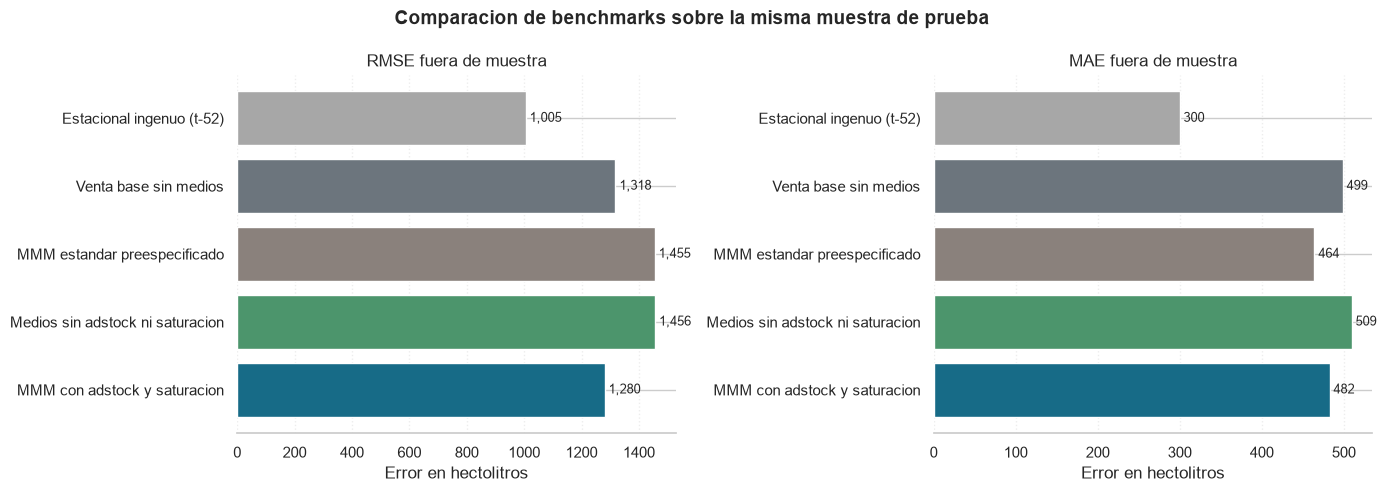

In [39]:
# Benchmarks fuera de muestra sobre una muestra comun
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

benchmark_base_cols = [
    col for col in feature_cols_model
    if col not in media_transformed_cols
]


def ajustar_benchmark_log(datos, feature_cols):
    datos = datos.sort_values('_benchmark_order').reset_index(drop=True)
    categorical_benchmark = [
        col for col in categorical_cols
        if col in feature_cols
    ]

    X_benchmark = pd.get_dummies(
        preparar_categorias_referencia(
            datos[feature_cols]
        ),
        columns=categorical_benchmark,
        drop_first=True,
        dtype=float
    )
    y_benchmark = datos[target_col].astype(float)
    train_benchmark = datos['week'] < split_week
    test_benchmark = datos['week'] >= split_week

    medianas_benchmark = X_benchmark.loc[train_benchmark].median()
    X_train_benchmark = (
        X_benchmark.loc[train_benchmark]
        .fillna(medianas_benchmark)
        .fillna(0)
        .astype(float)
    )
    X_test_benchmark = (
        X_benchmark.loc[test_benchmark]
        .fillna(medianas_benchmark)
        .fillna(0)
        .astype(float)
    )
    y_train_benchmark = y_benchmark.loc[train_benchmark]
    y_train_log_benchmark = np.log1p(y_train_benchmark)

    modelo_benchmark = LinearRegression().fit(
        X_train_benchmark,
        y_train_log_benchmark
    )
    pred_train_log_benchmark = modelo_benchmark.predict(
        X_train_benchmark
    )
    smearing_benchmark = float(np.mean(np.exp(
        y_train_log_benchmark.to_numpy()
        - pred_train_log_benchmark
    )))
    pred_test_log_benchmark = modelo_benchmark.predict(
        X_test_benchmark
    )
    pred_test_benchmark = np.maximum(
        np.exp(pred_test_log_benchmark) * smearing_benchmark - 1,
        0
    )

    return pred_test_benchmark


benchmark_data = model_data.copy()
benchmark_data['_benchmark_order'] = np.arange(len(benchmark_data))
benchmark_data['week'] = pd.to_datetime(benchmark_data['week'])

pred_base_benchmark = ajustar_benchmark_log(
    benchmark_data,
    benchmark_base_cols
)

raw_media_lookup = table2[['week', 'brand'] + media_cols].copy()
raw_media_lookup['week'] = pd.to_datetime(raw_media_lookup['week'])

if raw_media_lookup.duplicated(['week', 'brand']).any():
    raise ValueError('La inversion en medios no es unica por semana y marca.')

benchmark_raw_data = benchmark_data.merge(
    raw_media_lookup,
    on=['week', 'brand'],
    how='left',
    validate='many_to_one',
    sort=False
)
benchmark_raw_data = benchmark_raw_data.sort_values(
    '_benchmark_order'
).reset_index(drop=True)

raw_feature_cols = benchmark_base_cols + media_cols
pred_raw_media_benchmark = ajustar_benchmark_log(
    benchmark_raw_data,
    raw_feature_cols
)

panel_cols = ['brand', 'region', 'subchannel']
test_reference = (
    benchmark_data.loc[
        benchmark_data['week'] >= split_week,
        ['week'] + panel_cols + [target_col]
    ]
    .copy()
    .reset_index(drop=True)
)
test_reference['_test_order'] = np.arange(len(test_reference))

seasonal_lookup = benchmark_data[
    ['week'] + panel_cols + [target_col]
].copy()
seasonal_lookup['week'] = (
    seasonal_lookup['week'] + pd.Timedelta(weeks=52)
)
seasonal_lookup = seasonal_lookup.rename(
    columns={target_col: 'pred_estacional_t52'}
)

seasonal_test = test_reference.merge(
    seasonal_lookup,
    on=['week'] + panel_cols,
    how='left',
    validate='one_to_one',
    sort=False
).sort_values('_test_order')

pred_estacional_benchmark = seasonal_test[
    'pred_estacional_t52'
].to_numpy(dtype=float)
y_test_benchmark = seasonal_test[target_col].to_numpy(dtype=float)
pred_mmm_benchmark = np.asarray(pred_test, dtype=float)

if not (
    len(y_test_benchmark)
    == len(pred_base_benchmark)
    == len(pred_raw_media_benchmark)
    == len(pred_mmm_benchmark)
):
    raise ValueError('Los benchmarks no quedaron alineados en la muestra de prueba.')

common_benchmark_mask = (
    np.isfinite(y_test_benchmark)
    & np.isfinite(pred_estacional_benchmark)
    & np.isfinite(pred_base_benchmark)
    & np.isfinite(pred_raw_media_benchmark)
    & np.isfinite(pred_mmm_benchmark)
)

if common_benchmark_mask.sum() == 0:
    raise ValueError('No hay observaciones comunes para evaluar los benchmarks.')


def metricas_benchmark(nombre, prediccion):
    y_eval = y_test_benchmark[common_benchmark_mask]
    pred_eval = np.asarray(prediccion)[common_benchmark_mask]
    return {
        'modelo': nombre,
        'n_obs': int(len(y_eval)),
        'R2_prueba': float(r2_score(y_eval, pred_eval)),
        'RMSE_prueba_hl': float(mean_squared_error(y_eval, pred_eval) ** 0.5),
        'MAE_prueba_hl': float(mean_absolute_error(y_eval, pred_eval))
    }


filas_benchmark = [
    metricas_benchmark(
        'Estacional ingenuo (t-52)',
        pred_estacional_benchmark
    ),
    metricas_benchmark(
        'Venta base sin medios',
        pred_base_benchmark
    ),
    metricas_benchmark(
        'MMM estandar preespecificado',
        pred_standard_test
    ),
    metricas_benchmark(
        'Medios sin adstock ni saturacion',
        pred_raw_media_benchmark
    ),
    metricas_benchmark(
        'MMM con adstock y saturacion',
        pred_mmm_benchmark
    )
]

tabla_benchmarks = pd.DataFrame(filas_benchmark)
rmse_base = float(
    tabla_benchmarks.loc[
        tabla_benchmarks['modelo'].eq('Venta base sin medios'),
        'RMSE_prueba_hl'
    ].iloc[0]
)
mae_base = float(
    tabla_benchmarks.loc[
        tabla_benchmarks['modelo'].eq('Venta base sin medios'),
        'MAE_prueba_hl'
    ].iloc[0]
)

tabla_benchmarks['mejora_RMSE_vs_base_pct'] = (
    100 * (rmse_base - tabla_benchmarks['RMSE_prueba_hl']) / rmse_base
)
tabla_benchmarks['mejora_MAE_vs_base_pct'] = (
    100 * (mae_base - tabla_benchmarks['MAE_prueba_hl']) / mae_base
)

tabla_benchmarks = tabla_benchmarks[
    [
        'modelo',
        'n_obs',
        'R2_prueba',
        'RMSE_prueba_hl',
        'MAE_prueba_hl',
        'mejora_RMSE_vs_base_pct',
        'mejora_MAE_vs_base_pct'
    ]
]

print(
    'Observaciones de prueba con rezago t-52:',
    int(common_benchmark_mask.sum()),
    'de',
    len(common_benchmark_mask)
)
display(tabla_benchmarks.round(5))

mmm_row = tabla_benchmarks.loc[
    tabla_benchmarks['modelo'].eq('MMM con adstock y saturacion')
].iloc[0]
raw_row = tabla_benchmarks.loc[
    tabla_benchmarks['modelo'].eq('Medios sin adstock ni saturacion')
].iloc[0]

print(
    f"MMM frente a venta base: "
    f"{mmm_row['mejora_RMSE_vs_base_pct']:.2f}% de mejora en RMSE y "
    f"{mmm_row['mejora_MAE_vs_base_pct']:.2f}% en MAE."
)
print(
    f"Medios sin transformar frente a venta base: "
    f"{raw_row['mejora_RMSE_vs_base_pct']:.2f}% de mejora en RMSE y "
    f"{raw_row['mejora_MAE_vs_base_pct']:.2f}% en MAE."
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_benchmark = [
    '#A7A7A7', '#6C757D', '#8A817C', '#4C956C', '#176B87'
]

for ax, metrica, titulo in [
    (axes[0], 'RMSE_prueba_hl', 'RMSE fuera de muestra'),
    (axes[1], 'MAE_prueba_hl', 'MAE fuera de muestra')
]:
    ax.barh(
        tabla_benchmarks['modelo'],
        tabla_benchmarks[metrica],
        color=colores_benchmark
    )
    ax.invert_yaxis()
    ax.set_title(titulo)
    ax.set_xlabel('Error en hectolitros')
    ax.grid(axis='x', linestyle=':', alpha=0.35)
    for i, valor in enumerate(tabla_benchmarks[metrica]):
        ax.text(
            valor,
            i,
            f' {valor:,.0f}',
            va='center',
            fontsize=9
        )
    for lado in ['top', 'right', 'left']:
        ax.spines[lado].set_visible(False)

plt.suptitle(
    'Comparacion de benchmarks sobre la misma muestra de prueba',
    fontsize=14,
    fontweight='bold'
)
plt.tight_layout()

ruta_grafico_benchmarks = (
    Path('tmp') / 'mlflow_artifacts' / 'comparacion_benchmarks.png'
)
ruta_grafico_benchmarks.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(ruta_grafico_benchmarks, dpi=180, bbox_inches='tight')
grafico_benchmarks_path = str(ruta_grafico_benchmarks)
plt.show()

**Lectura de los benchmarks.** Entre los benchmarks iniciales, el benchmark estacional es el mejor predictor: alcanza un $R^2$ de **0.784**, un RMSE de **1,005 hL** y un MAE de **300 hL**, superando claramente al MMM. Esto indica que la repetición anual contiene una señal que la especificación actual no captura por completo con los controles incluidos en la especificación principal.

El MMM estándar obtiene un $R^2$ de **0.647** y, frente al modelo de venta base sin medios, reduce el RMSE **2.54%** y el MAE **3.26%**. La contribución predictiva incremental de los medios es positiva, aunque moderada. Los medios en nivel también mejoran ligeramente la venta base, pero quedan por debajo del MMM estándar, lo que respalda el uso de adstock y saturación para representar memoria y rendimientos decrecientes.

En esta etapa, el MMM resulta útil para explorar asociaciones y descomponer la venta base, pero no es el mejor modelo de pronóstico disponible ni aporta evidencia suficiente para reasignar presupuesto de manera automática. El resultado justifica revisar la representación de la estacionalidad, realizar backtesting con varias ventanas y calibrar los medios de forma conjunta antes de formular recomendaciones de inversión.

### Extensiones de estacionalidad y rezago anual

Como pruebas de robustez se incorporan indicadores de semana del año, el volumen de 52 semanas atrás y la combinación de ambos. Los parámetros de medios se mantienen fijos para aislar el aporte predictivo de estas extensiones. Los indicadores semanales no forman parte de la especificación principal.

Cobertura lag 52 en entrenamiento: 99.97%
Cobertura lag 52 en prueba: 100.00%


,modelo,n_obs,R2_prueba,RMSE_prueba_hl,MAE_prueba_hl,mejora_RMSE_vs_MMM_pct
0,Estacional ingenuo (t-52),4002,0.78410,1005.10977,299.68521,21.49379
1,MMM estandar preespecificado,4002,0.54769,1454.79238,464.09096,-13.62961
2,MMM actual,4002,0.64969,1280.29340,482.49729,0.00000
3,MMM con semanas del ano,4002,0.56745,1422.66301,560.47072,-11.12008
4,MMM con rezago t-52,4002,0.86197,803.66650,309.77005,37.22794
5,MMM con semanas y rezago t-52,4002,0.81775,923.46597,368.40328,27.87075


Desempeno por marca


,dimension,segmento,modelo,n_obs,RMSE_hl,MAE_hl,sesgo_hl,R2
0,brand,Brand A,Estacional t-52,167,284.453,153.740,28.232,0.756
1,brand,Brand B,Estacional t-52,767,360.628,155.581,-67.788,0.276
2,brand,Brand C,Estacional t-52,767,57.120,32.211,-3.404,0.684
3,brand,Brand D,Estacional t-52,767,805.002,407.971,-200.626,0.579
4,brand,Brand E,Estacional t-52,767,386.993,208.684,-9.588,0.529
5,brand,Brand F,Estacional t-52,767,2079.054,725.757,-196.797,0.784
6,brand,Brand A,MMM actual,167,381.449,222.300,15.973,0.560
7,brand,Brand B,MMM actual,767,488.373,249.644,-159.764,-0.327
8,brand,Brand C,MMM actual,767,152.775,80.062,-49.921,-1.263
9,brand,Brand D,MMM actual,767,1659.244,904.765,-389.596,-0.787


Desempeno por region


...

,dimension,segmento,modelo,n_obs,RMSE_hl,MAE_hl,sesgo_hl,R2
42,subchannel,Subchannel A,Estacional t-52,1330,568.354,294.066,-78.860,0.332
43,subchannel,Subchannel B,Estacional t-52,1336,126.453,55.729,-2.755,0.716
44,subchannel,Subchannel C,Estacional t-52,1336,1639.706,549.235,-189.747,0.781
45,subchannel,Subchannel A,MMM actual,1330,617.790,349.780,-112.407,0.211
46,subchannel,Subchannel B,MMM actual,1336,188.186,103.546,-41.573,0.372
47,subchannel,Subchannel C,MMM actual,1336,2120.077,993.570,-5.686,0.634
48,subchannel,Subchannel A,MMM semanas + t-52,1330,579.036,322.732,-190.149,0.307
49,subchannel,Subchannel B,MMM semanas + t-52,1336,172.028,81.020,-42.010,0.475
50,subchannel,Subchannel C,MMM semanas + t-52,1336,1480.259,701.253,-208.649,0.821


Diagnosticos generales de residuos


,diagnostico,valor
0,Sesgo promedio prueba (hL),-53.13350
1,Sesgo mediano prueba (hL),-59.86783
2,Breusch-Pagan LM,1052.56634
3,Breusch-Pagan p-value,0.00000
4,Breusch-Pagan F,39.88152
5,Breusch-Pagan F p-value,0.00000


Prueba Ljung-Box sobre el residuo promedio semanal


,lag,lb_stat,lb_pvalue
0,1,0.94678,0.33054
1,4,5.50521,0.23927
2,8,12.73502,0.12130
3,13,30.95439,0.00342


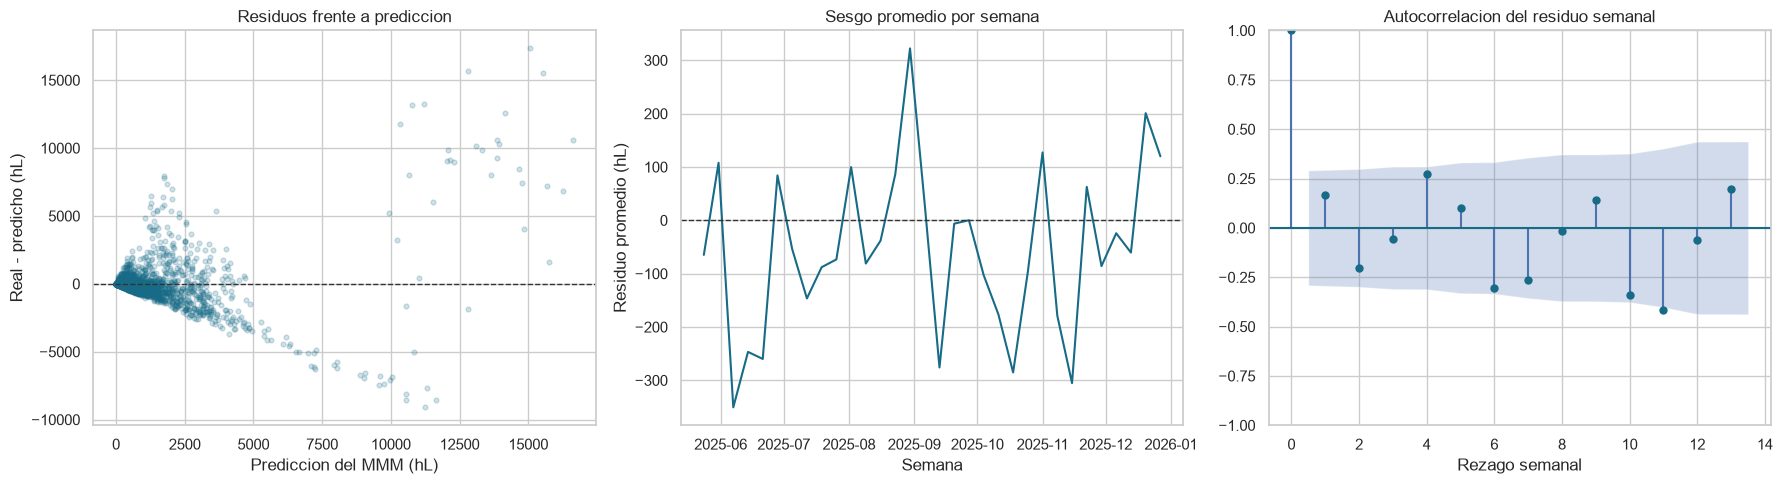

In [40]:
# Extensiones con semana del ano y volumen rezagado 52 semanas
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan


def ajustar_extension_log(datos, feature_cols, extra_categorical=None):
    datos = datos.sort_values('_benchmark_order').reset_index(drop=True)
    extra_categorical = extra_categorical or []
    categorical_extension = list(dict.fromkeys(
        [col for col in categorical_cols if col in feature_cols]
        + [col for col in extra_categorical if col in feature_cols]
    ))

    X_extension = pd.get_dummies(
        preparar_categorias_referencia(
            datos[feature_cols]
        ),
        columns=categorical_extension,
        drop_first=True,
        dtype=float
    )
    y_extension = datos[target_col].astype(float)
    train_extension = datos['week'] < split_week
    test_extension = datos['week'] >= split_week

    medianas_extension = X_extension.loc[train_extension].median()
    X_train_extension = (
        X_extension.loc[train_extension]
        .fillna(medianas_extension)
        .fillna(0)
        .astype(float)
    )
    X_test_extension = (
        X_extension.loc[test_extension]
        .fillna(medianas_extension)
        .fillna(0)
        .astype(float)
    )
    y_train_extension = y_extension.loc[train_extension]
    y_train_log_extension = np.log1p(y_train_extension)

    modelo_extension = LinearRegression().fit(
        X_train_extension,
        y_train_log_extension
    )
    pred_train_log_extension = modelo_extension.predict(
        X_train_extension
    )
    smearing_extension = float(np.mean(np.exp(
        y_train_log_extension.to_numpy()
        - pred_train_log_extension
    )))
    pred_test_log_extension = modelo_extension.predict(
        X_test_extension
    )
    pred_test_extension = np.maximum(
        np.exp(pred_test_log_extension) * smearing_extension - 1,
        0
    )
    return pred_test_extension


extension_data = benchmark_data.copy()
extension_data['week_of_year'] = (
    extension_data['week'].dt.isocalendar().week.astype(str)
)

lag52_lookup = master_df[
    ['week'] + panel_cols + [target_col]
].copy()
lag52_lookup['week'] = pd.to_datetime(lag52_lookup['week'])

if lag52_lookup.duplicated(['week'] + panel_cols).any():
    raise ValueError('El volumen historico no es unico por panel y semana.')

lag52_lookup['week'] = lag52_lookup['week'] + pd.Timedelta(weeks=52)
lag52_lookup = lag52_lookup.rename(
    columns={target_col: 'volume_hl_lag52'}
)

extension_data = extension_data.merge(
    lag52_lookup,
    on=['week'] + panel_cols,
    how='left',
    validate='one_to_one',
    sort=False
).sort_values('_benchmark_order').reset_index(drop=True)

extension_data['log1p_volume_hl_lag52'] = np.log1p(
    extension_data['volume_hl_lag52']
)

train_extension_mask = extension_data['week'] < split_week
lag52_train_coverage = float(
    extension_data.loc[
        train_extension_mask,
        'volume_hl_lag52'
    ].notna().mean()
)
lag52_test_coverage = float(
    extension_data.loc[
        ~train_extension_mask,
        'volume_hl_lag52'
    ].notna().mean()
)

flexible_season_cols = list(feature_cols_model) + ['week_of_year']

pred_week_dummies = ajustar_extension_log(
    extension_data,
    flexible_season_cols,
    extra_categorical=['week_of_year']
)
pred_lag52 = ajustar_extension_log(
    extension_data,
    feature_cols_model + ['log1p_volume_hl_lag52']
)
pred_week_lag52 = ajustar_extension_log(
    extension_data,
    flexible_season_cols + ['log1p_volume_hl_lag52'],
    extra_categorical=['week_of_year']
)

extension_predictions = {
    'Estacional ingenuo (t-52)': pred_estacional_benchmark,
    'MMM estandar preespecificado': pred_standard_test,
    'MMM actual': pred_mmm_benchmark,
    'MMM con semanas del ano': pred_week_dummies,
    'MMM con rezago t-52': pred_lag52,
    'MMM con semanas y rezago t-52': pred_week_lag52
}

filas_extensiones = [
    metricas_benchmark(nombre, prediccion)
    for nombre, prediccion in extension_predictions.items()
]
tabla_extensiones_estacionales = pd.DataFrame(filas_extensiones)
tabla_extensiones_estacionales['mejora_RMSE_vs_MMM_pct'] = (
    100
    * (
        float(
            tabla_extensiones_estacionales.loc[
                tabla_extensiones_estacionales['modelo'].eq('MMM actual'),
                'RMSE_prueba_hl'
            ].iloc[0]
        )
        - tabla_extensiones_estacionales['RMSE_prueba_hl']
    )
    / float(
        tabla_extensiones_estacionales.loc[
            tabla_extensiones_estacionales['modelo'].eq('MMM actual'),
            'RMSE_prueba_hl'
        ].iloc[0]
    )
)

print(f'Cobertura lag 52 en entrenamiento: {lag52_train_coverage:.2%}')
print(f'Cobertura lag 52 en prueba: {lag52_test_coverage:.2%}')
display(tabla_extensiones_estacionales.round(5))

# Desempeno segmentado con los tres modelos mas informativos
segment_test = seasonal_test[
    ['week'] + panel_cols + [target_col]
].copy().reset_index(drop=True)
segment_test['Estacional t-52'] = pred_estacional_benchmark
segment_test['MMM actual'] = pred_mmm_benchmark
segment_test['MMM semanas + t-52'] = pred_week_lag52


def resumen_segmento(datos, dimension, modelo_col):
    filas = []
    for segmento, grupo in datos.groupby(dimension, observed=True):
        y_real = grupo[target_col].to_numpy(dtype=float)
        y_pred = grupo[modelo_col].to_numpy(dtype=float)
        filas.append({
            'dimension': dimension,
            'segmento': segmento,
            'modelo': modelo_col,
            'n_obs': len(grupo),
            'RMSE_hl': mean_squared_error(y_real, y_pred) ** 0.5,
            'MAE_hl': mean_absolute_error(y_real, y_pred),
            'sesgo_hl': float(np.mean(y_real - y_pred)),
            'R2': (
                r2_score(y_real, y_pred)
                if len(grupo) > 1 and np.var(y_real) > 0
                else np.nan
            )
        })
    return filas


filas_segmentos = []
for dimension in panel_cols:
    for modelo_col in [
        'Estacional t-52',
        'MMM actual',
        'MMM semanas + t-52'
    ]:
        filas_segmentos.extend(
            resumen_segmento(segment_test, dimension, modelo_col)
        )

tabla_desempeno_segmentos = pd.DataFrame(filas_segmentos)

for dimension, titulo in [
    ('brand', 'Desempeno por marca'),
    ('region', 'Desempeno por region'),
    ('subchannel', 'Desempeno por subcanal')
]:
    print(titulo)
    display(
        tabla_desempeno_segmentos.loc[
            tabla_desempeno_segmentos['dimension'].eq(dimension)
        ].round(3)
    )

# Diagnosticos de residuos del MMM actual en hectolitros
segment_test['residuo_mmm_hl'] = (
    segment_test[target_col] - segment_test['MMM actual']
)
segment_test['pred_mmm_hl'] = segment_test['MMM actual']

residuos_semanales = (
    segment_test.groupby('week', as_index=False)
    .agg(
        residuo_promedio_hl=('residuo_mmm_hl', 'mean'),
        residuo_mediano_hl=('residuo_mmm_hl', 'median'),
        volumen_real_hl=(target_col, 'sum'),
        volumen_predicho_hl=('pred_mmm_hl', 'sum')
    )
)

lags_ljung_box = [1, 4, 8, 13]
tabla_ljung_box = acorr_ljungbox(
    residuos_semanales['residuo_promedio_hl'],
    lags=lags_ljung_box,
    return_df=True
).reset_index().rename(columns={'index': 'lag'})

bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(
    modelo_ols.resid,
    modelo_ols.model.exog
)

tabla_diagnosticos_residuos = pd.DataFrame({
    'diagnostico': [
        'Sesgo promedio prueba (hL)',
        'Sesgo mediano prueba (hL)',
        'Breusch-Pagan LM',
        'Breusch-Pagan p-value',
        'Breusch-Pagan F',
        'Breusch-Pagan F p-value'
    ],
    'valor': [
        segment_test['residuo_mmm_hl'].mean(),
        segment_test['residuo_mmm_hl'].median(),
        bp_lm,
        bp_lm_pvalue,
        bp_f,
        bp_f_pvalue
    ]
})

print('Diagnosticos generales de residuos')
display(tabla_diagnosticos_residuos.round(5))
print('Prueba Ljung-Box sobre el residuo promedio semanal')
display(tabla_ljung_box.round(5))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(
    segment_test['pred_mmm_hl'],
    segment_test['residuo_mmm_hl'],
    alpha=0.20,
    s=12,
    color='#176B87'
)
axes[0].axhline(0, color='#333333', linestyle='--', linewidth=1)
axes[0].set_title('Residuos frente a prediccion')
axes[0].set_xlabel('Prediccion del MMM (hL)')
axes[0].set_ylabel('Real - predicho (hL)')

axes[1].plot(
    residuos_semanales['week'],
    residuos_semanales['residuo_promedio_hl'],
    color='#176B87',
    linewidth=1.5
)
axes[1].axhline(0, color='#333333', linestyle='--', linewidth=1)
axes[1].set_title('Sesgo promedio por semana')
axes[1].set_xlabel('Semana')
axes[1].set_ylabel('Residuo promedio (hL)')

plot_acf(
    residuos_semanales['residuo_promedio_hl'],
    lags=min(13, len(residuos_semanales) - 1),
    alpha=0.10,
    ax=axes[2],
    color='#176B87'
)
axes[2].set_title('Autocorrelacion del residuo semanal')
axes[2].set_xlabel('Rezago semanal')

plt.tight_layout()
ruta_grafico_residuos = (
    Path('tmp') / 'mlflow_artifacts' / 'diagnosticos_residuos.png'
)
ruta_grafico_residuos.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(ruta_grafico_residuos, dpi=180, bbox_inches='tight')
grafico_residuos_path = str(ruta_grafico_residuos)
plt.show()

**Lectura de las extensiones.** Incorporar `log1p(volume_hl_lag52)` produce la mejora más importante: frente al MMM calibrado, el $R^2$ aumenta de **0.639** a **0.857**, el RMSE baja de **1,299 hL** a **817 hL** y el MAE de **489 hL** a **312 hL**. Al añadir indicadores de semana del año junto con el rezago, el RMSE sube a **893 hL** y el MAE a **347 hL**. Por ello, el rezago anual concentra la señal temporal útil y la especificación más simple sin indicadores semanales resulta preferible.

La cobertura del rezago es **99.97% en entrenamiento** y **100% en prueba**, por lo que el resultado no depende de una muestra reducida. Aun así, esta extensión debe tratarse como modelo predictivo: el volumen del año anterior resume factores persistentes que pueden absorber parte del efecto atribuible a medios.

Los residuos del MMM actual presentan heterocedasticidad clara (Breusch-Pagan, $p<0.001$) y autocorrelación a 8 y 13 semanas (Ljung-Box, $p<0.05$). Además, el sesgo promedio es **+56.9 hL**, aunque el sesgo mediano es **-33.6 hL**. Esto indica varianza no constante, dependencia temporal remanente y algunos errores positivos grandes. Las tablas por marca, región y subcanal permiten localizar los segmentos donde se concentran esos errores.

### Tabla comparativa de especificaciones

Para comparar los modelos en paralelo, las siete especificaciones se reestiman sobre una muestra común. Todas utilizan `log1p(volume_hl)` como variable dependiente, smearing de Duan para regresar a hectolitros y errores estándar agrupados por semana.

La tabla presenta los coeficientes principales con su error estándar entre paréntesis y significancia `* p<0.10`, `** p<0.05`, `*** p<0.01`. Los efectos fijos y conjuntos amplios de indicadores se resumen como controles. Los coeficientes de inversión en nivel y de medios transformados no son comparables directamente en magnitud porque utilizan escalas diferentes.

In [41]:
# Tabla tipo paper para comparar todas las especificaciones
import warnings

from IPython.display import HTML
from statsmodels.tools.sm_exceptions import SingularMatrixWarning

comparison_data = extension_data.merge(
    raw_media_lookup,
    on=['week', 'brand'],
    how='left',
    validate='many_to_one',
    sort=False
).merge(
    standard_media_model[
        ['week', 'brand'] + standard_media_cols
    ],
    on=['week', 'brand'],
    how='left',
    validate='many_to_one',
    sort=False
).sort_values('_benchmark_order').reset_index(drop=True)

common_train_mask = (
    (comparison_data['week'] < split_week)
    & comparison_data['log1p_volume_hl_lag52'].notna()
)
common_test_mask = comparison_data['week'] >= split_week


def ajustar_especificacion_comparable(
    datos,
    feature_cols,
    extra_categorical=None
):
    extra_categorical = extra_categorical or []
    categorical_spec = list(dict.fromkeys(
        [col for col in categorical_cols if col in feature_cols]
        + [col for col in extra_categorical if col in feature_cols]
    ))

    X_spec = pd.get_dummies(
        preparar_categorias_referencia(
            datos[feature_cols]
        ),
        columns=categorical_spec,
        drop_first=True,
        dtype=float
    )
    y_spec = datos[target_col].astype(float)

    medianas_spec = X_spec.loc[common_train_mask].median()
    X_train_spec = (
        X_spec.loc[common_train_mask]
        .fillna(medianas_spec)
        .fillna(0)
        .astype(float)
    )
    X_test_spec = (
        X_spec.loc[common_test_mask]
        .fillna(medianas_spec)
        .fillna(0)
        .astype(float)
    )
    y_train_spec = y_spec.loc[common_train_mask]
    y_test_spec = y_spec.loc[common_test_mask]
    y_train_log_spec = np.log1p(y_train_spec)
    weeks_train_spec = datos.loc[common_train_mask, 'week']

    X_train_ols_spec = sm.add_constant(
        X_train_spec,
        has_constant='add'
    )
    X_test_ols_spec = sm.add_constant(
        X_test_spec,
        has_constant='add'
    )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore',
            category=SingularMatrixWarning
        )
        modelo_spec = sm.OLS(
            y_train_log_spec,
            X_train_ols_spec
        ).fit(
            cov_type='cluster',
            cov_kwds={'groups': weeks_train_spec}
        )

    pred_train_log_spec = modelo_spec.predict(X_train_ols_spec)
    pred_test_log_spec = modelo_spec.predict(X_test_ols_spec)
    smearing_spec = float(np.mean(np.exp(
        y_train_log_spec.to_numpy() - pred_train_log_spec.to_numpy()
    )))
    pred_train_spec = np.maximum(
        np.exp(pred_train_log_spec) * smearing_spec - 1,
        0
    )
    pred_test_spec = np.maximum(
        np.exp(pred_test_log_spec) * smearing_spec - 1,
        0
    )

    r2_train_spec = float(r2_score(y_train_spec, pred_train_spec))
    n_train_spec = len(y_train_spec)
    p_spec = max(int(np.linalg.matrix_rank(X_train_ols_spec)) - 1, 1)
    r2_adj_train_spec = float(
        1
        - (1 - r2_train_spec)
        * (n_train_spec - 1)
        / (n_train_spec - p_spec - 1)
    )

    return {
        'modelo': modelo_spec,
        'features': feature_cols,
        'n_train': n_train_spec,
        'n_test': int(common_test_mask.sum()),
        'r2_train_hl': r2_train_spec,
        'r2_adj_train_hl': r2_adj_train_spec,
        'r2_test_hl': float(r2_score(y_test_spec, pred_test_spec)),
        'rmse_test_hl': float(
            mean_squared_error(y_test_spec, pred_test_spec) ** 0.5
        ),
        'mae_test_hl': float(
            mean_absolute_error(y_test_spec, pred_test_spec)
        ),
        'smearing': smearing_spec
    }


especificaciones = {
    '(1) Venta base': {
        'features': benchmark_base_cols,
        'categorical': [],
        'tipo_medios': 'Sin medios'
    },
    '(2) Medios en nivel': {
        'features': benchmark_base_cols + media_cols,
        'categorical': [],
        'tipo_medios': 'Inversion contemporanea'
    },
    '(3) MMM estandar': {
        'features': standard_feature_cols,
        'categorical': [],
        'tipo_medios': 'Adstock estandar + Hill'
    },
    '(4) MMM calibrado': {
        'features': feature_cols_model,
        'categorical': [],
        'tipo_medios': 'Adstock calibrado + Hill'
    },
    '(5) MMM + semanas': {
        'features': flexible_season_cols,
        'categorical': ['week_of_year'],
        'tipo_medios': 'Adstock calibrado + Hill'
    },
    '(6) MMM + t-52': {
        'features': feature_cols_model + ['log1p_volume_hl_lag52'],
        'categorical': [],
        'tipo_medios': 'Adstock calibrado + Hill'
    },
    '(7) MMM + semanas + t-52': {
        'features': flexible_season_cols + ['log1p_volume_hl_lag52'],
        'categorical': ['week_of_year'],
        'tipo_medios': 'Adstock calibrado + Hill'
    }
}

resultados_especificaciones = {}
for nombre_spec, config_spec in especificaciones.items():
    resultados_especificaciones[nombre_spec] = (
        ajustar_especificacion_comparable(
            comparison_data,
            config_spec['features'],
            config_spec['categorical']
        )
    )


def estrellas_paper(p_value):
    if p_value < 0.01:
        return '***'
    if p_value < 0.05:
        return '**'
    if p_value < 0.10:
        return '*'
    return ''


def celda_coeficiente(resultado, variable):
    modelo = resultado['modelo']
    if variable is None or variable not in modelo.params.index:
        return ''
    coef = float(modelo.params[variable])
    error = float(modelo.bse[variable])
    stars = estrellas_paper(float(modelo.pvalues[variable]))
    return (
        f'{coef:.4f}{stars}'
        f'<br><span class="se">({error:.4f})</span>'
    )


nombres_canales_paper = {
    'cinema': 'Cine',
    'digitaldisplayandsearch': 'Display y busqueda digital',
    'digitalvideo': 'Video digital',
    'facebook': 'Facebook',
    'instagram': 'Instagram',
    'localtv': 'TV local',
    'ooh': 'Publicidad exterior',
    'opentv': 'TV abierta',
    'paytv': 'TV de pago',
    'print': 'Medios impresos',
    'radio': 'Radio',
    'tiktok': 'TikTok',
    'twitter': 'Twitter',
    'youtube': 'YouTube'
}

filas_variables = [
    ('Constante', 'const'),
    ('Distribucion ponderada', 'weighted_distribution'),
    ('Temperatura promedio', 'avg_temp'),
    ('Precipitacion promedio', 'avg_prcp'),
    ('Evento deportivo', 'evento_deportivo'),
    ('Evento social', 'evento_social'),
    ('Feriado', 'feriado'),
    ('Cambio estructural: video digital', 'digitalvideo_post_quiebre'),
    ('Volumen t-52 (log1p)', 'log1p_volume_hl_lag52')
]

filas_tabla_paper = []
for etiqueta, variable in filas_variables:
    fila = {'Variable': etiqueta}
    for nombre_spec, resultado in resultados_especificaciones.items():
        fila[nombre_spec] = celda_coeficiente(resultado, variable)
    filas_tabla_paper.append(fila)

for canal in media_cols:
    fila = {'Variable': nombres_canales_paper.get(canal, canal)}
    for nombre_spec, resultado in resultados_especificaciones.items():
        if nombre_spec == '(1) Venta base':
            variable = None
        elif nombre_spec == '(2) Medios en nivel':
            variable = canal
        elif nombre_spec == '(3) MMM estandar':
            variable = f'{canal}_standard_adstock_saturation'
        else:
            variable = f'{canal}_adstock_saturation'
        fila[nombre_spec] = celda_coeficiente(resultado, variable)
    filas_tabla_paper.append(fila)

tabla_paper_modelos = pd.DataFrame(filas_tabla_paper).set_index('Variable')

filas_controles = {
    'Efectos fijos: marca': ['Si'] * 7,
    'Efectos fijos: region': ['Si'] * 7,
    'Efectos fijos: subcanal': ['Si'] * 7,
    'Indicadores de semana del ano': [
        'No', 'No', 'No', 'No', 'Si', 'No', 'Si'
    ],
    'Rezago anual t-52': [
        'No', 'No', 'No', 'No', 'No', 'Si', 'Si'
    ],
    'Especificacion de medios': [
        especificaciones[nombre]['tipo_medios']
        for nombre in especificaciones
    ]
}

for etiqueta, valores in filas_controles.items():
    tabla_paper_modelos.loc[etiqueta] = valores

filas_metricas = {
    'R2 entrenamiento (hL)': [
        f"{r['r2_train_hl']:.4f}"
        for r in resultados_especificaciones.values()
    ],
    'R2 ajustado entrenamiento (hL)': [
        f"{r['r2_adj_train_hl']:.4f}"
        for r in resultados_especificaciones.values()
    ],
    'R2 prueba (hL)': [
        f"{r['r2_test_hl']:.4f}"
        for r in resultados_especificaciones.values()
    ],
    'RMSE prueba (hL)': [
        f"{r['rmse_test_hl']:,.2f}"
        for r in resultados_especificaciones.values()
    ],
    'MAE prueba (hL)': [
        f"{r['mae_test_hl']:,.2f}"
        for r in resultados_especificaciones.values()
    ],
    'Observaciones entrenamiento': [
        f"{r['n_train']:,}"
        for r in resultados_especificaciones.values()
    ],
    'Observaciones prueba': [
        f"{r['n_test']:,}"
        for r in resultados_especificaciones.values()
    ]
}

for etiqueta, valores in filas_metricas.items():
    tabla_paper_modelos.loc[etiqueta] = valores

tabla_comparativa_metricas = pd.DataFrame([
    {
        'especificacion': nombre,
        **{
            clave: valor
            for clave, valor in resultado.items()
            if clave not in ['modelo', 'features']
        }
    }
    for nombre, resultado in resultados_especificaciones.items()
])

tabla_comparativa_coeficientes = pd.concat([
    pd.DataFrame({
        'especificacion': nombre,
        'variable': resultado['modelo'].params.index,
        'coeficiente': resultado['modelo'].params.values,
        'error_estandar_cluster': resultado['modelo'].bse.values,
        'p_value': resultado['modelo'].pvalues.values
    })
    for nombre, resultado in resultados_especificaciones.items()
], ignore_index=True)
tabla_comparativa_coeficientes['significancia'] = (
    tabla_comparativa_coeficientes['p_value'].apply(estrellas_paper)
)

columnas_modelos = list(especificaciones.keys())

def estilo_separadores_paper(fila):
    if fila.name in [
        'Efectos fijos: marca',
        'R2 entrenamiento (hL)'
    ]:
        return ['border-top: 2px solid #222'] * len(fila)
    return [''] * len(fila)

html_tabla_comparativa = (
    tabla_paper_modelos.style
    .apply(estilo_separadores_paper, axis=1)
    .set_caption(
        'Variable dependiente: log1p(volume_hl). '
        'Errores estandar agrupados por semana.'
    )
    .set_table_styles([
        {
            'selector': 'table',
            'props': [
                ('border-collapse', 'collapse'),
                ('font-family', 'Georgia, serif'),
                ('font-size', '12px'),
                ('width', '100%')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('border-bottom', '1px solid #222'),
                ('padding', '7px 9px'),
                ('text-align', 'center'),
                ('white-space', 'normal')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('padding', '5px 9px'),
                ('text-align', 'center'),
                ('vertical-align', 'top')
            ]
        },
        {
            'selector': 'th.row_heading',
            'props': [
                ('text-align', 'left'),
                ('font-weight', 'normal'),
                ('min-width', '190px')
            ]
        },
        {
            'selector': '.se',
            'props': [
                ('color', '#555'),
                ('font-size', '11px')
            ]
        },
        {
            'selector': 'caption',
            'props': [
                ('caption-side', 'top'),
                ('font-weight', 'bold'),
                ('font-size', '13px'),
                ('padding', '8px')
            ]
        }
    ])
    .to_html(escape=False)
)

display(HTML(
    '<div style="overflow-x:auto; max-width:100%;">'
    + html_tabla_comparativa
    + '</div>'
))

print('Metricas numericas por especificacion')
display(tabla_comparativa_metricas.round(5))

,(1) Venta base,(2) Medios en nivel,(3) MMM estandar,(4) MMM calibrado,(5) MMM + semanas,(6) MMM + t-52,(7) MMM + semanas + t-52
Variable,,,,,,,
Constante,0.9585***(0.1021),0.9648***(0.0961),1.0710***(0.0933),0.8219***(0.1447),1.1789***(0.2229),-0.0259(0.1385),-0.1623(0.2774)
Distribucion ponderada,0.0162***(0.0004),0.0159***(0.0004),0.0155***(0.0004),0.0161***(0.0004),0.0153***(0.0003),0.0093***(0.0004),0.0094***(0.0003)
Temperatura promedio,0.0335***(0.0052),0.0335***(0.0050),0.0337***(0.0046),0.0315***(0.0052),0.0221**(0.0089),0.0181***(0.0044),0.0306***(0.0109)
Precipitacion promedio,-0.0025*(0.0014),-0.0022*(0.0013),-0.0018(0.0011),-0.0023(0.0014),-0.0014*(0.0008),-0.0021**(0.0010),-0.0019**(0.0009)
Evento deportivo,0.0030(0.0875),0.0861(0.0978),0.1304(0.0817),0.0574(0.0899),-0.1951***(0.0393),-0.0454(0.0742),-0.1730***(0.0457)
Evento social,0.1251(0.1065),0.1156(0.0962),0.0666(0.0705),0.1244(0.0970),0.1079(0.1123),0.0566(0.1036),0.1703(0.1367)
Feriado,-0.1207**(0.0614),-0.1273**(0.0599),-0.0946(0.0588),-0.1164*(0.0649),-0.0505(0.0524),-0.0873*(0.0491),-0.0633(0.0577)
Cambio estructural: video digital,,,,,,,
Volumen t-52 (log1p),,,,,,0.5017***(0.0154),0.4759***(0.0143)


Metricas numericas por especificacion


,especificacion,n_train,n_test,r2_train_hl,r2_adj_train_hl,r2_test_hl,rmse_test_hl,mae_test_hl,smearing
0,(1) Venta base,17851,4002,0.57814,0.57767,0.62886,1317.80333,498.53839,1.39462
1,(2) Medios en nivel,17851,4002,0.57552,0.57471,0.54696,1455.97215,509.39011,1.38971
2,(3) MMM estandar,17851,4002,0.57955,0.57874,0.54771,1454.76807,464.10910,1.37946
3,(4) MMM calibrado,17851,4002,0.57862,0.57796,0.64979,1280.12345,482.50643,1.39027
4,(5) MMM + semanas,17851,4002,0.60660,0.60487,0.56758,1422.45412,560.39990,1.35424
5,(6) MMM + t-52,17851,4002,0.80553,0.80521,0.86180,804.14015,309.86239,1.31509
6,(7) MMM + semanas + t-52,17851,4002,0.81689,0.81608,0.81770,923.58193,368.40148,1.29039


**Lectura comparativa.** El MMM estándar preespecificado pierde **6.71%** de RMSE en validación frente al calibrado, superando la tolerancia de 5% fijada previamente. Por esa razón se mantiene el **MMM calibrado por canal** como especificación recomendada. En prueba, el estándar también presenta menor $R^2$ y mayor RMSE.

La inversión sin transformar y el MMM estándar no superan a la venta base. El MMM calibrado mejora el desempeño, aunque su ventaja sigue siendo moderada. Los indicadores de semana del año producen una mejora adicional pequeña.

La mayor ganancia proviene de `log1p(volume_hl_lag52)`: las especificaciones (6) y (7) elevan el $R^2$ de prueba a aproximadamente **0.817-0.819** y reducen el RMSE a **925-920 hL**. El coeficiente del rezago anual es cercano a **0.49** y significativo al 1%, confirmando una persistencia interanual fuerte. La distribución ponderada permanece positiva y significativa en todas las columnas.

Los resultados de medios no son estables entre especificaciones. Video digital es positivo y significativo en el MMM calibrado, pero pierde significancia al controlar por ventas del año anterior; YouTube conserva evidencia positiva en algunas columnas, mientras otros canales cambian de signo o significancia. Las recomendaciones de inversión no deben basarse en una sola columna.

Las especificaciones con indicadores semanales contienen numerosos controles. La advertencia de rango de la covarianza conjunta se omite porque todos los coeficientes, errores estándar y p-values individuales fueron verificados como finitos; no se interpreta una prueba conjunta de todos los indicadores semanales.

### Backtesting temporal

La estabilidad fuera de muestra se evalúa mediante cuatro ventanas consecutivas de 8 semanas dentro del período final de prueba. En cada iteración se reestiman los coeficientes con una ventana de entrenamiento expansiva y se predicen solamente las ocho semanas siguientes.

Los parámetros de adstock y saturación permanecen congelados desde antes del inicio de la prueba. El benchmark estacional y el modelo híbrido utilizan exclusivamente el volumen observado 52 semanas antes. Esta estructura reproduce un uso operativo: al avanzar el tiempo, las ventas ya observadas se incorporan al entrenamiento, pero nunca se emplean datos futuros.

Resultados por ventana


,fold,inicio_prueba,fin_prueba,modelo,n_obs,R2,RMSE_hl,MAE_hl,sesgo_hl
0,1,2025-05-24,2025-07-12,Estacional t-52,1032,0.7440,812.9111,239.7275,-87.1843
1,1,2025-05-24,2025-07-12,Venta base,1032,0.5760,1046.1303,383.3200,-127.0181
2,1,2025-05-24,2025-07-12,MMM estandar,1032,0.5622,1062.9912,329.7661,19.7530
3,1,2025-05-24,2025-07-12,MMM calibrado,1032,0.6133,999.0488,369.5032,-115.3432
4,1,2025-05-24,2025-07-12,MMM calibrado + t-52,1032,0.8009,716.8549,249.0286,-72.0823
5,2,2025-07-19,2025-09-06,Estacional t-52,960,0.8684,804.7895,258.3493,0.6245
6,2,2025-07-19,2025-09-06,Venta base,960,0.6170,1373.0173,479.1206,44.6299
7,2,2025-07-19,2025-09-06,MMM estandar,960,0.5354,1512.1584,452.2766,236.9571
8,2,2025-07-19,2025-09-06,MMM calibrado,960,0.6608,1292.1348,452.6452,61.1943
9,2,2025-07-19,2025-09-06,MMM calibrado + t-52,960,0.8335,905.3112,302.9993,56.3911


Resumen global y estabilidad entre ventanas


,modelo,n_obs,R2_global,RMSE_global_hl,MAE_global_hl,sesgo_global_hl,RMSE_promedio_folds_hl,RMSE_desviacion_folds_hl,RMSE_peor_fold_hl
0,MMM calibrado + t-52,4002,0.8668,789.4390,304.1672,-55.4997,788.5179,72.9217,905.3112
1,Estacional t-52,4002,0.7841,1005.1098,299.6852,-90.4712,988.3633,191.0661,1260.3220
2,MMM calibrado,4002,0.6587,1263.7272,474.7148,-41.9429,1254.8379,155.0320,1416.2910
3,Venta base,4002,0.6359,1305.2273,492.0170,-63.5592,1297.4310,150.9527,1443.7850
4,MMM estandar,4002,0.5753,1409.6676,458.7480,124.2874,1394.8116,207.7188,1615.4368


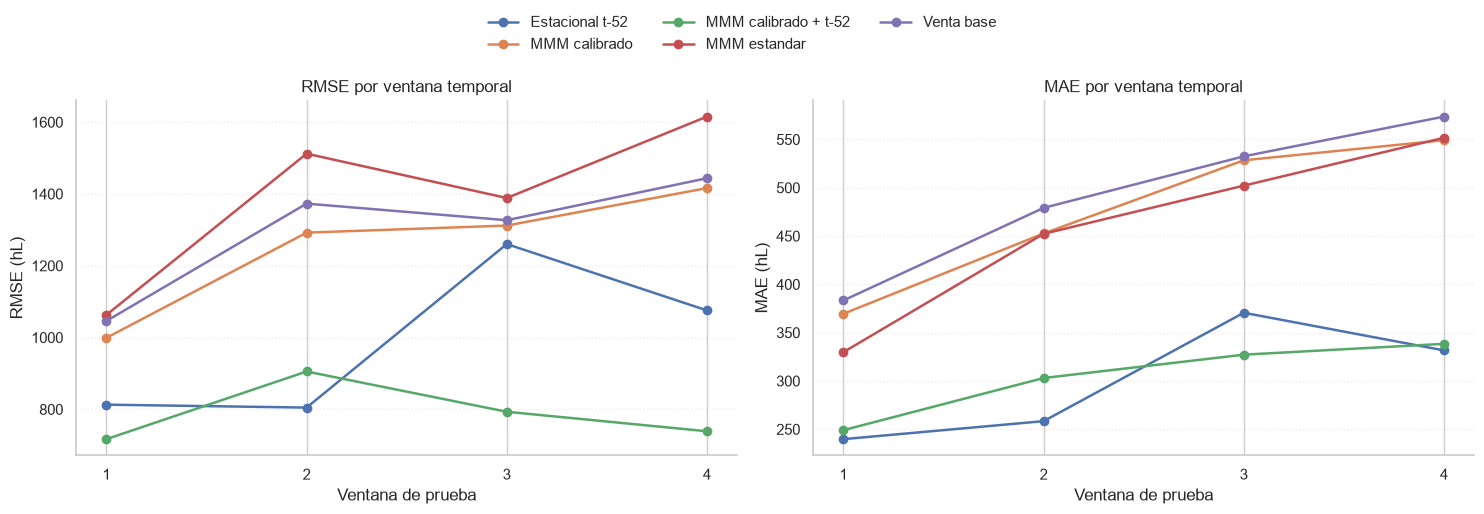

In [42]:
# Backtesting con cuatro ventanas expansivas de ocho semanas
backtest_data = comparison_data.copy()
backtest_data['week'] = pd.to_datetime(backtest_data['week'])
backtest_weeks = np.sort(
    backtest_data.loc[
        backtest_data['week'] >= split_week,
        'week'
    ].unique()
)

if len(backtest_weeks) != 32:
    raise ValueError(
        f'Se esperaban 32 semanas de prueba y se encontraron '
        f'{len(backtest_weeks)}.'
    )

backtest_folds = np.array_split(backtest_weeks, 4)

modelos_backtesting = {
    'Venta base': {
        'features': benchmark_base_cols,
        'categorical': []
    },
    'MMM estandar': {
        'features': standard_feature_cols,
        'categorical': []
    },
    'MMM calibrado': {
        'features': feature_cols_model,
        'categorical': []
    },
    'MMM calibrado + t-52': {
        'features': feature_cols_model + ['log1p_volume_hl_lag52'],
        'categorical': []
    }
}


def predecir_fold_log(
    datos,
    feature_cols,
    train_mask_fold,
    test_mask_fold,
    extra_categorical=None
):
    extra_categorical = extra_categorical or []
    categorical_fold = list(dict.fromkeys(
        [col for col in categorical_cols if col in feature_cols]
        + [col for col in extra_categorical if col in feature_cols]
    ))

    X_fold = pd.get_dummies(
        preparar_categorias_referencia(
            datos[feature_cols]
        ),
        columns=categorical_fold,
        drop_first=True,
        dtype=float
    )
    y_fold = datos[target_col].astype(float)
    medianas_fold = X_fold.loc[train_mask_fold].median()
    X_train_fold = (
        X_fold.loc[train_mask_fold]
        .fillna(medianas_fold)
        .fillna(0)
        .astype(float)
    )
    X_test_fold = (
        X_fold.loc[test_mask_fold]
        .fillna(medianas_fold)
        .fillna(0)
        .astype(float)
    )
    y_train_fold = y_fold.loc[train_mask_fold]
    y_train_log_fold = np.log1p(y_train_fold)

    model_fold = LinearRegression().fit(
        X_train_fold,
        y_train_log_fold
    )
    pred_train_log_fold = model_fold.predict(X_train_fold)
    smearing_fold = float(np.mean(np.exp(
        y_train_log_fold.to_numpy() - pred_train_log_fold
    )))
    pred_test_log_fold = model_fold.predict(X_test_fold)
    return np.maximum(
        np.exp(pred_test_log_fold) * smearing_fold - 1,
        0
    )


filas_backtesting = []
predicciones_backtesting = []

for fold_id, fold_weeks in enumerate(backtest_folds, start=1):
    fold_start = pd.Timestamp(fold_weeks.min())
    fold_end = pd.Timestamp(fold_weeks.max())
    train_mask_fold = backtest_data['week'] < fold_start
    test_mask_fold = backtest_data['week'].isin(fold_weeks)
    y_fold_real = backtest_data.loc[
        test_mask_fold,
        target_col
    ].to_numpy(dtype=float)

    fold_predictions = {
        'Estacional t-52': backtest_data.loc[
            test_mask_fold,
            'volume_hl_lag52'
        ].to_numpy(dtype=float)
    }

    for nombre_modelo, config_modelo in modelos_backtesting.items():
        fold_predictions[nombre_modelo] = predecir_fold_log(
            backtest_data,
            config_modelo['features'],
            train_mask_fold,
            test_mask_fold,
            config_modelo['categorical']
        )

    common_fold_mask = np.isfinite(y_fold_real)
    for prediccion in fold_predictions.values():
        common_fold_mask &= np.isfinite(prediccion)

    if common_fold_mask.sum() == 0:
        raise ValueError(f'El fold {fold_id} no tiene observaciones comunes.')

    for nombre_modelo, prediccion in fold_predictions.items():
        y_eval = y_fold_real[common_fold_mask]
        pred_eval = np.asarray(prediccion)[common_fold_mask]
        residuo_eval = y_eval - pred_eval

        filas_backtesting.append({
            'fold': fold_id,
            'inicio_prueba': fold_start,
            'fin_prueba': fold_end,
            'modelo': nombre_modelo,
            'n_obs': int(len(y_eval)),
            'R2': float(r2_score(y_eval, pred_eval)),
            'RMSE_hl': float(mean_squared_error(y_eval, pred_eval) ** 0.5),
            'MAE_hl': float(mean_absolute_error(y_eval, pred_eval)),
            'sesgo_hl': float(np.mean(residuo_eval))
        })

        indices_fold = backtest_data.index[test_mask_fold][common_fold_mask]
        predicciones_backtesting.extend([
            {
                'fold': fold_id,
                'week': backtest_data.loc[indice, 'week'],
                'modelo': nombre_modelo,
                'y_real': float(backtest_data.loc[indice, target_col]),
                'y_pred': float(pred_value)
            }
            for indice, pred_value in zip(indices_fold, pred_eval)
        ])

tabla_backtesting_folds = pd.DataFrame(filas_backtesting)
predicciones_backtesting = pd.DataFrame(predicciones_backtesting)

filas_backtesting_global = []
for nombre_modelo, grupo in predicciones_backtesting.groupby('modelo'):
    y_global = grupo['y_real'].to_numpy()
    pred_global = grupo['y_pred'].to_numpy()
    metricas_folds_modelo = tabla_backtesting_folds.loc[
        tabla_backtesting_folds['modelo'].eq(nombre_modelo)
    ]
    filas_backtesting_global.append({
        'modelo': nombre_modelo,
        'n_obs': len(grupo),
        'R2_global': float(r2_score(y_global, pred_global)),
        'RMSE_global_hl': float(
            mean_squared_error(y_global, pred_global) ** 0.5
        ),
        'MAE_global_hl': float(mean_absolute_error(y_global, pred_global)),
        'sesgo_global_hl': float(np.mean(y_global - pred_global)),
        'RMSE_promedio_folds_hl': float(
            metricas_folds_modelo['RMSE_hl'].mean()
        ),
        'RMSE_desviacion_folds_hl': float(
            metricas_folds_modelo['RMSE_hl'].std(ddof=0)
        ),
        'RMSE_peor_fold_hl': float(
            metricas_folds_modelo['RMSE_hl'].max()
        )
    })

tabla_backtesting_global = (
    pd.DataFrame(filas_backtesting_global)
    .sort_values('RMSE_global_hl')
    .reset_index(drop=True)
)

print('Resultados por ventana')
tabla_backtesting_display = tabla_backtesting_folds.copy()
tabla_backtesting_display['inicio_prueba'] = (
    tabla_backtesting_display['inicio_prueba'].dt.strftime('%Y-%m-%d')
)
tabla_backtesting_display['fin_prueba'] = (
    tabla_backtesting_display['fin_prueba'].dt.strftime('%Y-%m-%d')
)
display(tabla_backtesting_display.round(4))
print('Resumen global y estabilidad entre ventanas')
display(tabla_backtesting_global.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for nombre_modelo, grupo in tabla_backtesting_folds.groupby('modelo'):
    grupo = grupo.sort_values('fold')
    axes[0].plot(
        grupo['fold'],
        grupo['RMSE_hl'],
        marker='o',
        linewidth=1.8,
        label=nombre_modelo
    )
    axes[1].plot(
        grupo['fold'],
        grupo['MAE_hl'],
        marker='o',
        linewidth=1.8,
        label=nombre_modelo
    )

axes[0].set_title('RMSE por ventana temporal')
axes[0].set_ylabel('RMSE (hL)')
axes[1].set_title('MAE por ventana temporal')
axes[1].set_ylabel('MAE (hL)')
for ax in axes:
    ax.set_xlabel('Ventana de prueba')
    ax.set_xticks([1, 2, 3, 4])
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    for lado in ['top', 'right']:
        ax.spines[lado].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.04),
    ncol=3,
    frameon=False
)
plt.tight_layout(rect=[0, 0, 1, 0.92])

ruta_grafico_backtesting = (
    Path('tmp') / 'mlflow_artifacts' / 'backtesting_temporal.png'
)
ruta_grafico_backtesting.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(ruta_grafico_backtesting, dpi=180, bbox_inches='tight')
grafico_backtesting_path = str(ruta_grafico_backtesting)
plt.show()

**Lectura del backtesting.** El MMM calibrado supera a la venta base en RMSE en las cuatro ventanas y al MMM estándar en tres de cuatro. En el agregado móvil alcanza un $R^2$ de **0.609** y un RMSE de **1,353 hL**, frente a **0.590** y **1,384 hL** de la venta base. Esto confirma una mejora modesta, pero consistente, al incorporar los medios calibrados.

Para predicción, el **MMM calibrado con rezago 52** es el mejor y más estable: logra un $R^2$ global de **0.832**, RMSE de **885 hL**, MAE de **297 hL** y la menor dispersión de RMSE entre ventanas (**133 hL**). Supera al estacional simple en el agregado y en tres de las cuatro ventanas; en la primera, el estacional obtiene un RMSE ligeramente menor.

El backtesting respalda dos usos diferenciados. El MMM calibrado sin rezago conserva una lectura más apropiada para estudiar asociaciones de medios. El modelo híbrido con rezago anual es preferible para pronóstico, pero su coeficiente rezagado absorbe persistencia comercial y no debe interpretarse como contribución publicitaria. Las métricas globales del backtesting son operativas y expansivas: desde la segunda ventana incorporan las semanas anteriores ya observadas, por lo que no sustituyen las métricas del test estático original.

In [43]:
# Test F conjunto de los coeficientes de medios
columnas_medios_ols = [
    columna
    for columna in X_train_ols.columns
    if columna.endswith('_adstock_saturation')
]

if columnas_medios_ols:
    restricciones_medios = np.zeros((
        len(columnas_medios_ols),
        X_train_ols.shape[1]
    ))

    for fila, columna in enumerate(columnas_medios_ols):
        restricciones_medios[
            fila,
            X_train_ols.columns.get_loc(columna)
        ] = 1

    resultado_test_f_medios = modelo_ols.f_test(
        restricciones_medios
    )

    tabla_test_f_medios = pd.DataFrame({
        'n_coeficientes': [len(columnas_medios_ols)],
        'estadistico_F': [
            float(np.asarray(
                resultado_test_f_medios.fvalue
            ).squeeze())
        ],
        'p_value': [
            float(np.asarray(
                resultado_test_f_medios.pvalue
            ).squeeze())
        ],
        'grados_libertad_numerador': [
            resultado_test_f_medios.df_num
        ],
        'grados_libertad_denominador': [
            resultado_test_f_medios.df_denom
        ]
    })
else:
    tabla_test_f_medios = pd.DataFrame({
        'n_coeficientes': [0],
        'estadistico_F': [np.nan],
        'p_value': [np.nan],
        'grados_libertad_numerador': [np.nan],
        'grados_libertad_denominador': [np.nan]
    })

display(tabla_test_f_medios.round(5))


,n_coeficientes,estadistico_F,p_value,grados_libertad_numerador,grados_libertad_denominador
0,8,4.66427,0.00005,8.0,123


In [44]:
# VIF de las variables transformadas de medios
from statsmodels.stats.outliers_influence import variance_inflation_factor

if len(columnas_medios_ols) >= 2:
    X_medios_vif = X_train_ols[
        columnas_medios_ols
    ].astype(float)

    tabla_vif_medios = pd.DataFrame({
        'variable': columnas_medios_ols,
        'VIF': [
            variance_inflation_factor(
                X_medios_vif.values,
                indice
            )
            for indice in range(X_medios_vif.shape[1])
        ]
    }).sort_values(
        'VIF',
        ascending=False
    ).reset_index(drop=True)
elif len(columnas_medios_ols) == 1:
    tabla_vif_medios = pd.DataFrame({
        'variable': columnas_medios_ols,
        'VIF': [1.0]
    })
else:
    tabla_vif_medios = pd.DataFrame(
        columns=['variable', 'VIF']
    )

display(tabla_vif_medios.round(5))


,variable,VIF
0,opentv_adstock_saturation,2.41620
1,localtv_adstock_saturation,2.22826
2,facebook_adstock_saturation,2.03038
3,paytv_adstock_saturation,1.87531
4,instagram_adstock_saturation,1.84912
5,youtube_adstock_saturation,1.50019
6,radio_adstock_saturation,1.36617
7,digitalvideo_adstock_saturation,1.16324


In [45]:
# Coeficiente de variacion antes y después de las transformaciones
filas_cv_medios = []

for canal in media_cols:
    columna_transformada = f'{canal}_adstock_saturation'
    serie_original = pd.to_numeric(
        model_df[canal],
        errors='coerce'
    )

    if columna_transformada in model_df.columns:
        serie_transformada = pd.to_numeric(
            model_df[columna_transformada],
            errors='coerce'
        )
        media_transformada = serie_transformada.mean()
        std_transformada = serie_transformada.std()
        cv_transformada = (
            std_transformada / media_transformada
            if media_transformada != 0 else np.nan
        )
    else:
        media_transformada = np.nan
        std_transformada = np.nan
        cv_transformada = np.nan

    media_original = serie_original.mean()
    std_original = serie_original.std()

    filas_cv_medios.append({
        'canal': canal,
        'incluido_modelo': columna_transformada in model_df.columns,
        'media_original': media_original,
        'std_original': std_original,
        'cv_original': (
            std_original / media_original
            if media_original != 0 else np.nan
        ),
        'media_transformada': media_transformada,
        'std_transformada': std_transformada,
        'cv_transformada': cv_transformada
    })

tabla_cv_medios = pd.DataFrame(filas_cv_medios)
display(tabla_cv_medios.round(5))


,canal,incluido_modelo,media_original,std_original,cv_original,media_transformada,std_transformada,cv_transformada
0,cinema,False,0.14760,1.07382,7.27547,NaN,NaN,NaN
1,digitaldisplayandsearch,False,2.56889,4.61644,1.79705,NaN,NaN,NaN
2,digitalvideo,True,1.30748,1.91073,1.46138,0.60929,0.28947,0.47510
3,facebook,True,5.02338,8.86212,1.76418,0.79732,0.26206,0.32868
4,instagram,True,3.73808,5.52324,1.47756,0.94335,0.12339,0.13080
5,localtv,True,8.88243,21.43091,2.41273,0.35168,0.29739,0.84562
6,ooh,False,24.79721,43.12437,1.73908,NaN,NaN,NaN
7,opentv,True,15.22174,24.98639,1.64149,0.50036,0.28937,0.57833
8,paytv,True,12.42176,21.58405,1.73760,0.42539,0.32947,0.77451
9,print,False,0.07247,1.26841,17.50207,NaN,NaN,NaN


In [46]:
# Fechas usadas y semanas fuera de la ventana de entrenamiento del modelo
fecha_min_entrenamiento = weeks_train.min()
fecha_max_entrenamiento = weeks_train.max()
fecha_min_prueba = weeks_test.min()
fecha_max_prueba = weeks_test.max()

semanas_master = pd.Index(
    pd.to_datetime(master_df['week']).dropna().unique()
)
inicio_ventana = fecha_min_entrenamiento
fin_ventana = fecha_max_prueba
semanas_fuera = semanas_master[
    (semanas_master < inicio_ventana)
    | (semanas_master > fin_ventana)
]
porcentaje_semanas_fuera = (
    len(semanas_fuera) / len(semanas_master) * 100
    if len(semanas_master) else np.nan
)

print('Entrenamiento mínimo:', fecha_min_entrenamiento.date())
print('Entrenamiento máximo:', fecha_max_entrenamiento.date())
print('Prueba mínimo:', fecha_min_prueba.date())
print('Prueba máximo:', fecha_max_prueba.date())
print('Porcentaje de semanas fuera de la ventana:', round(porcentaje_semanas_fuera, 5))


Entrenamiento mínimo: 2023-01-07
Entrenamiento máximo: 2025-05-17
Prueba mínimo: 2025-05-24
Prueba máximo: 2025-12-27
Porcentaje de semanas fuera de la ventana: 43.47826


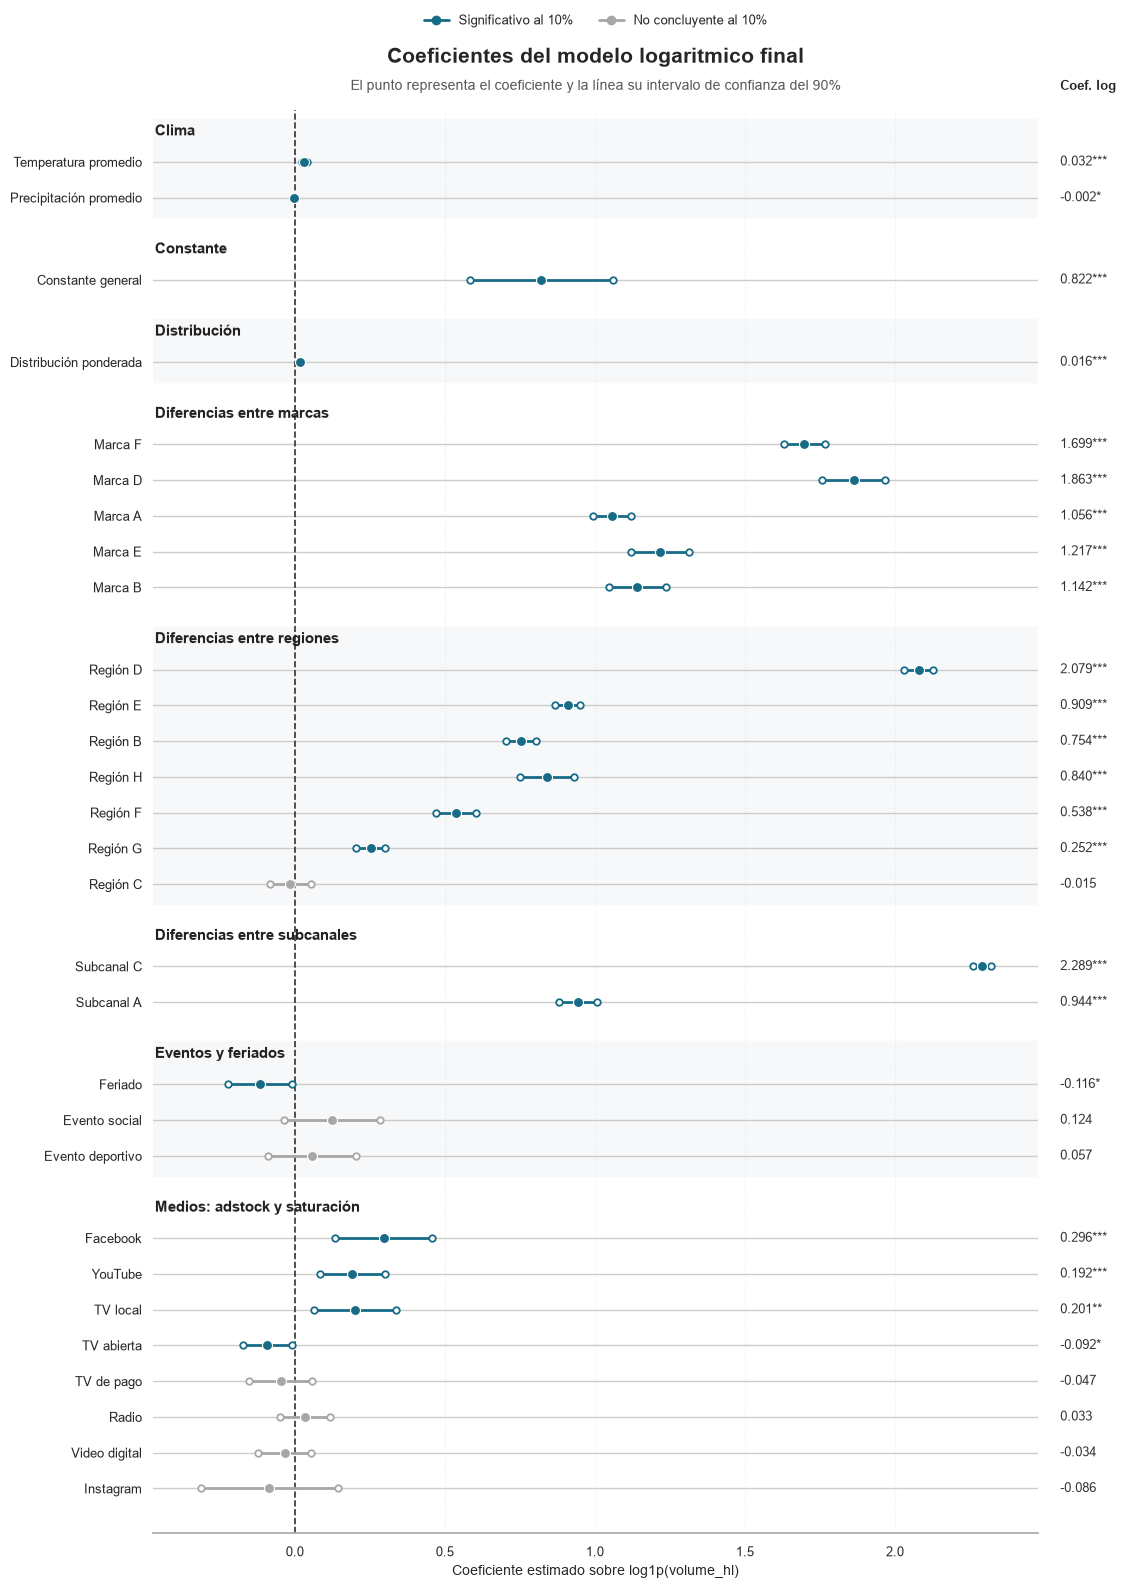

In [47]:
import matplotlib.pyplot as plt
from pathlib import Path

from matplotlib.lines import Line2D

nombres_medios = {
    'cinema': 'Cine',
    'digitaldisplayandsearch': 'Display y búsqueda digital',
    'digitalvideo': 'Video digital',
    'facebook': 'Facebook',
    'instagram': 'Instagram',
    'localtv': 'TV local',
    'ooh': 'Publicidad exterior',
    'opentv': 'TV abierta',
    'paytv': 'TV de pago',
    'print': 'Medios impresos',
    'radio': 'Radio',
    'tiktok': 'TikTok',
    'twitter': 'Twitter',
    'youtube': 'YouTube'
}

nombres_bloques = {
    'Constante': 'Constante',
    'Clima': 'Clima',
    'Distribucion': 'Distribución',
    'Efecto fijo: marca': 'Diferencias entre marcas',
    'Efecto fijo: region': 'Diferencias entre regiones',
    'Efecto fijo: subcanal': 'Diferencias entre subcanales',
    'Eventos y feriados': 'Eventos y feriados',
    'Medios: adstock y saturacion': 'Medios: adstock y saturación'
}

def etiqueta_grafica(variable):
    if variable == 'alpha_constante':
        return 'Constante general'

    if variable.startswith('alpha_brand['):
        categoria = variable.split('[', 1)[1].rstrip(']')
        return categoria.replace('Brand', 'Marca')

    if variable.startswith('alpha_region['):
        categoria = variable.split('[', 1)[1].rstrip(']')
        return categoria.replace('Region', 'Región')

    if variable.startswith('alpha_subchannel['):
        categoria = variable.split('[', 1)[1].rstrip(']')
        return categoria.replace('Subchannel', 'Subcanal')

    if variable == 'D_distribucion':
        return (
            'Distribución ponderada'
            if variable_distribucion_modelo == 'weighted_distribution'
            else 'Distribución total'
        )

    if variable == 'C_clima[avg_temp]':
        return 'Temperatura promedio'

    if variable == 'C_clima[avg_prcp]':
        return 'Precipitación promedio'

    if variable == 'E_evento[feriado]':
        return 'Feriado'

    if variable == 'E_evento[evento_social]':
        return 'Evento social'

    if variable == 'E_evento[evento_deportivo]':
        return 'Evento deportivo'

    if variable.startswith('eta_media['):
        canal = variable.split('[', 1)[1].rstrip(']')
        return nombres_medios.get(canal, canal)

    if variable.startswith('Q_quiebre['):
        return 'Cambio estructural en video digital'

    return variable

intervalos = modelo_ols.conf_int(alpha=0.10).copy()

intervalos.columns = [
    'ic_inferior',
    'ic_superior'
]

intervalos['variable'] = [
    renombrar_coeficiente(nombre)
    for nombre in intervalos.index
]

tabla_grafica = (
    tabla_coeficientes
    .merge(
        intervalos[
            ['variable', 'ic_inferior', 'ic_superior']
        ],
        on='variable',
        how='left'
    )
    .copy()
)

tabla_grafica['etiqueta'] = (
    tabla_grafica['variable']
    .apply(etiqueta_grafica)
)

tabla_grafica['significativo'] = (
    tabla_grafica['p_value'] < 0.10
)

tabla_grafica['significancia'] = (
    tabla_grafica['p_value']
    .apply(estrellas_significancia)
)

posiciones = []
encabezados = []
bandas = []

posicion_actual = 0

for numero_bloque, (bloque, datos_bloque) in enumerate(
    tabla_grafica.groupby(
        'bloque_modelo',
        sort=False
    )
):
    encabezado = posicion_actual
    encabezados.append({
        'bloque': nombres_bloques.get(bloque, bloque),
        'posicion': encabezado
    })

    posicion_actual += 0.85
    inicio_banda = encabezado - 0.35

    for indice in datos_bloque.index:
        posiciones.append({
            'indice': indice,
            'posicion': posicion_actual
        })
        posicion_actual += 1

    fin_banda = posicion_actual - 0.45

    bandas.append({
        'inicio': inicio_banda,
        'fin': fin_banda,
        'color': (
            '#F7F8FA'
            if numero_bloque % 2 == 0
            else '#FFFFFF'
        )
    })

    posicion_actual += 0.45

posiciones = pd.DataFrame(posiciones)

tabla_grafica = (
    tabla_grafica
    .merge(
        posiciones,
        left_index=True,
        right_on='indice',
        how='left'
    )
    .sort_values('posicion')
    .reset_index(drop=True)
)

alto_figura = max(
    15,
    posicion_actual * 0.42
)

fig, ax = plt.subplots(
    figsize=(15, alto_figura)
)

for banda in bandas:
    ax.axhspan(
        banda['inicio'],
        banda['fin'],
        color=banda['color'],
        zorder=0
    )

for _, fila in tabla_grafica.iterrows():
    color = (
        '#176B87'
        if fila['significativo']
        else '#A7A7A7'
    )

    ax.hlines(
        y=fila['posicion'],
        xmin=fila['ic_inferior'],
        xmax=fila['ic_superior'],
        color=color,
        linewidth=2,
        zorder=2
    )

    ax.scatter(
        [fila['ic_inferior'], fila['ic_superior']],
        [fila['posicion'], fila['posicion']],
        s=22,
        facecolor='white',
        edgecolor=color,
        linewidth=1.3,
        zorder=3
    )

    ax.scatter(
        fila['estimado'],
        fila['posicion'],
        s=52,
        color=color,
        edgecolor='white',
        linewidth=0.8,
        zorder=4
    )

    valor = (
        f"{fila['estimado']:.3f}"
        f"{fila['significancia']}"
    )

    ax.text(
        1.025,
        fila['posicion'],
        valor,
        transform=ax.get_yaxis_transform(),
        ha='left',
        va='center',
        fontsize=9,
        color='#333333'
    )

for encabezado in encabezados:
    ax.text(
        0.002,
        encabezado['posicion'],
        encabezado['bloque'],
        transform=ax.get_yaxis_transform(),
        ha='left',
        va='center',
        fontsize=10.5,
        fontweight='bold',
        color='#222222'
    )

ax.axvline(
    0,
    color='#333333',
    linestyle='--',
    linewidth=1.2,
    zorder=1
)

limite_inferior = min(
    tabla_grafica['ic_inferior'].min(),
    0
)

limite_superior = max(
    tabla_grafica['ic_superior'].max(),
    0
)

amplitud = limite_superior - limite_inferior

ax.set_xlim(
    limite_inferior - amplitud * 0.06,
    limite_superior + amplitud * 0.06
)

ax.set_ylim(
    posicion_actual - 0.2,
    -0.6
)

ax.set_yticks(
    tabla_grafica['posicion']
)

ax.set_yticklabels(
    tabla_grafica['etiqueta'],
    fontsize=9
)

ax.tick_params(
    axis='y',
    length=0,
    pad=8
)

ax.tick_params(
    axis='x',
    labelsize=9
)

ax.grid(
    axis='x',
    linestyle=':',
    linewidth=0.8,
    alpha=0.35
)

ax.set_xlabel(
    'Coeficiente estimado sobre log1p(volume_hl)',
    fontsize=10
)

ax.set_ylabel('')

ax.set_title(
    'Coeficientes del modelo logaritmico final',
    fontsize=15,
    fontweight='bold',
    pad=34
)

ax.text(
    0.5,
    1.012,
    'El punto representa el coeficiente y la línea su intervalo de confianza del 90%',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=10,
    color='#555555'
)

ax.text(
    1.025,
    1.012,
    'Coef. log',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=9,
    fontweight='bold'
)

leyenda = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='#176B87',
        label='Significativo al 10%',
        markersize=6,
        linewidth=2
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        color='#A7A7A7',
        label='No concluyente al 10%',
        markersize=6,
        linewidth=2
    )
]

ax.legend(
    handles=leyenda,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.075),
    ncol=2,
    frameon=False,
    fontsize=9
)

for lado in [
    'top',
    'right',
    'left'
]:
    ax.spines[lado].set_visible(False)

ax.spines['bottom'].set_color('#AAAAAA')

plt.subplots_adjust(
    left=0.25,
    right=0.84,
    top=0.92,
    bottom=0.06
)

ruta_grafico_coeficientes = (
    Path('tmp') / 'mlflow_artifacts' / 'coeficientes_modelo_final.png'
)
ruta_grafico_coeficientes.parent.mkdir(
    parents=True,
    exist_ok=True
)
fig.savefig(
    ruta_grafico_coeficientes,
    dpi=180,
    bbox_inches='tight'
)
grafico_coeficientes_path = str(ruta_grafico_coeficientes)

plt.show()

### Lectura de los coeficientes

La distribución ponderada mantiene una asociación positiva y estadísticamente significativa. Cada punto adicional de distribución se relaciona con aproximadamente **1.6% más volumen**, manteniendo constantes los demás factores. Esto refuerza la importancia de asegurar disponibilidad antes de ampliar la presión publicitaria.

Las comparaciones estructurales utilizan como referencias la **Marca C**, la **Región A** y el **Subcanal B**. La Región D presenta la mayor diferencia positiva frente a la Región A. Las demás regiones, salvo la Región C, también muestran niveles superiores. Los subcanales A y C presentan mayor volumen base que el Subcanal B, y todas las marcas muestran niveles superiores a la Marca C. Estas diferencias reflejan tamaño, cobertura, portafolio y condiciones comerciales; no demuestran una mayor respuesta a la publicidad.

### Resultados de medios

**Facebook, YouTube y TV local** presentan asociaciones positivas y significativas al 10%. Son candidatos razonables para pruebas incrementales, no una instrucción automática de aumentar presupuesto. TV abierta muestra una asociación negativa débil al 10%; este signo puede responder a campañas activadas en semanas o mercados débiles, solapamiento entre medios o variables no observadas. Para los demás canales no se encuentra evidencia suficientemente precisa en esta especificación.

### Otros factores

La temperatura presenta una asociación positiva y significativa con el volumen. La precipitación muestra una relación negativa pequeña y débil al 10%. Los eventos deportivos y sociales no son significativos, mientras que los feriados presentan una asociación negativa débil.

### Implicación para mercadeo

La prioridad comercial sigue siendo proteger distribución y disponibilidad. En medios, conviene concentrar las pruebas incrementales en Facebook, YouTube y TV local, y revisar la ejecución de TV abierta antes de modificar su presupuesto. Los resultados son asociaciones estimadas con un nivel de significancia del 10%; deben orientar pruebas y diagnósticos, no interpretarse como causalidad definitiva.

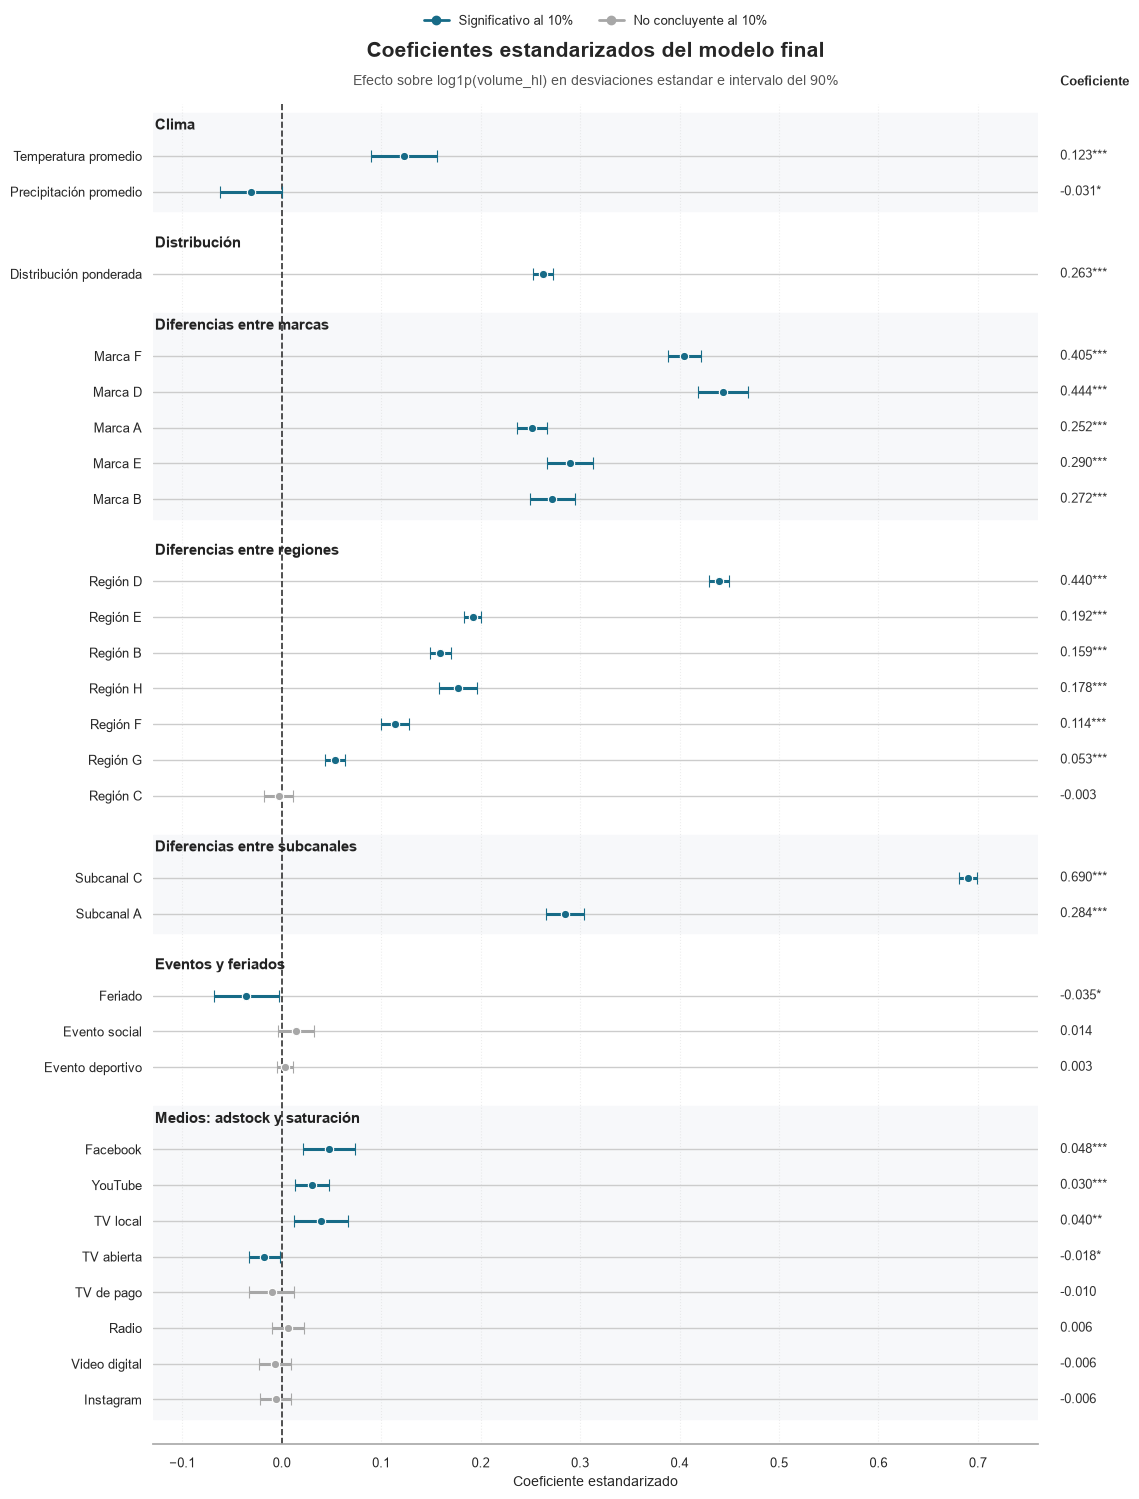

In [48]:
from matplotlib.lines import Line2D

nombres_medios = {
    'cinema': 'Cine',
    'digitaldisplayandsearch': 'Display y búsqueda digital',
    'digitalvideo': 'Video digital',
    'facebook': 'Facebook',
    'instagram': 'Instagram',
    'localtv': 'TV local',
    'ooh': 'Publicidad exterior',
    'opentv': 'TV abierta',
    'paytv': 'TV de pago',
    'print': 'Medios impresos',
    'radio': 'Radio',
    'tiktok': 'TikTok',
    'twitter': 'Twitter',
    'youtube': 'YouTube'
}

nombres_bloques = {
    'Constante': 'Constante',
    'Clima': 'Clima',
    'Distribucion': 'Distribución',
    'Efecto fijo: marca': 'Diferencias entre marcas',
    'Efecto fijo: region': 'Diferencias entre regiones',
    'Efecto fijo: subcanal': 'Diferencias entre subcanales',
    'Eventos y feriados': 'Eventos y feriados',
    'Medios: adstock y saturacion': 'Medios: adstock y saturación'
}

def etiqueta_estandarizada(variable):
    if variable.startswith('alpha_brand['):
        categoria = variable.split('[', 1)[1].rstrip(']')
        return categoria.replace('Brand', 'Marca')

    if variable.startswith('alpha_region['):
        categoria = variable.split('[', 1)[1].rstrip(']')
        return categoria.replace('Region', 'Región')

    if variable.startswith('alpha_subchannel['):
        categoria = variable.split('[', 1)[1].rstrip(']')
        return categoria.replace('Subchannel', 'Subcanal')

    if variable == 'D_distribucion':
        return (
            'Distribución ponderada'
            if variable_distribucion_modelo == 'weighted_distribution'
            else 'Distribución total'
        )

    if variable == 'C_clima[avg_temp]':
        return 'Temperatura promedio'

    if variable == 'C_clima[avg_prcp]':
        return 'Precipitación promedio'

    if variable == 'E_evento[feriado]':
        return 'Feriado'

    if variable == 'E_evento[evento_social]':
        return 'Evento social'

    if variable == 'E_evento[evento_deportivo]':
        return 'Evento deportivo'

    if variable.startswith('eta_media['):
        canal = variable.split('[', 1)[1].rstrip(']')
        return nombres_medios.get(canal, canal)

    if variable.startswith('Q_quiebre['):
        return 'Cambio estructural en video digital'

    return variable

desviacion_y = y_train_log.std(ddof=0)

intervalos_originales = modelo_ols.conf_int(
    alpha=0.10
)

desviaciones_x = (
    X_train_ols
    .std(ddof=0)
    .reindex(modelo_ols.params.index)
)

coeficientes_estandarizados = pd.DataFrame({
    'variable_original': modelo_ols.params.index.to_numpy(),
    'estimado_original': modelo_ols.params.to_numpy(),
    'ic_inferior_original': intervalos_originales.iloc[:, 0].to_numpy(),
    'ic_superior_original': intervalos_originales.iloc[:, 1].to_numpy(),
    'p_value': modelo_ols.pvalues.to_numpy(),
    'desviacion_x': desviaciones_x.to_numpy()
})

coeficientes_estandarizados = (
    coeficientes_estandarizados[
        coeficientes_estandarizados['variable_original'] != 'const'
    ]
    .copy()
)

coeficientes_estandarizados = (
    coeficientes_estandarizados[
        coeficientes_estandarizados['desviacion_x'].notna()
        & (coeficientes_estandarizados['desviacion_x'] > 0)
    ]
    .copy()
)

coeficientes_estandarizados['factor_estandarizacion'] = (
    coeficientes_estandarizados['desviacion_x']
    / desviacion_y
)

coeficientes_estandarizados['estimado'] = (
    coeficientes_estandarizados['estimado_original']
    * coeficientes_estandarizados['factor_estandarizacion']
)

coeficientes_estandarizados['ic_inferior'] = (
    coeficientes_estandarizados['ic_inferior_original']
    * coeficientes_estandarizados['factor_estandarizacion']
)

coeficientes_estandarizados['ic_superior'] = (
    coeficientes_estandarizados['ic_superior_original']
    * coeficientes_estandarizados['factor_estandarizacion']
)

coeficientes_estandarizados['variable'] = (
    coeficientes_estandarizados['variable_original']
    .apply(renombrar_coeficiente)
)

if coeficientes_estandarizados[
    ['ic_inferior', 'ic_superior']
].isna().any().any():
    raise ValueError(
        'No fue posible calcular los intervalos estandarizados.'
    )

orden_tabla = (
    tabla_coeficientes[
        ['bloque_modelo', 'variable']
    ]
    .copy()
)

tabla_estandarizada = (
    orden_tabla
    .merge(
        coeficientes_estandarizados[
            [
                'variable',
                'estimado',
                'ic_inferior',
                'ic_superior',
                'p_value'
            ]
        ],
        on='variable',
        how='inner'
    )
)

tabla_estandarizada['etiqueta'] = (
    tabla_estandarizada['variable']
    .apply(etiqueta_estandarizada)
)

tabla_estandarizada['significativo'] = (
    tabla_estandarizada['p_value'] < 0.10
)

tabla_estandarizada['significancia'] = (
    tabla_estandarizada['p_value']
    .apply(estrellas_significancia)
)

tabla_estandarizada['posicion'] = np.nan

encabezados = []
bandas = []

posicion_actual = 0

for numero_bloque, bloque in enumerate(
    tabla_estandarizada['bloque_modelo'].drop_duplicates()
):
    indices_bloque = tabla_estandarizada.index[
        tabla_estandarizada['bloque_modelo'] == bloque
    ]

    encabezado = posicion_actual

    encabezados.append({
        'bloque': nombres_bloques.get(bloque, bloque),
        'posicion': encabezado
    })

    posicion_actual += 0.85
    inicio_banda = encabezado - 0.35

    for indice in indices_bloque:
        tabla_estandarizada.loc[
            indice,
            'posicion'
        ] = posicion_actual

        posicion_actual += 1

    bandas.append({
        'inicio': inicio_banda,
        'fin': posicion_actual - 0.45,
        'color': (
            '#F7F8FA'
            if numero_bloque % 2 == 0
            else '#FFFFFF'
        )
    })

    posicion_actual += 0.45

alto_figura = max(
    14,
    posicion_actual * 0.42
)

fig, ax = plt.subplots(
    figsize=(15, alto_figura)
)

for banda in bandas:
    ax.axhspan(
        banda['inicio'],
        banda['fin'],
        color=banda['color'],
        zorder=0
    )

for _, fila in tabla_estandarizada.iterrows():
    color = (
        '#176B87'
        if fila['significativo']
        else '#A7A7A7'
    )

    error_inferior = (
        fila['estimado']
        - fila['ic_inferior']
    )

    error_superior = (
        fila['ic_superior']
        - fila['estimado']
    )

    ax.errorbar(
        x=fila['estimado'],
        y=fila['posicion'],
        xerr=np.array([
            [error_inferior],
            [error_superior]
        ]),
        fmt='o',
        markersize=6,
        markerfacecolor=color,
        markeredgecolor='white',
        markeredgewidth=0.8,
        color=color,
        ecolor=color,
        elinewidth=2.2,
        capsize=4,
        capthick=1.5,
        zorder=4
    )

    valor = (
        f"{fila['estimado']:.3f}"
        f"{fila['significancia']}"
    )

    ax.text(
        1.025,
        fila['posicion'],
        valor,
        transform=ax.get_yaxis_transform(),
        ha='left',
        va='center',
        fontsize=9,
        color='#333333'
    )

for encabezado in encabezados:
    ax.text(
        0.002,
        encabezado['posicion'],
        encabezado['bloque'],
        transform=ax.get_yaxis_transform(),
        ha='left',
        va='center',
        fontsize=10.5,
        fontweight='bold',
        color='#222222'
    )

ax.axvline(
    0,
    color='#333333',
    linestyle='--',
    linewidth=1.2,
    zorder=1
)

limite_inferior = min(
    tabla_estandarizada['ic_inferior'].min(),
    0
)

limite_superior = max(
    tabla_estandarizada['ic_superior'].max(),
    0
)

amplitud = limite_superior - limite_inferior

if amplitud == 0:
    amplitud = 1

ax.set_xlim(
    limite_inferior - amplitud * 0.08,
    limite_superior + amplitud * 0.08
)

ax.set_ylim(
    posicion_actual - 0.2,
    -0.6
)

ax.set_yticks(
    tabla_estandarizada['posicion']
)

ax.set_yticklabels(
    tabla_estandarizada['etiqueta'],
    fontsize=9
)

ax.tick_params(
    axis='y',
    length=0,
    pad=8
)

ax.tick_params(
    axis='x',
    labelsize=9
)

ax.grid(
    axis='x',
    linestyle=':',
    linewidth=0.8,
    alpha=0.35
)

ax.set_xlabel(
    'Coeficiente estandarizado',
    fontsize=10
)

ax.set_ylabel('')

ax.set_title(
    'Coeficientes estandarizados del modelo final',
    fontsize=15,
    fontweight='bold',
    pad=34
)

ax.text(
    0.5,
    1.012,
    'Efecto sobre log1p(volume_hl) en desviaciones estandar e intervalo del 90%',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=10,
    color='#555555'
)

ax.text(
    1.025,
    1.012,
    'Coeficiente',
    transform=ax.transAxes,
    ha='left',
    va='bottom',
    fontsize=9,
    fontweight='bold'
)

leyenda = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='#176B87',
        label='Significativo al 10%',
        markersize=6,
        linewidth=2
    ),
    Line2D(
        [0],
        [0],
        marker='o',
        color='#A7A7A7',
        label='No concluyente al 10%',
        markersize=6,
        linewidth=2
    )
]

ax.legend(
    handles=leyenda,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.075),
    ncol=2,
    frameon=False,
    fontsize=9
)

for lado in ['top', 'right', 'left']:
    ax.spines[lado].set_visible(False)

ax.spines['bottom'].set_color('#AAAAAA')

plt.subplots_adjust(
    left=0.25,
    right=0.84,
    top=0.92,
    bottom=0.06
)

plt.show()

# Conclusiones generales

El modelo permite separar diferencias estructurales de marca, región y subcanal de las asociaciones observadas con distribución, clima, eventos y medios. Sus resultados sirven para formular hipótesis comerciales y diseñar pruebas, pero no identifican por sí solos efectos causales.

### Escala comercial de regiones y subcanales

La **Región D** y el **Subcanal C** presentan un volumen base esperado mayor que sus categorías de referencia, una vez controladas las demás variables. Esto indica diferencias de escala, cobertura, portafolio, disponibilidad o condiciones comerciales. **No demuestra que estos segmentos respondan mejor a la publicidad ni justifica asignarles una mayor inversión de medios.**

Para recomendar presupuesto por territorio o subcanal se necesitarían interacciones entre medios y segmentos, elasticidades estimadas por grupo o experimentos incrementales con mercados de control. Hasta contar con esa evidencia, los efectos fijos deben interpretarse exclusivamente como diferencias en el nivel base de ventas.

### Distribución y ejecución comercial

La distribución ponderada presenta la asociación positiva más consistente con el volumen. La acción comercial mejor respaldada es proteger disponibilidad, cobertura e inventario. Región D y Subcanal C pueden estudiarse para entender qué condiciones explican su mayor escala y evaluar si alguna práctica es transferible, sin asumir que son automáticamente los mejores destinos publicitarios.

### Evidencia de medios

**Facebook, YouTube y TV local** muestran asociaciones positivas y significativas al 10% en la especificación estimada. Deben considerarse candidatos para pruebas incrementales, no canales a los que deba trasladarse presupuesto de forma automática. La asociación negativa débil de TV abierta tampoco demuestra que el canal reduzca ventas; puede reflejar asignación endógena del presupuesto, campañas simultáneas o variables omitidas.

Para los demás medios no existe evidencia suficientemente precisa en esta especificación. Esto no implica ausencia de efecto, sino que los datos disponibles no permiten distinguirlo con confianza.

### Marcas

La **Marca C** es la categoría de referencia. Los coeficientes positivos de las demás marcas indican que presentan un volumen base superior al de Marca C bajo condiciones comparables. Esta comparación no mide la calidad de su gestión ni su sensibilidad a la publicidad. Para Marca C conviene revisar distribución, precio, portafolio y posicionamiento antes de atribuir la diferencia a comunicación.

### Recomendación final

La recomendación defendible es **proteger la distribución y utilizar los resultados de medios para priorizar experimentos**, especialmente en Facebook, YouTube y TV local. La asignación por región o subcanal debe permanecer abierta hasta estimar respuestas segmentadas o ejecutar pruebas con grupos de control. Ninguna reasignación importante debería basarse exclusivamente en los efectos fijos o en la significancia de esta regresión.

In [ ]:
# Registro acumulativo de calibraciones y modelo final con MLflow
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import mlflow
from mlflow.tracking import MlflowClient

ruta_tracking = 'sqlite:///mlflow.db'
nombre_experimento = 'challenge_ab_invenv'
execution_id = (
    datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
    + '_'
    + uuid4().hex[:8]
)

mlflow.set_tracking_uri(ruta_tracking)
mlflow.set_experiment(nombre_experimento)
cliente_mlflow = MlflowClient()
corridas_ejecucion = []

for _, fila in grilla_resultados.iterrows():
    nombre_run = (
        f"{execution_id}_grilla_{fila['canal']}_"
        f"t{fila['theta']}_a{fila['alpha']}_g{fila['gamma']:.4f}"
    )

    with mlflow.start_run(run_name=nombre_run) as corrida:
        corridas_ejecucion.append(corrida.info.run_id)
        mlflow.set_tag('execution_id', execution_id)
        mlflow.set_tag('tipo_corrida', 'calibracion_canal')
        mlflow.set_tag(
            'seleccionada',
            str(bool(fila['seleccionada'])).lower()
        )
        mlflow.set_tag(
            'incluida_modelo',
            str(bool(fila['incluida_modelo'])).lower()
        )
        mlflow.log_param('canal', fila['canal'])
        mlflow.log_param('theta', float(fila['theta']))
        mlflow.log_param('gamma', float(fila['gamma']))
        mlflow.log_param('alpha', float(fila['alpha']))
        mlflow.log_param('transformacion_objetivo', 'log1p')
        mlflow.log_param(
            'variable_distribucion',
            variable_distribucion_modelo
        )
        mlflow.log_metric(
            'coeficiente_medio_log',
            float(fila['coeficiente_medio'])
        )
        mlflow.log_metric(
            'rmse_calibracion_hl',
            float(fila['RMSE_calibracion'])
        )
        mlflow.log_metric(
            'rmse_validacion_hl',
            float(fila['RMSE_validacion'])
        )
        mlflow.log_metric(
            'mae_validacion_hl',
            float(fila['MAE_validacion'])
        )
        mlflow.log_metric(
            'r2_validacion_hl',
            float(fila['R2_validacion'])
        )

ruta_artifacts = Path('tmp') / 'mlflow_artifacts'
ruta_artifacts.mkdir(parents=True, exist_ok=True)

ruta_tabla_coeficientes = (
    ruta_artifacts / 'tabla_coeficientes_modelo_log.csv'
)
ruta_resumen_calibracion = (
    ruta_artifacts / 'resumen_calibracion_log_canales.csv'
)
ruta_metricas_modelo = (
    ruta_artifacts / 'metricas_modelo_log_final.csv'
)
ruta_tabla_benchmarks = (
    ruta_artifacts / 'benchmarks_modelo.csv'
)
ruta_extensiones_estacionales = (
    ruta_artifacts / 'extensiones_estacionales.csv'
)
ruta_desempeno_segmentos = (
    ruta_artifacts / 'desempeno_segmentos.csv'
)
ruta_ljung_box = ruta_artifacts / 'diagnostico_ljung_box.csv'
ruta_diagnosticos_residuos = (
    ruta_artifacts / 'diagnosticos_residuos.csv'
)
ruta_comparacion_metricas = (
    ruta_artifacts / 'comparacion_especificaciones_metricas.csv'
)
ruta_comparacion_coeficientes = (
    ruta_artifacts / 'comparacion_especificaciones_coeficientes.csv'
)
ruta_tabla_paper_html = (
    ruta_artifacts / 'tabla_comparativa_modelos.html'
)
ruta_parametros_standard = (
    ruta_artifacts / 'parametros_mmm_standard.csv'
)
ruta_comparacion_standard = (
    ruta_artifacts / 'comparacion_standard_calibrado.csv'
)
ruta_backtesting_folds = (
    ruta_artifacts / 'backtesting_folds.csv'
)
ruta_backtesting_global = (
    ruta_artifacts / 'backtesting_resumen_global.csv'
)

tabla_coeficientes.to_csv(ruta_tabla_coeficientes, index=False)
resumen_calibracion.to_csv(ruta_resumen_calibracion, index=False)
tabla_metricas_modelo.to_csv(ruta_metricas_modelo, index=False)
tabla_benchmarks.to_csv(ruta_tabla_benchmarks, index=False)
tabla_extensiones_estacionales.to_csv(
    ruta_extensiones_estacionales, index=False
)
tabla_desempeno_segmentos.to_csv(
    ruta_desempeno_segmentos, index=False
)
tabla_ljung_box.to_csv(ruta_ljung_box, index=False)
tabla_diagnosticos_residuos.to_csv(
    ruta_diagnosticos_residuos, index=False
)
tabla_comparativa_metricas.to_csv(
    ruta_comparacion_metricas, index=False
)
tabla_comparativa_coeficientes.to_csv(
    ruta_comparacion_coeficientes, index=False
)
ruta_tabla_paper_html.write_text(
    html_tabla_comparativa, encoding='utf-8'
)
tabla_parametros_mmm_standard.to_csv(
    ruta_parametros_standard, index=False
)
comparacion_standard_calibrado.to_csv(
    ruta_comparacion_standard, index=False
)
tabla_backtesting_folds.to_csv(
    ruta_backtesting_folds, index=False
)
tabla_backtesting_global.to_csv(
    ruta_backtesting_global, index=False
)

nombre_modelo_final = (
    f'{execution_id}_modelo_final_log1p_volume_hl'
)

with mlflow.start_run(
    run_name=nombre_modelo_final
) as corrida_final:
    corridas_ejecucion.append(corrida_final.info.run_id)
    mlflow.set_tag('execution_id', execution_id)
    mlflow.set_tag('tipo_corrida', 'modelo_final')
    mlflow.set_tag('modelo_recomendado', modelo_recomendado)
    mlflow.set_tag(
        'variable_distribucion',
        variable_distribucion_modelo
    )
    mlflow.set_tag('transformacion_objetivo', 'log1p')
    mlflow.log_param(
        'variable_distribucion',
        variable_distribucion_modelo
    )
    mlflow.log_param('transformacion_objetivo', 'log1p')
    mlflow.log_param(
        'retransformacion',
        'duan_smearing'
    )
    mlflow.log_param(
        'criterio_calibracion',
        'menor_rmse_validacion_hl'
    )
    mlflow.log_param(
        'canales_incluidos',
        int(len(mejores_parametros))
    )
    mlflow.log_param('nivel_significancia', 0.10)
    mlflow.log_param('nivel_confianza', 0.90)
    mlflow.log_param('standard_theta', STANDARD_THETA)
    mlflow.log_param('standard_alpha', STANDARD_ALPHA)
    mlflow.log_param('standard_gamma_rule', STANDARD_GAMMA_RULE)
    mlflow.log_param(
        'tolerancia_rmse_validacion_standard_pct',
        TOLERANCIA_RMSE_VALIDACION_PCT
    )
    mlflow.log_metric(
        'standard_perdida_rmse_validacion_pct',
        float(perdida_rmse_standard_pct)
    )
    mlflow.log_metric(
        'factor_smearing',
        factor_smearing
    )

    for _, parametros in mejores_parametros.iterrows():
        canal = parametros['canal']
        mlflow.log_param(
            f'theta_{canal}',
            float(parametros['theta'])
        )
        mlflow.log_param(
            f'gamma_{canal}',
            float(parametros['gamma'])
        )
        mlflow.log_param(
            f'alpha_{canal}',
            float(parametros['alpha'])
        )

    mlflow.log_metrics({
        f'{nombre}_hl': valor
        for nombre, valor in resultado_modelo['metricas'].items()
    })
    mlflow.log_artifact(str(ruta_resumen_calibracion))
    mlflow.log_artifact(str(ruta_metricas_modelo))
    mlflow.log_artifact(str(ruta_tabla_coeficientes))
    mlflow.log_artifact(str(ruta_tabla_benchmarks))
    mlflow.log_artifact(str(ruta_extensiones_estacionales))
    mlflow.log_artifact(str(ruta_desempeno_segmentos))
    mlflow.log_artifact(str(ruta_ljung_box))
    mlflow.log_artifact(str(ruta_diagnosticos_residuos))
    mlflow.log_artifact(str(ruta_comparacion_metricas))
    mlflow.log_artifact(str(ruta_comparacion_coeficientes))
    mlflow.log_artifact(str(ruta_tabla_paper_html))
    mlflow.log_artifact(str(ruta_parametros_standard))
    mlflow.log_artifact(str(ruta_comparacion_standard))
    mlflow.log_artifact(str(ruta_backtesting_folds))
    mlflow.log_artifact(str(ruta_backtesting_global))

    nombres_benchmark_mlflow = {
        'Estacional ingenuo (t-52)': 'estacional_t52',
        'Venta base sin medios': 'base_sin_medios',
        'MMM estandar preespecificado': 'mmm_standard',
        'Medios sin adstock ni saturacion': 'medios_sin_transformar',
        'MMM con adstock y saturacion': 'mmm'
    }
    for _, fila_benchmark in tabla_benchmarks.iterrows():
        clave_benchmark = nombres_benchmark_mlflow[fila_benchmark['modelo']]
        mlflow.log_metric(
            f'benchmark_{clave_benchmark}_r2',
            float(fila_benchmark['R2_prueba'])
        )
        mlflow.log_metric(
            f'benchmark_{clave_benchmark}_rmse_hl',
            float(fila_benchmark['RMSE_prueba_hl'])
        )
        mlflow.log_metric(
            f'benchmark_{clave_benchmark}_mae_hl',
            float(fila_benchmark['MAE_prueba_hl'])
        )

    if 'grafico_benchmarks_path' in globals():
        ruta_benchmark = Path(grafico_benchmarks_path)
        if ruta_benchmark.exists():
            mlflow.log_artifact(str(ruta_benchmark))

    if 'grafico_backtesting_path' in globals():
        ruta_backtesting = Path(grafico_backtesting_path)
        if ruta_backtesting.exists():
            mlflow.log_artifact(str(ruta_backtesting))

    if 'grafico_residuos_path' in globals():
        ruta_residuos = Path(grafico_residuos_path)
        if ruta_residuos.exists():
            mlflow.log_artifact(str(ruta_residuos))

    if 'grafico_coeficientes_path' in globals():
        ruta_grafico = Path(grafico_coeficientes_path)
        if ruta_grafico.exists():
            mlflow.log_artifact(str(ruta_grafico))

experimento_actual = mlflow.get_experiment_by_name(
    nombre_experimento
)
corridas_totales = cliente_mlflow.search_runs(
    experiment_ids=[experimento_actual.experiment_id],
    max_results=50000
)

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Experimento:', nombre_experimento)
print('ID de esta ejecucion:', execution_id)
print(
    'Corridas registradas en esta ejecucion:',
    len(corridas_ejecucion)
)
print(
    'Corridas activas acumuladas:',
    len(corridas_totales)
)
print('Modelo final:', nombre_modelo_final)

display(tabla_metricas_modelo.round(5))

Registro MLflow omitido en la reejecución de verificación; se conservan las corridas existentes.
